In [2]:
# pseudo-bound state (E > 0) solver for Yukawa potential
# central field potential - use radial schrodinger eqn
# **CHANGED V0 FROM 3.3 (20.0 -> 10.0)**

In [3]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt  # from hydrogen.py
import numpy as np  # from hydrogen.py
from jwanglibs import rootfinder as rtf  # from hydrogen.py
import matplotlib.cm as cm  # for colormap plots
from scipy.integrate import trapezoid  # wf normalization

In [4]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [5]:
# =================
# Define Functions
# =================
def V(r):  # Yukawa Potential
    '''
    Yukawa piecewise potential:
        Spherical well inside interaction range a (depth varied by V0)
        Exponential decay outside well (interaction strength varied by lamda)

    Another method:
        if r <=a:
            return -V0
        else:
            return np.exp(-lamda*r)/r
        Then -> V_vec = np.vectorize(V) to allow for vectorized plotting
    '''
    return np.where(r <= a, -V0, np.exp(-lamda*r)/r)

def centrifugal(r):  # Centrifugal Potential
    '''
    Centrifugal potential:
    L = orbital angular momentum quantum number
    Disappears for 1s states (L=0)
    '''
    return hbar**2*L*(L+1)/(2*m*r**2)

def V_eff(r):  # Effective Potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r  # centrifugal + coulomb
    '''
    return centrifugal(r) + V(r)  # centrifugal + yukawa

def f(r):  # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r))/hbar**2  # rearrange radial Sch eqn

def numerov(f, u, n, x, h):  # Numerov function
    '''
    Numerov integrator for $u''+f(x)u=0$
    '''
    nodes, c = 0, h**2/12.  # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = f(x), f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)  # Numerov method below
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))  # Numerov update
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes  # return u, nodes

def shoot(En):  # Shooting function
    global E  # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)  # outward integration from left
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)  # inward integration from right
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [6]:
# ==============================
# Initial Conditions/Parameters
# ==============================
xL, N = 10e-6, 3000  # limits, interval
xR, V0, a, lamda = 25.0, 10.0, 2.0, 0.2  # variables to test convergence (xR=right limit, V0=well depth, a=well width, lamda=screening strength)
hbar, m = 1.0, 1.0  # constants
h = (xR-xL)/N  # step size
Lmax, EL = 6, []  # define max L, blank L array
M = int(a*N/xR)  # M = matching point

In [7]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -V0-0.1, 0.001  # scan from well bottom -V0
list_psix = [[] for _ in range(Lmax)]  # store wfs for each L and n
#list_n = []

for L in range(Lmax):  # pure bound states (E < 0)
    n, E1, Ea = L+1, Estart, []
    while (E1 < np.exp(-lamda*a)/a + hbar**2*L*(L+1)/(2*m*a**2)):  # sweep E range for each L for pseudo-bound states (E > 0)
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)  # append E value to energy array Ea
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)  # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]  # match
        list_psix[L].append(psix)
        #list_n.append(n)
        
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 0, n = 1,l = 0, E = -8.99851057e+00
nodes = 1, n = 2,l = 0, E = -6.04269617e+00
nodes = 2, n = 3,l = 0, E = -1.41082144e+00
nodes = 3, n = 4,l = 0, E = 1.65023971e-02
nodes = 4, n = 5,l = 0, E = 5.27194449e-02
nodes = 5, n = 6,l = 0, E = 1.05311762e-01
nodes = 6, n = 7,l = 0, E = 1.74536057e-01
nodes = 7, n = 8,l = 0, E = 2.61045970e-01
nodes = 0, n = 2,l = 1, E = -7.95751921e+00
nodes = 1, n = 3,l = 1, E = -4.07673319e+00
nodes = 2, n = 4,l = 1, E = 2.14249972e-02
nodes = 3, n = 5,l = 1, E = 6.08300144e-02
nodes = 4, n = 6,l = 1, E = 1.16084465e-01
nodes = 5, n = 7,l = 1, E = 1.86668539e-01
nodes = 6, n = 8,l = 1, E = 2.72355192e-01
nodes = 7, n = 9,l = 1, E = 3.72735929e-01
nodes = 8, n = 10,l = 1, E = 4.86875309e-01
nodes = 0, n = 3,l = 2, E = -6.65193414e+00
nodes = 1, n = 4,l = 2, E = -1.90472981e+00
nodes = 2, n = 5,l = 2, E = 3.01486547e-02
nodes = 3, n = 6,l = 2, E = 7.51195456e-02
nodes = 4, n = 7,l = 2, E = 1.36114703e-01
nodes = 5, n = 8,l = 2, E = 2.12863903e-01
nod

<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_79648/2184603285.py:23: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


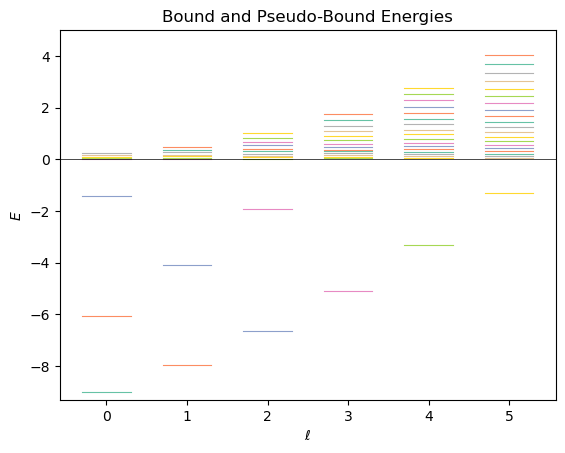

In [8]:
# =========
# Plotting
# =========
# Some code for plotting added with help of Claude
r = np.linspace(xL, xR, N)  # r range

# Create a colormap for different n-values
max_n = max(len(EL[L]) for L in range(Lmax))  # Find max number of n-values
num_colors = 8  # Number of colors to cycle through
colors = cm.Set2(np.linspace(0, 1, num_colors))  # Colors for cycling
legend = set()  # track which n values have been added to legend

plt.figure()  # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        list_n = L+i+1  # quantum number n
        label = f'$n$ = {list_n}' if list_n not in legend else None
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, color=colors[(list_n - 1) % num_colors], lw=0.8, label=label, alpha=1.0)
        legend.add(list_n)  # append n value to prevent duplicate legend entries

plt.title('Bound and Pseudo-Bound Energies')
plt.axhline(0, color='k', ls='-', lw=0.5, alpha=1.0)
plt.xlabel('$\ell$'), plt.ylabel('$E$')
plt.ylim(EL[0][0]-.3, 5), plt.xticks(range(Lmax))
#plt.ylim(EL[0][0]-.3, EL[-1][-1]+.3), plt.xticks(range(Lmax))
#plt.legend(title='$n$ values', loc='lower right')
#plt.savefig('pb_energy.pdf')  # Save the figure
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_79648/1461353464.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_79648/1461353464.py:42: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Energy and Potentials: $n={L+i+1}$, $\ell = {L}$')
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_79648/1461353464.py:56: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Probability Density: $n={L+i+1}$, $\ell = {L}$')
/var/folder

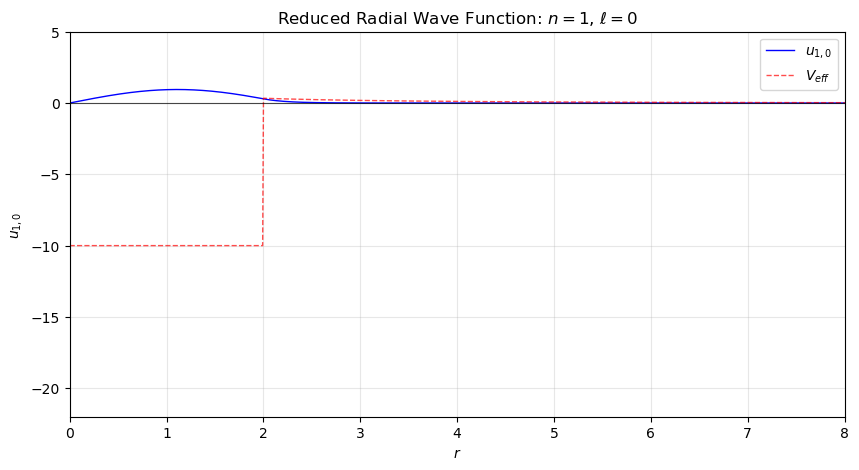

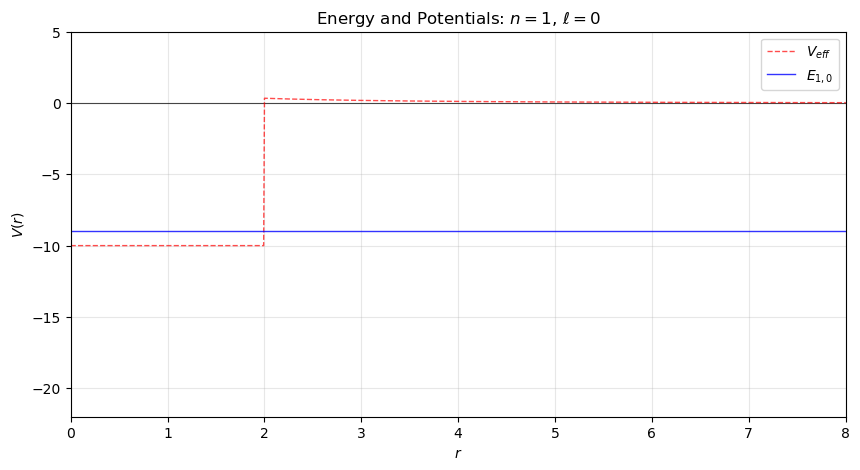

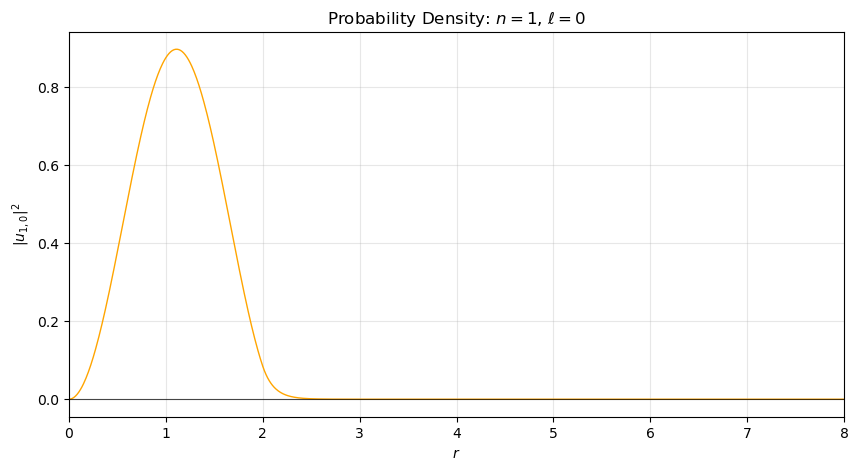

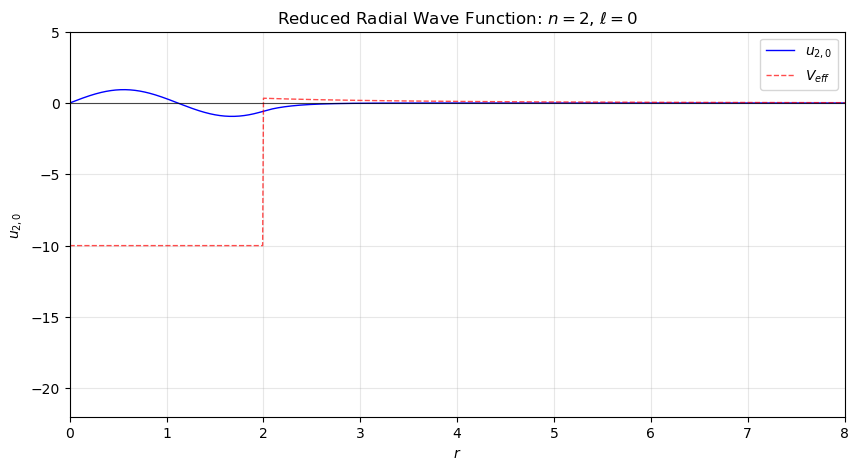

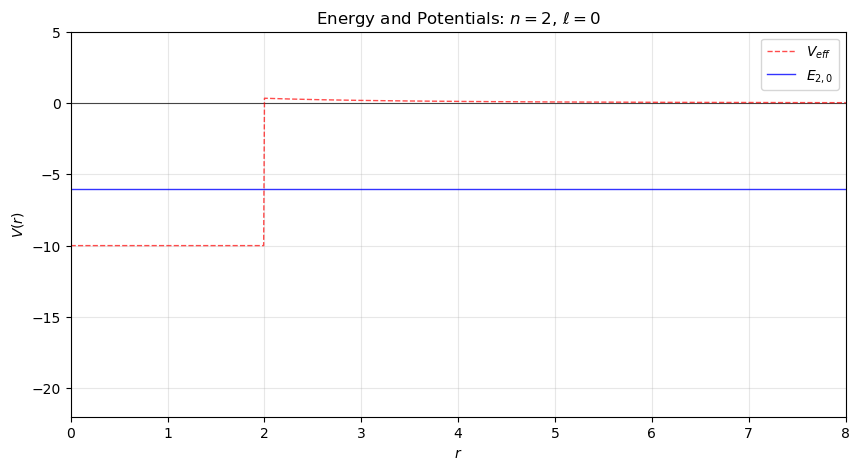

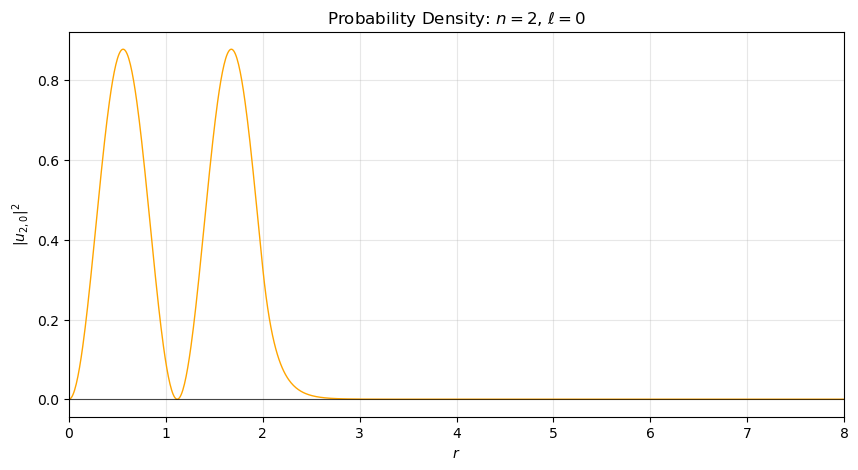

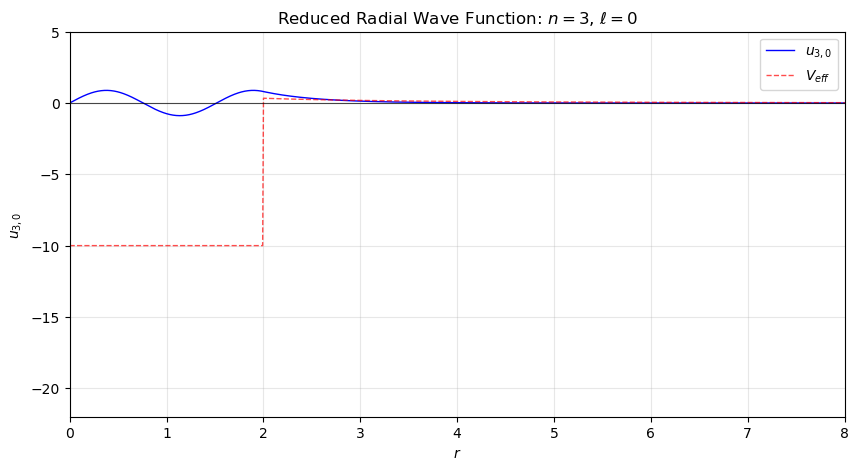

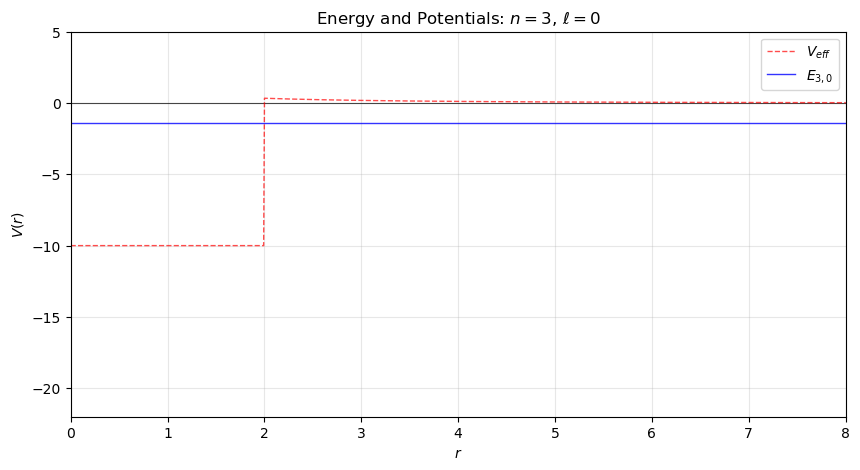

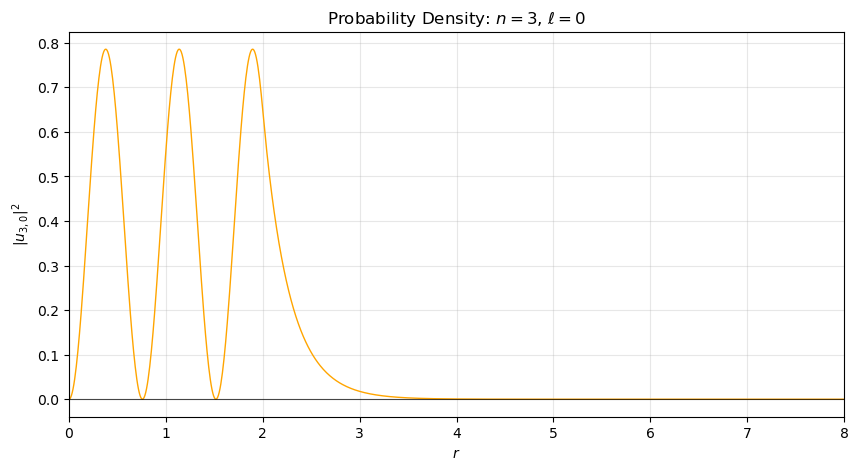

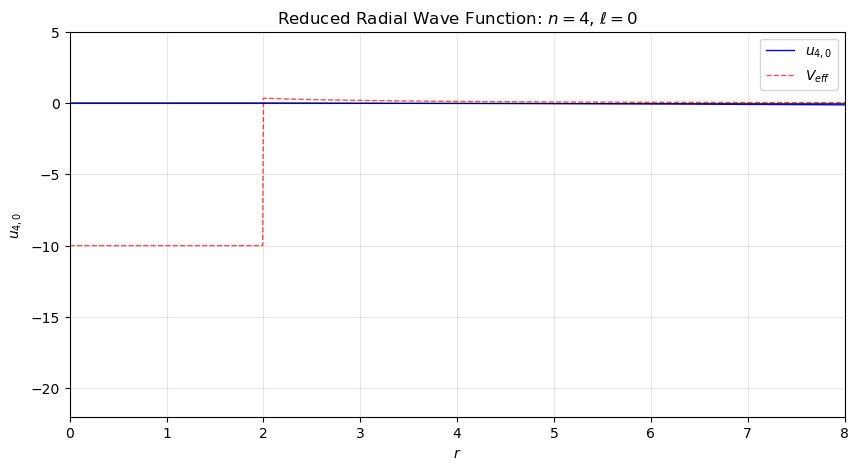

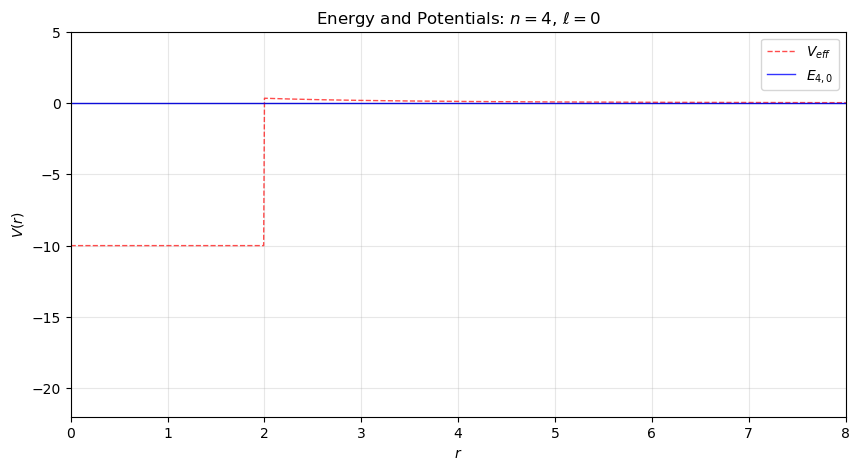

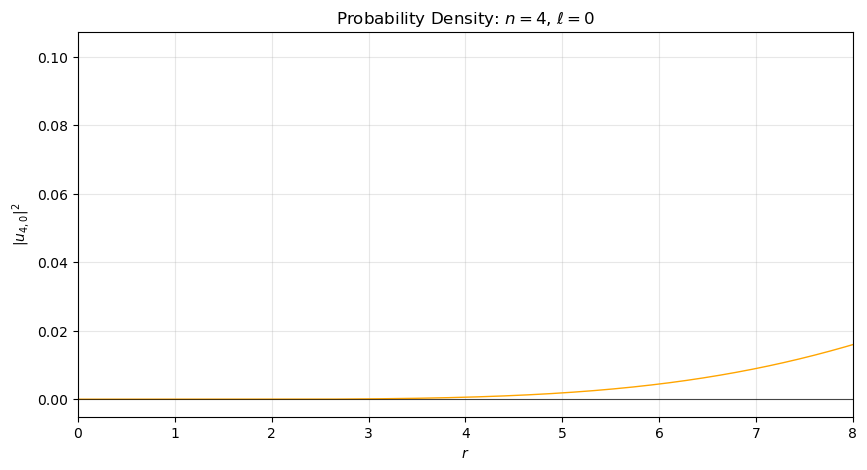

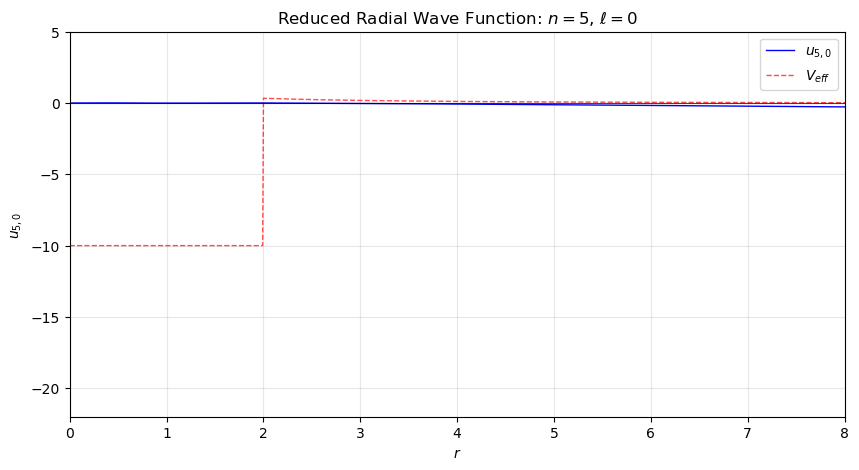

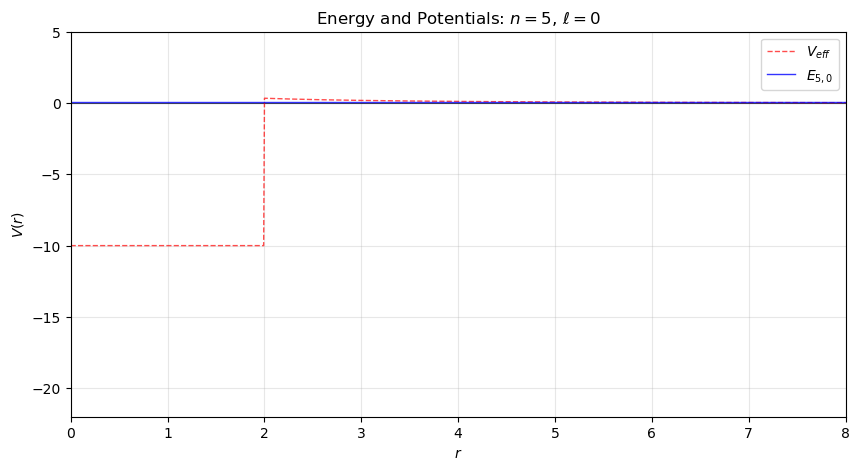

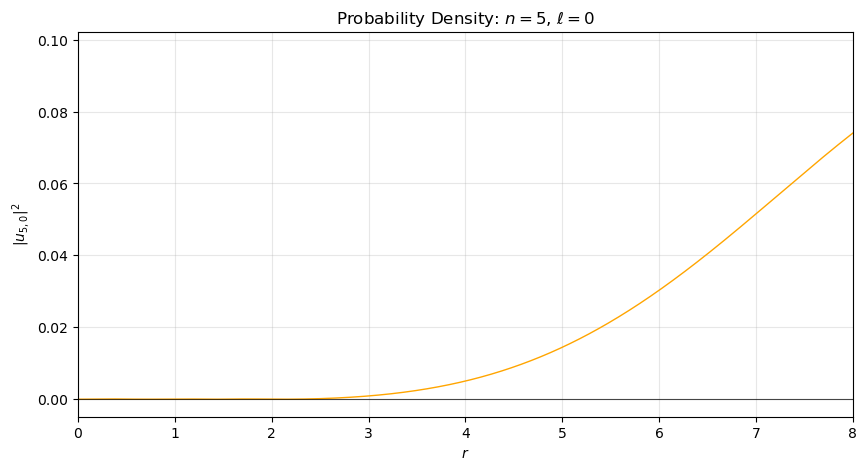

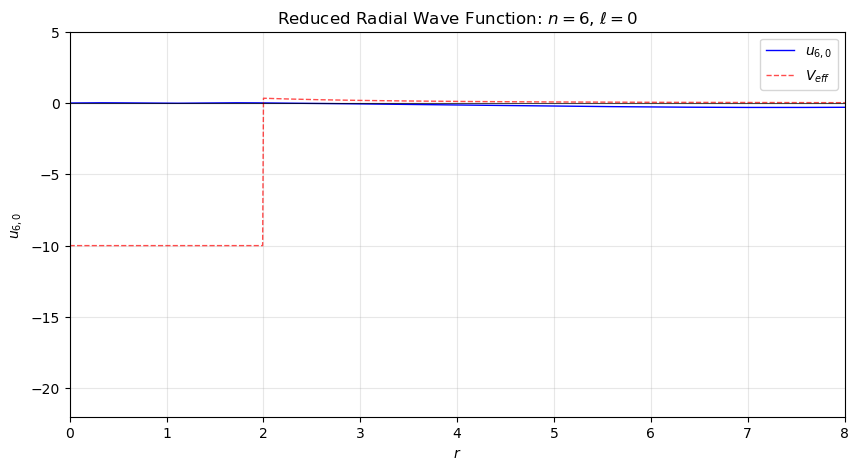

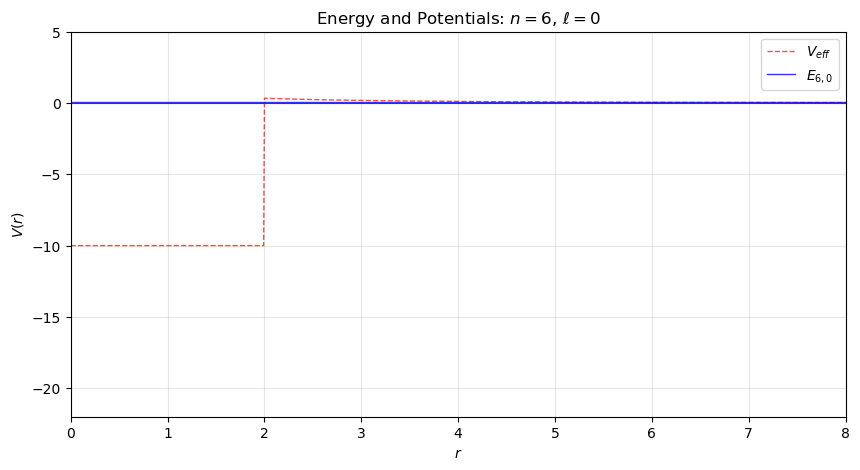

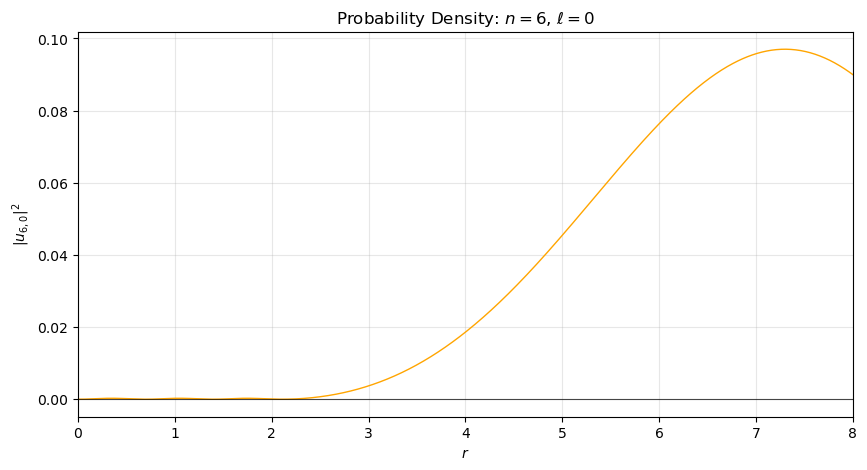

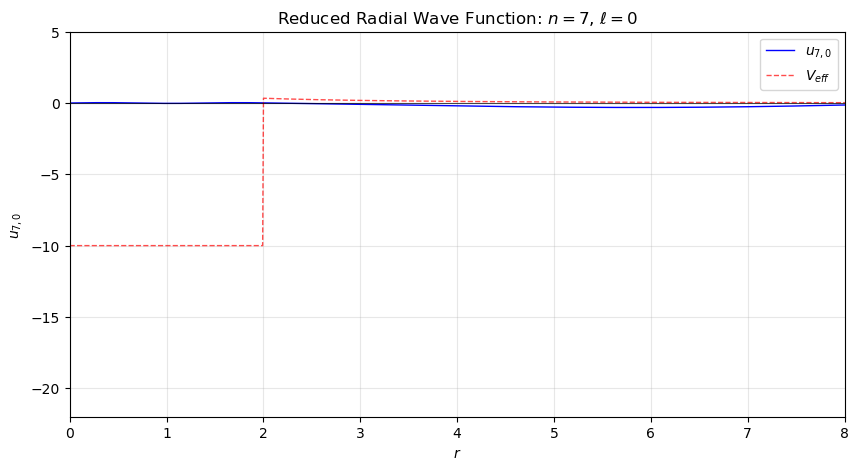

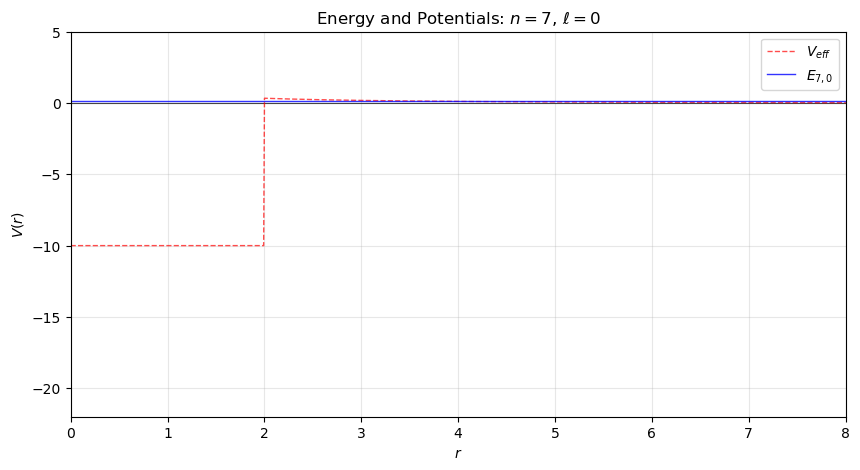

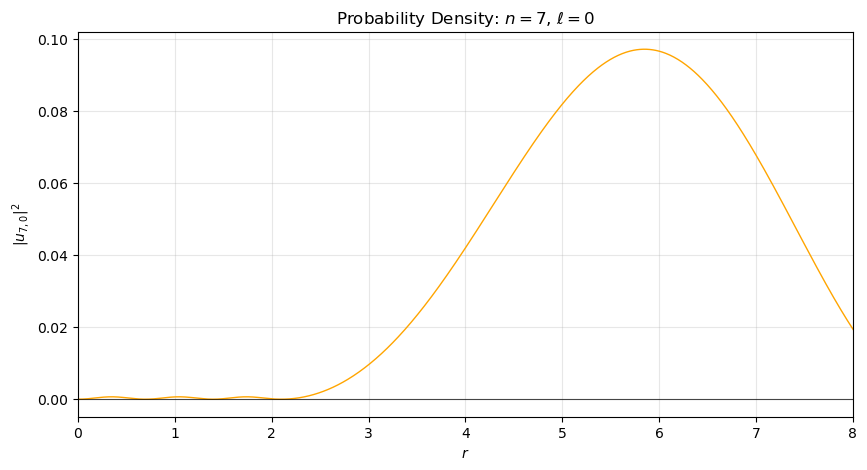

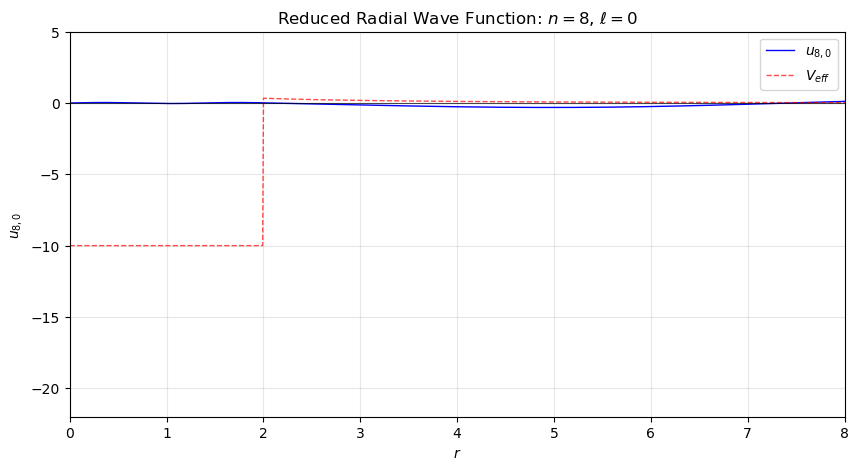

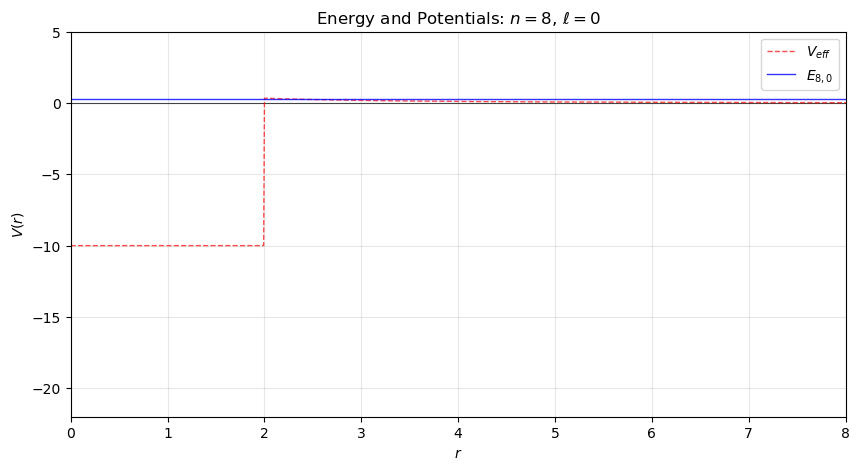

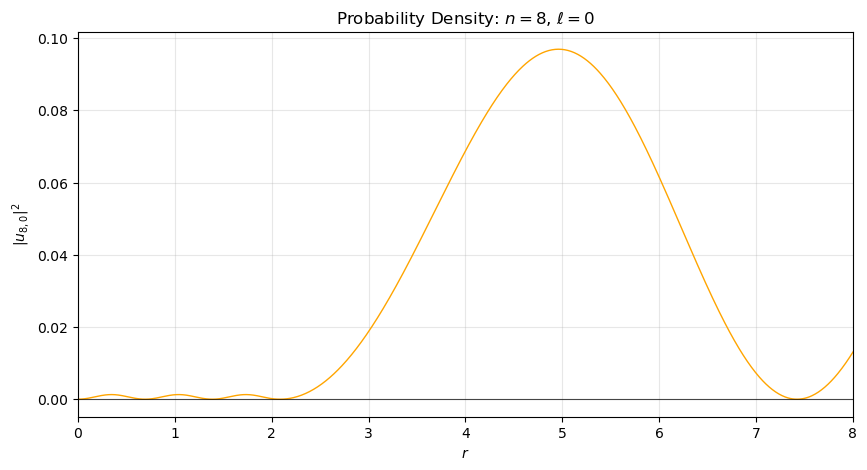

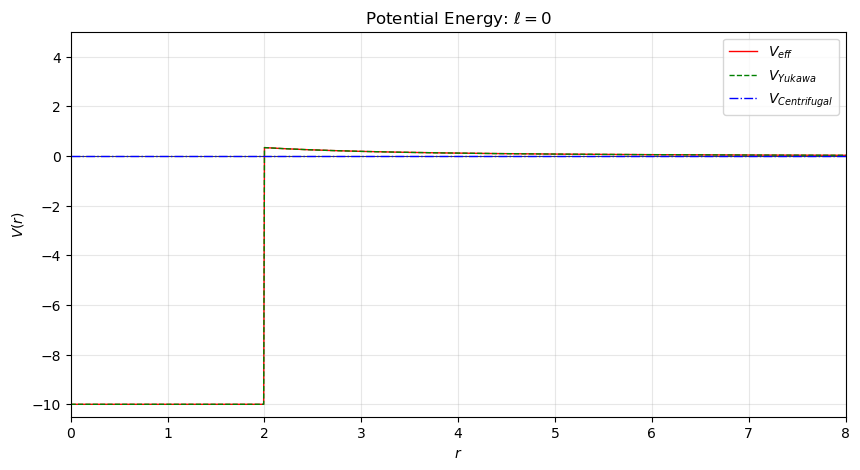

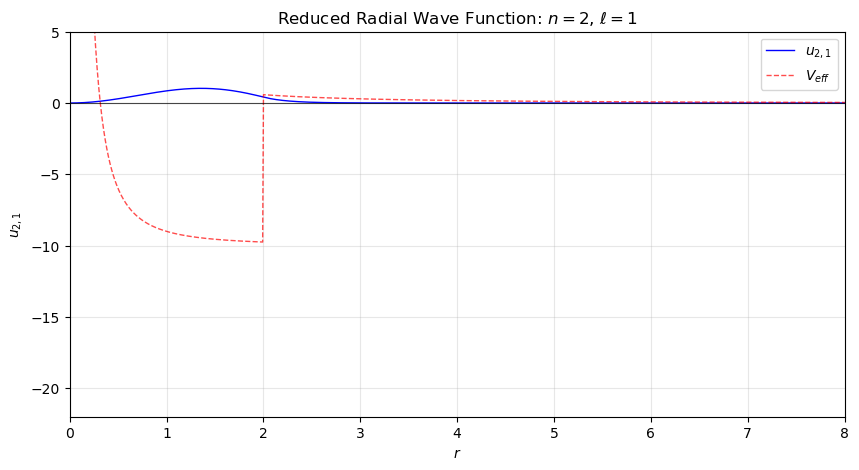

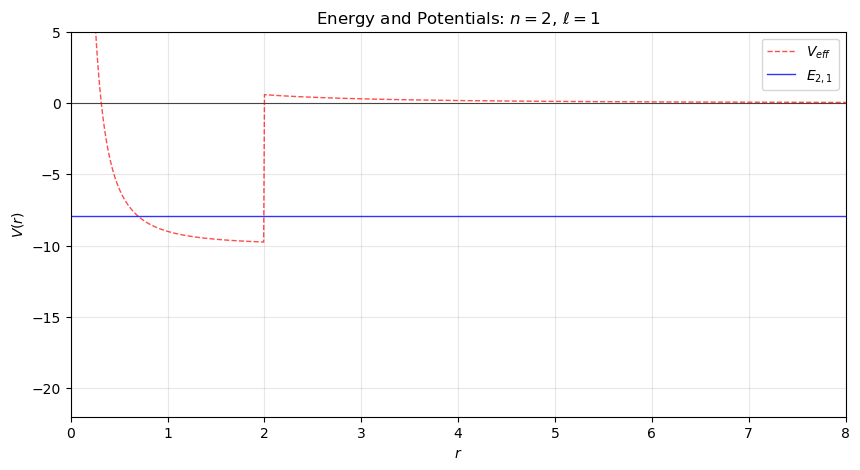

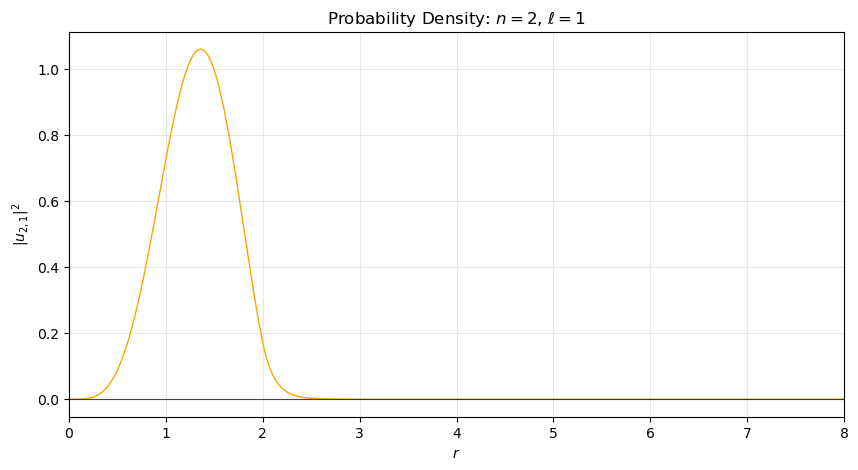

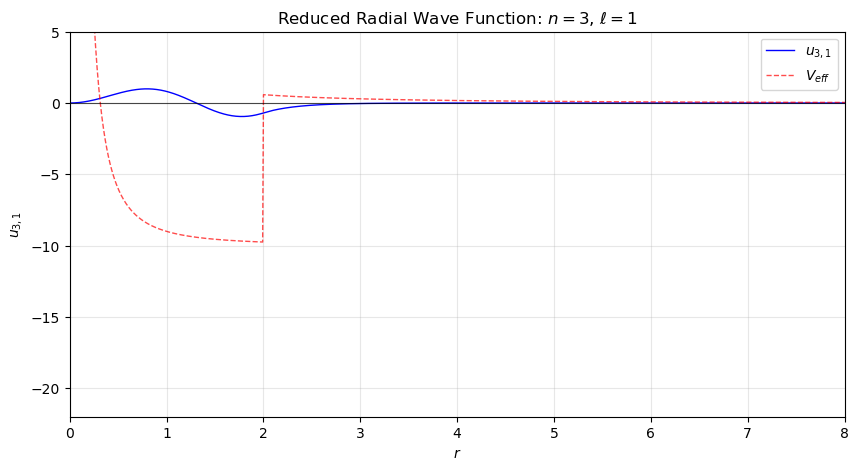

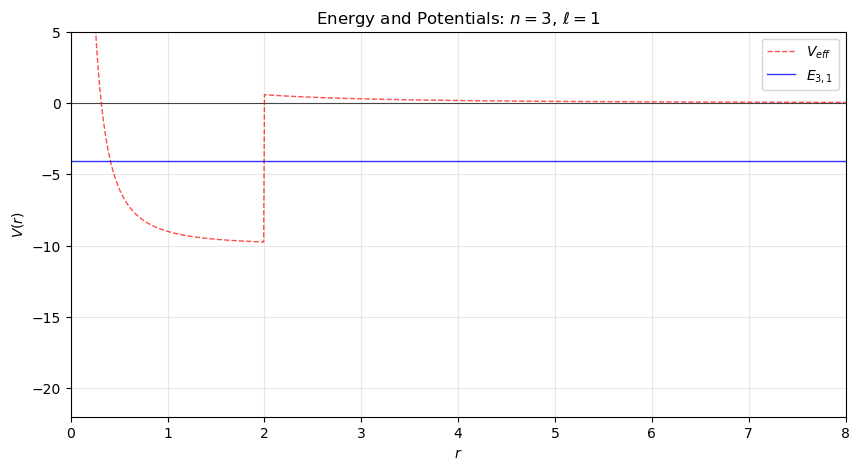

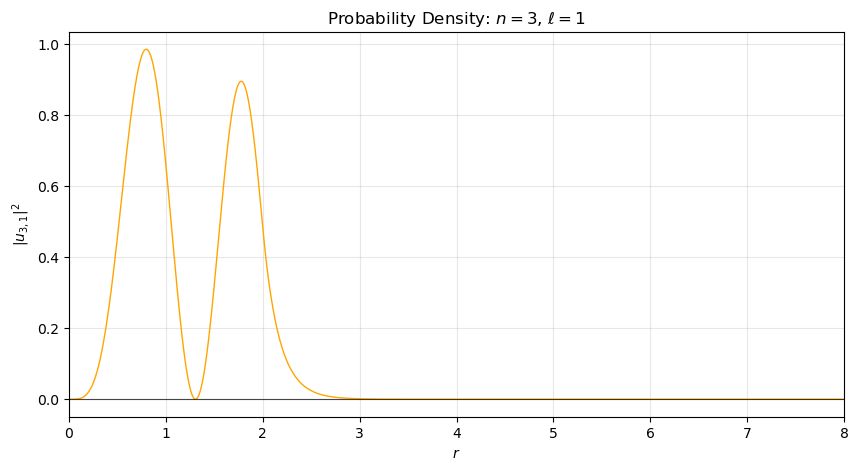

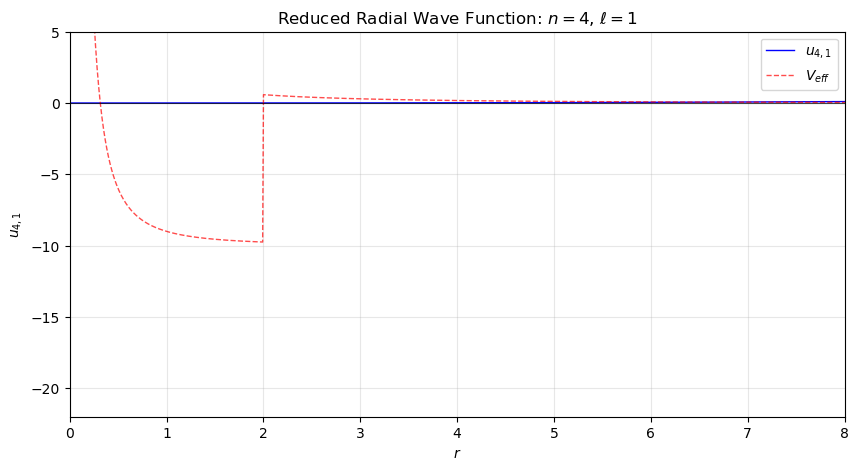

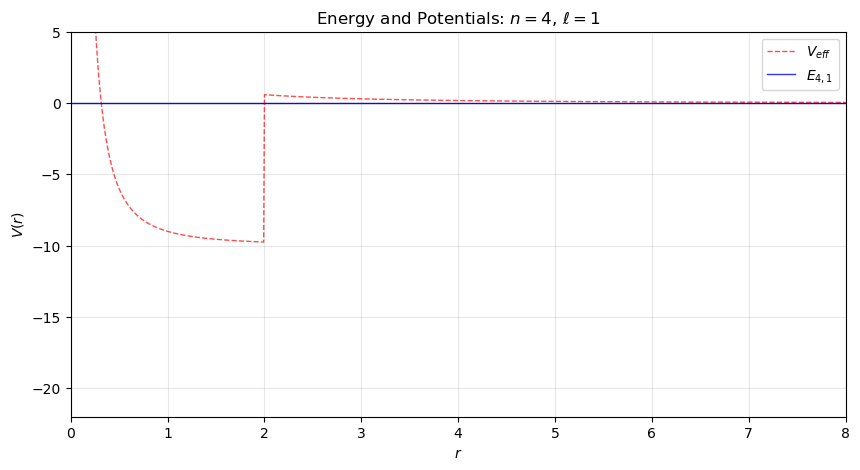

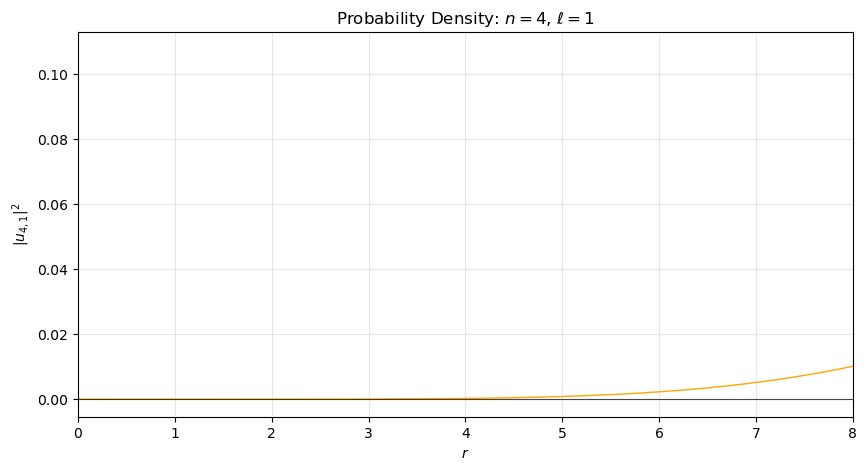

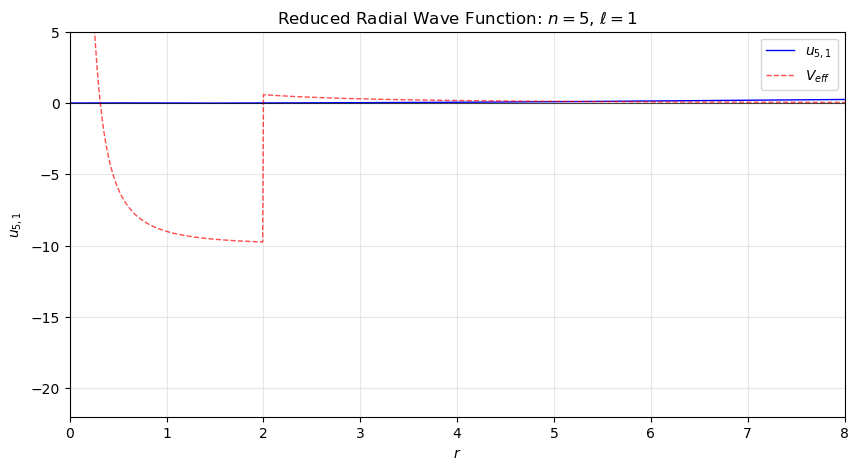

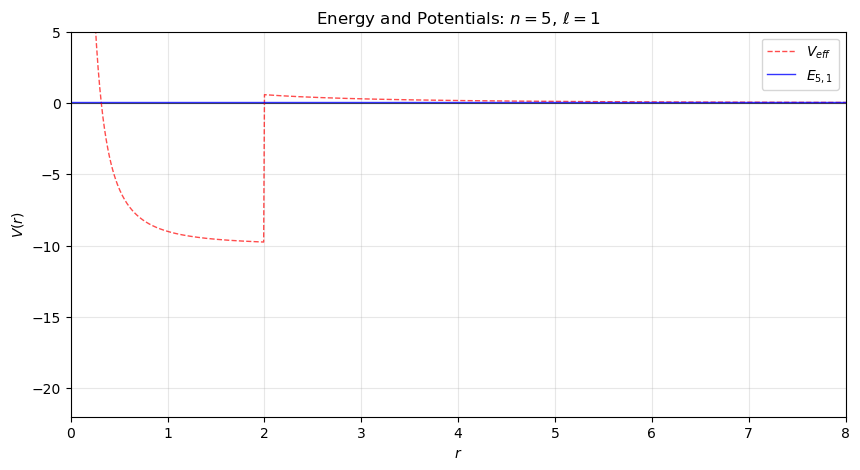

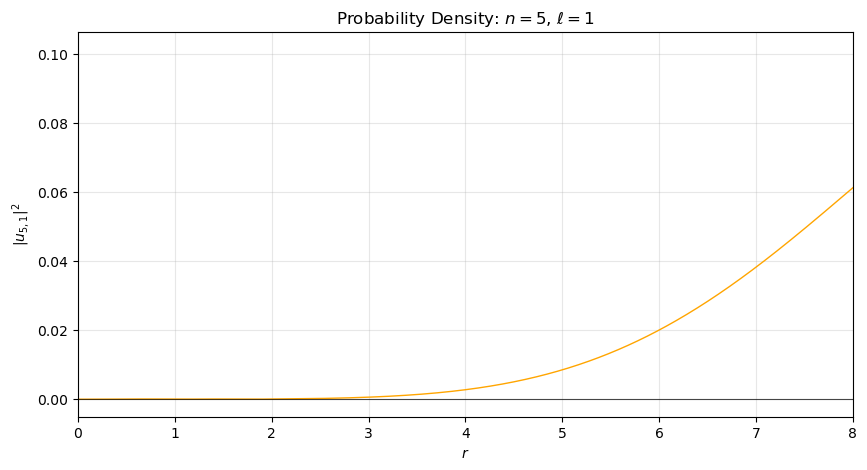

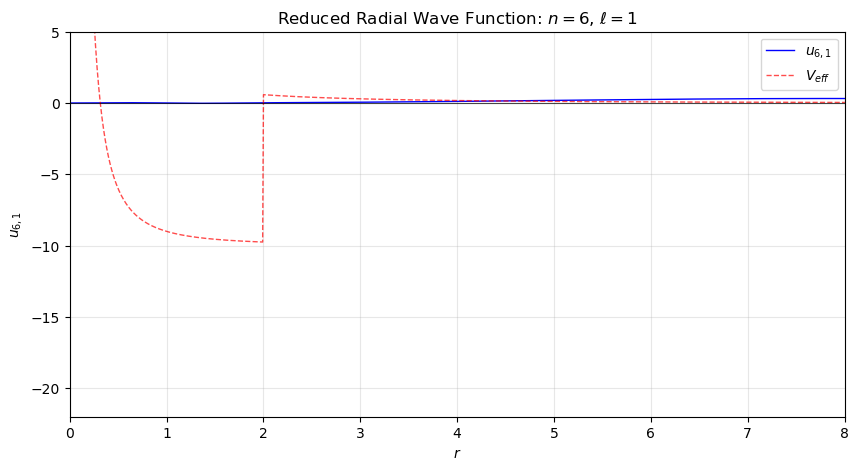

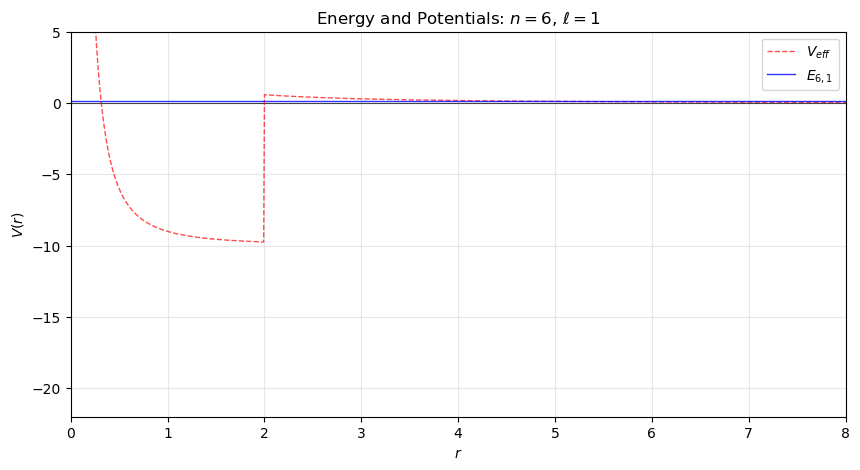

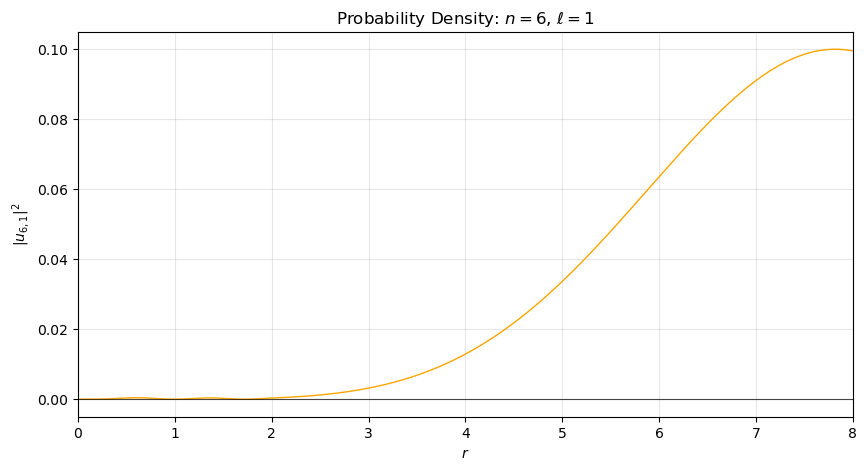

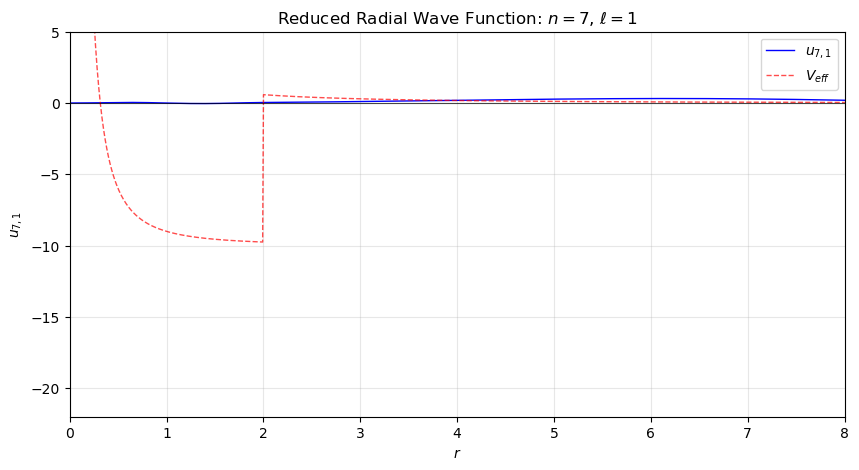

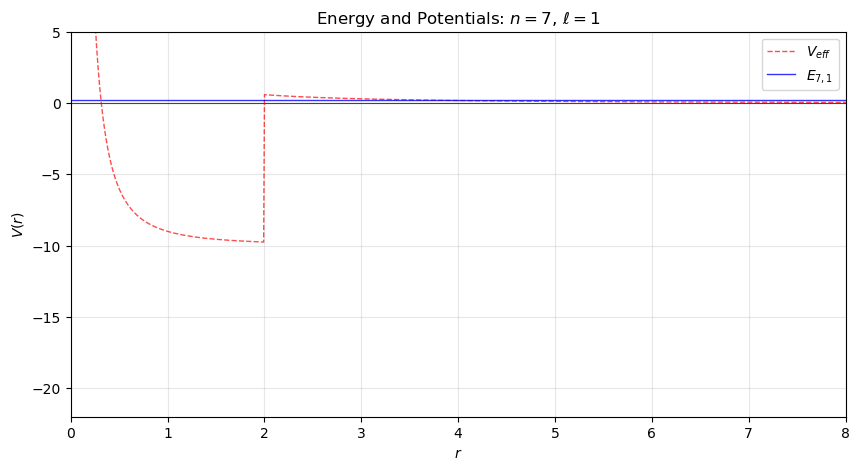

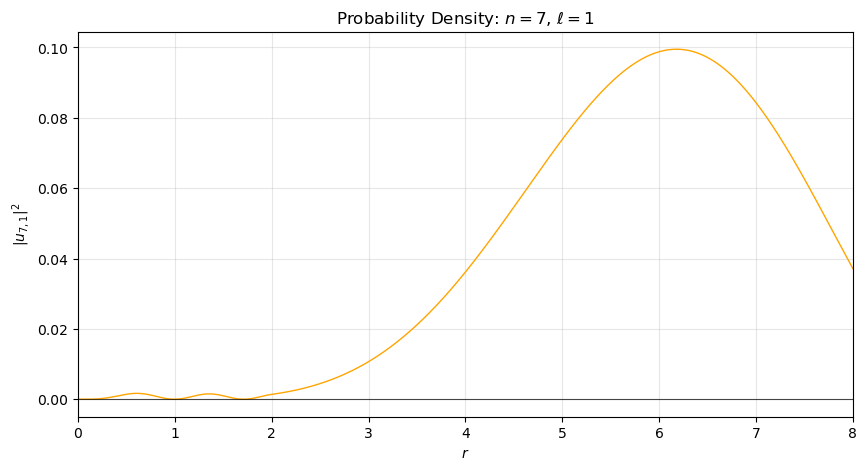

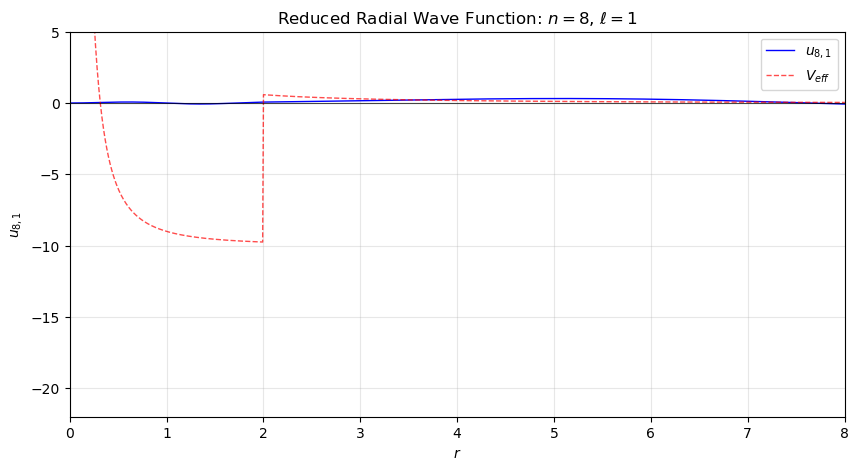

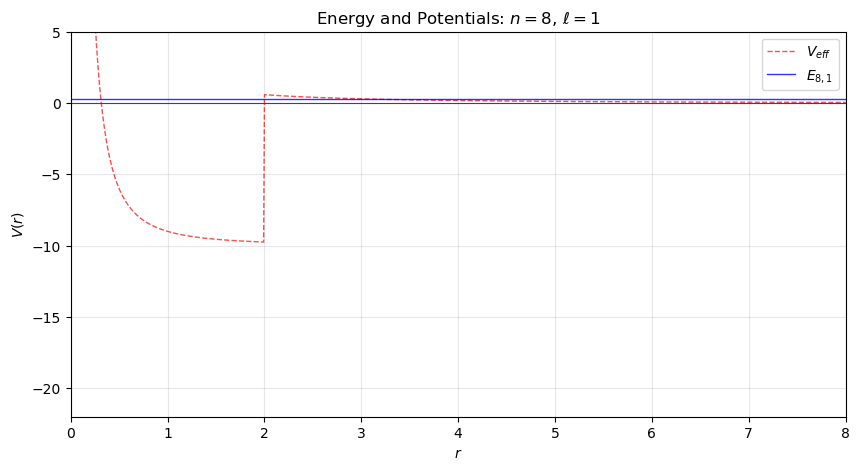

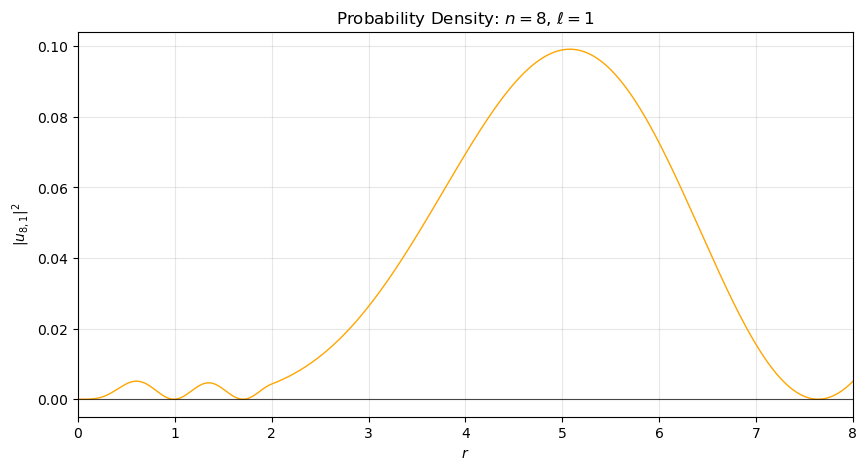

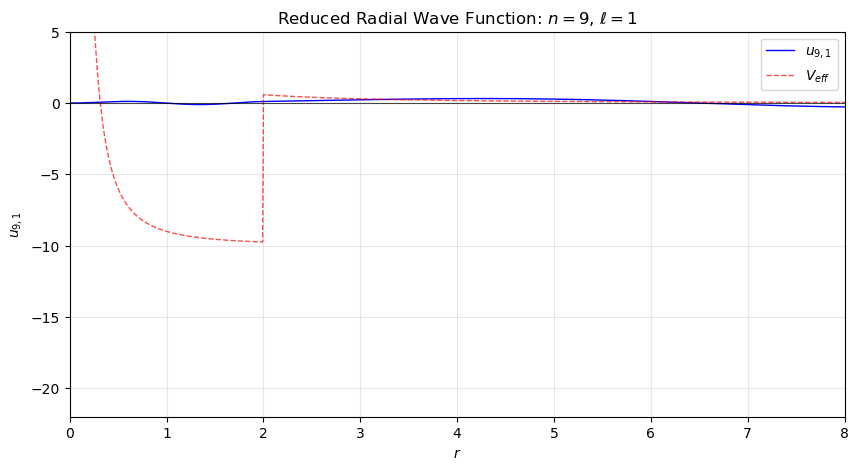

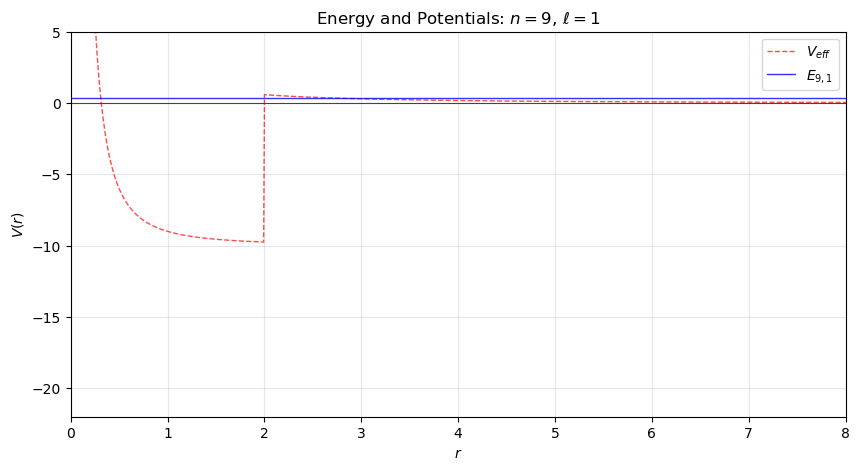

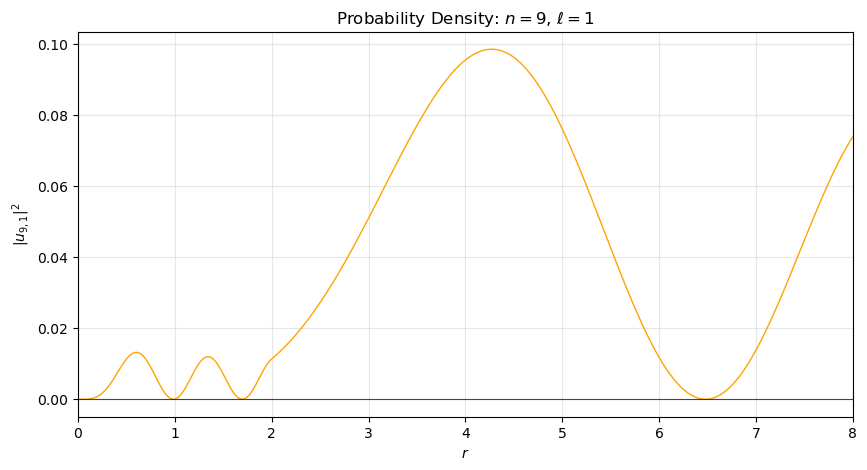

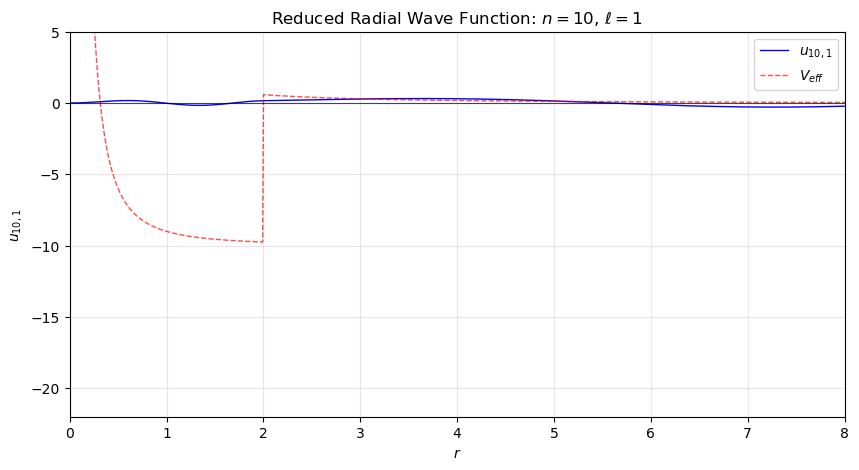

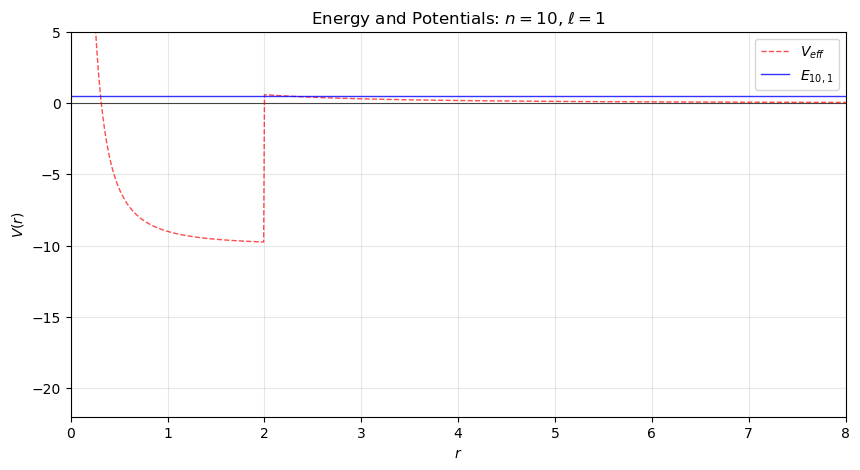

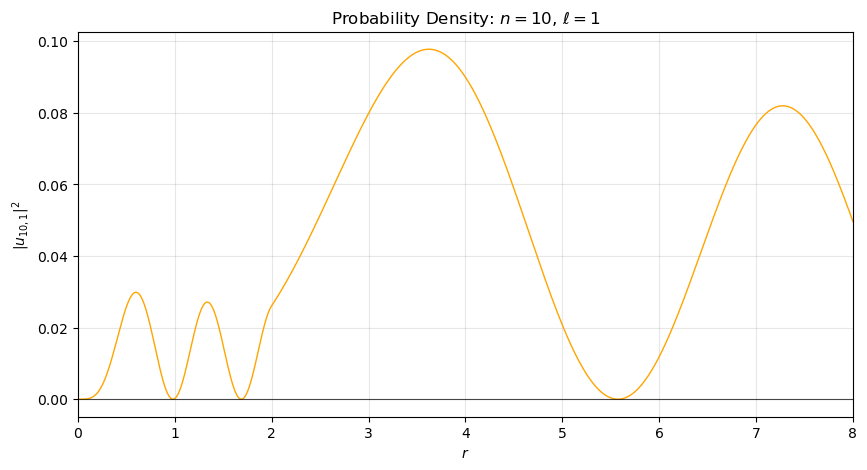

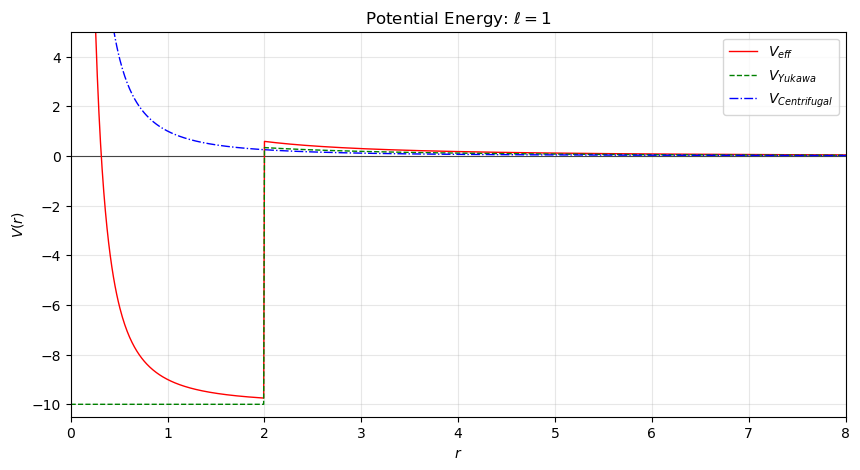

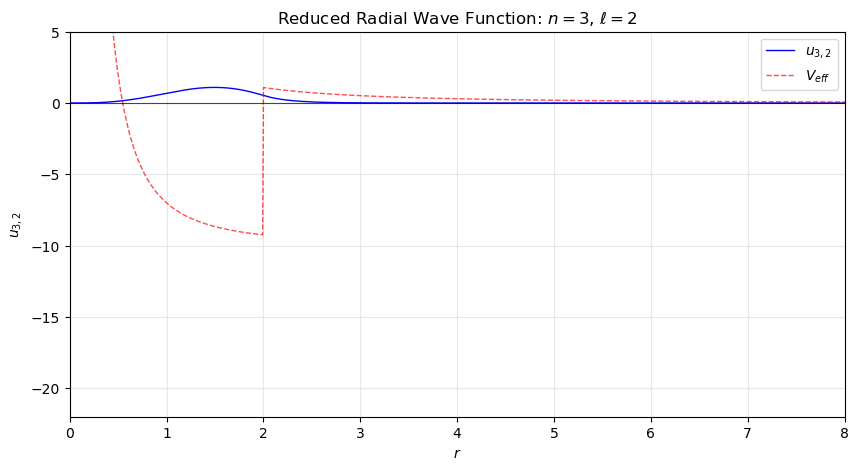

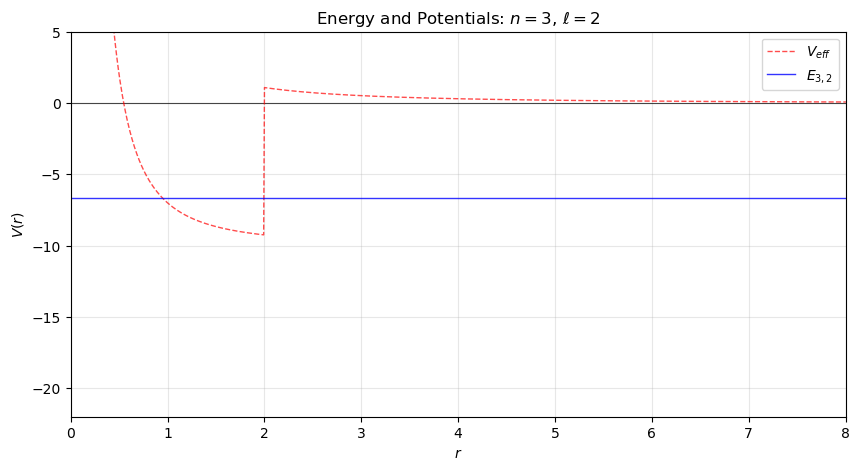

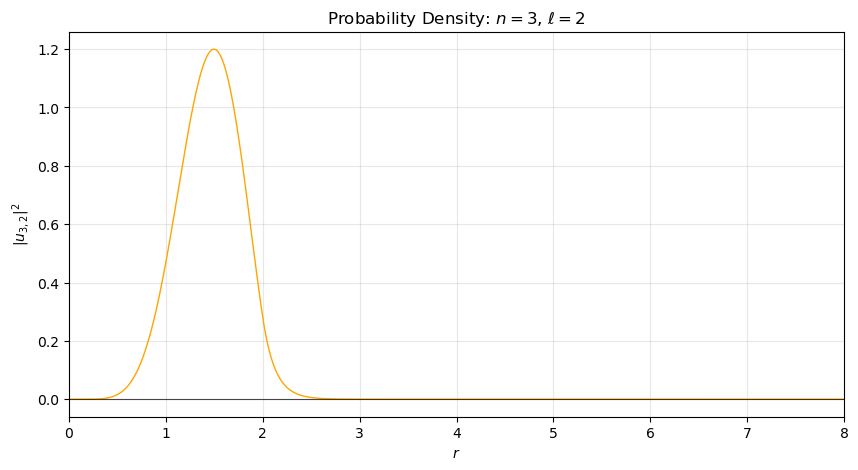

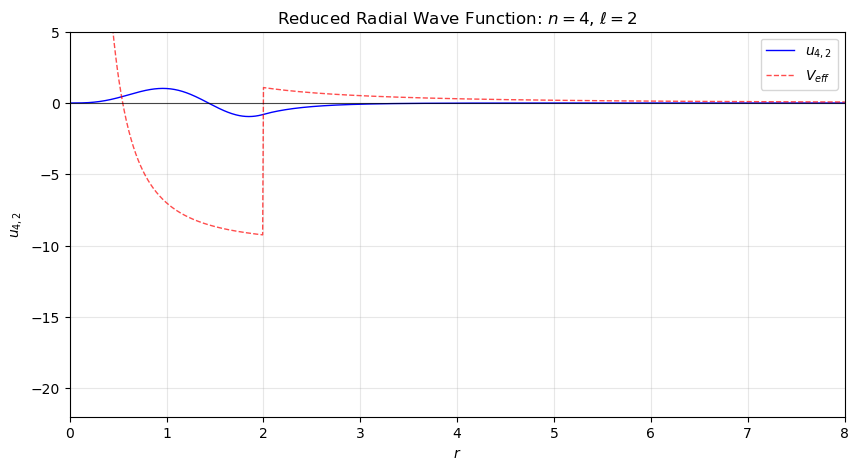

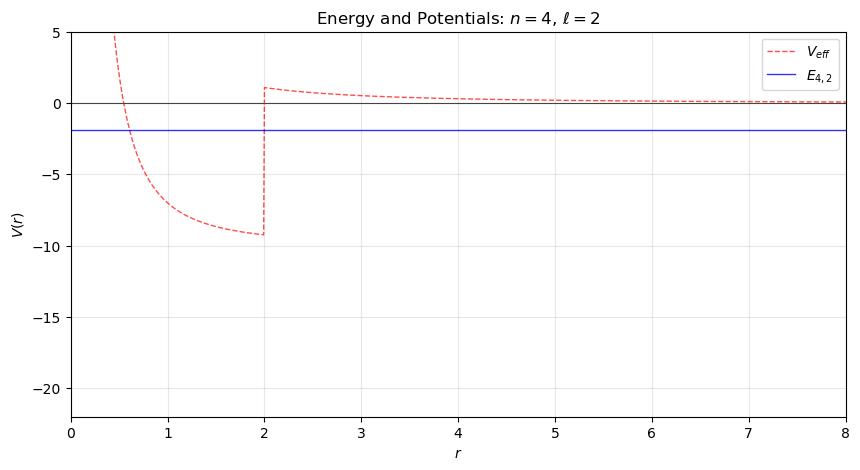

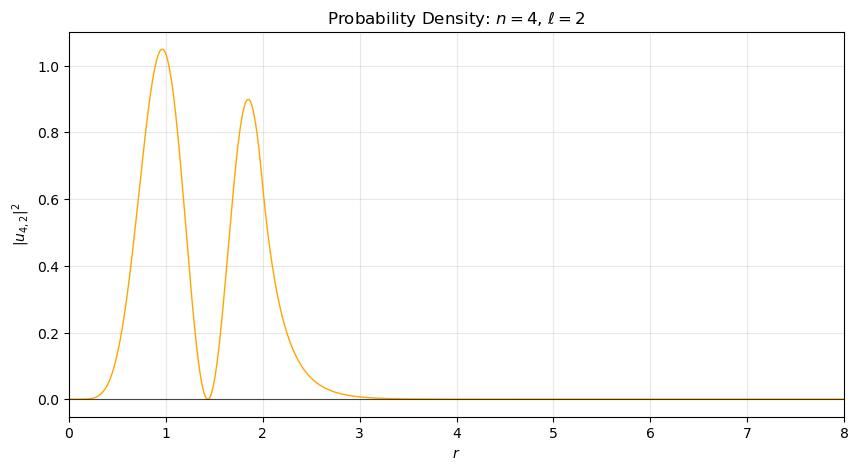

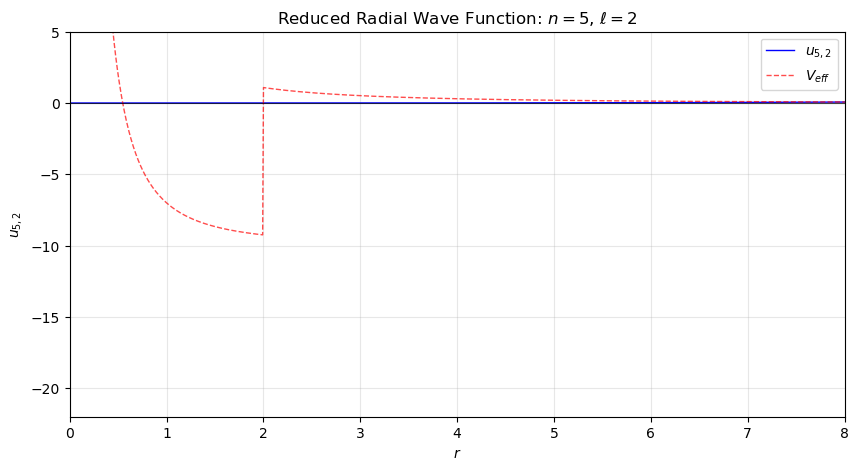

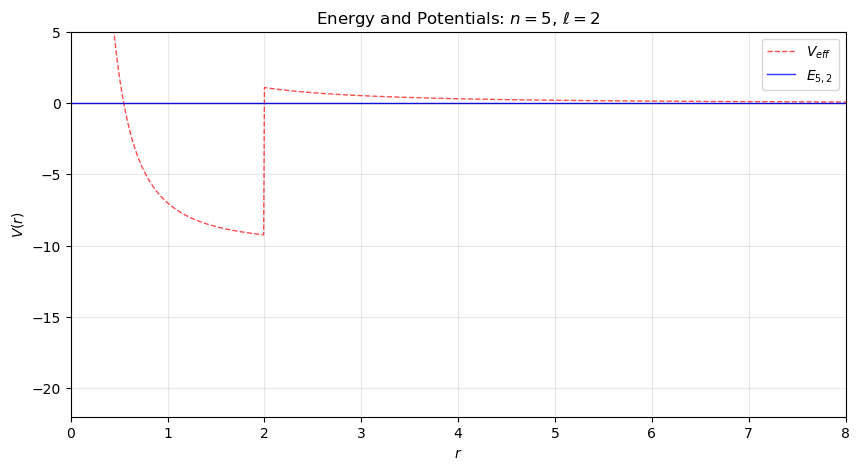

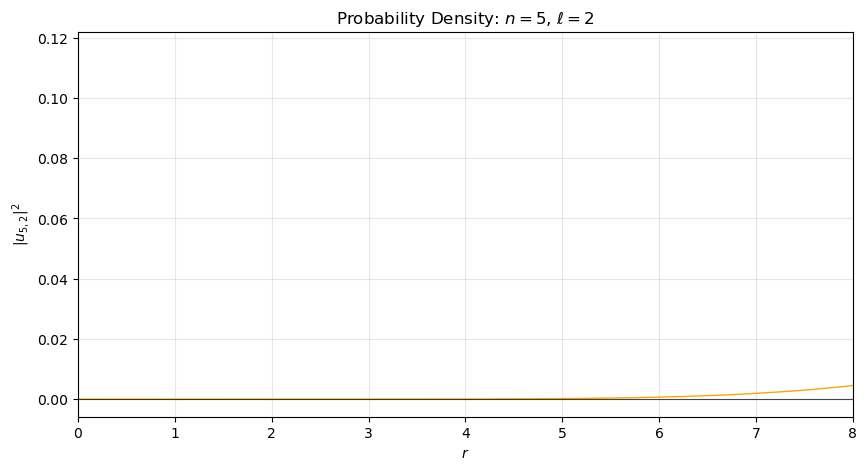

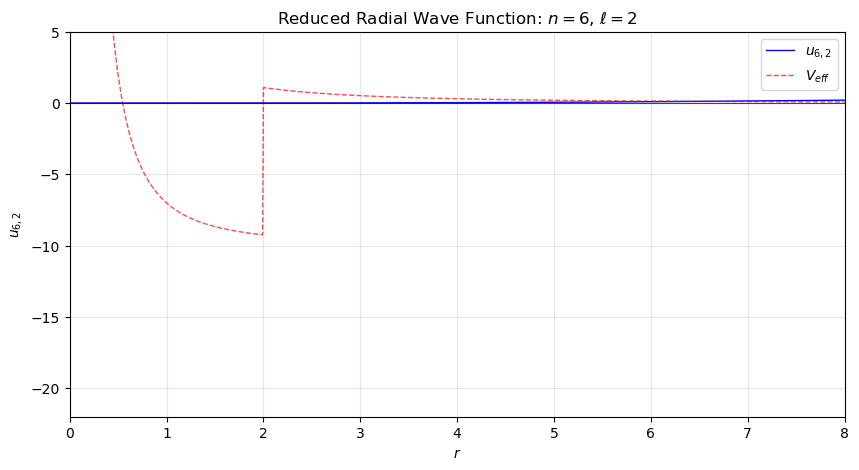

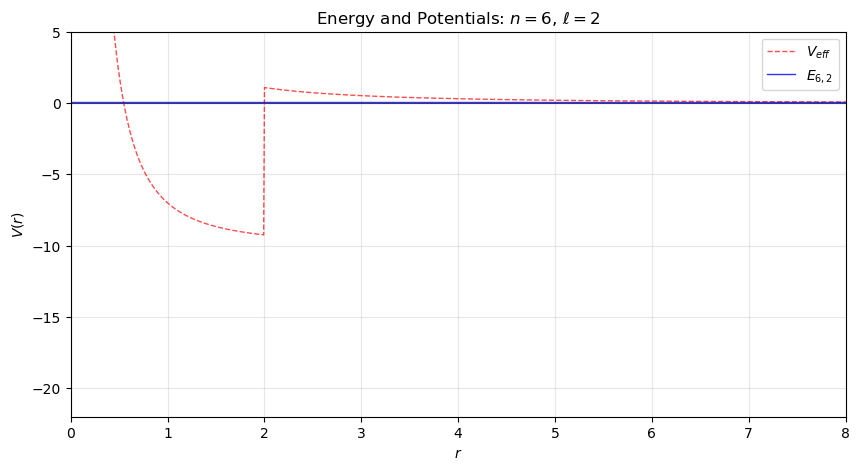

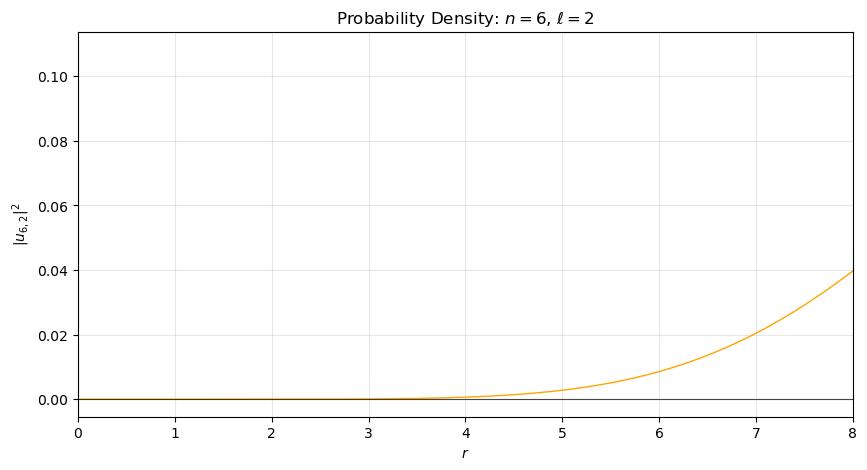

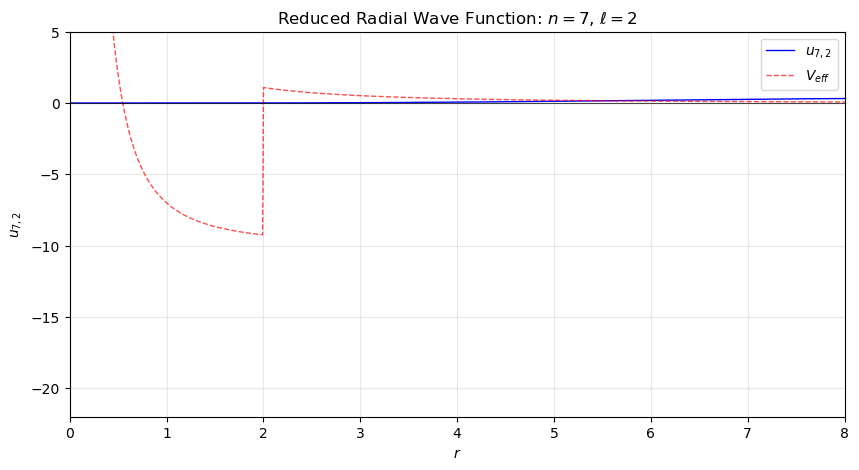

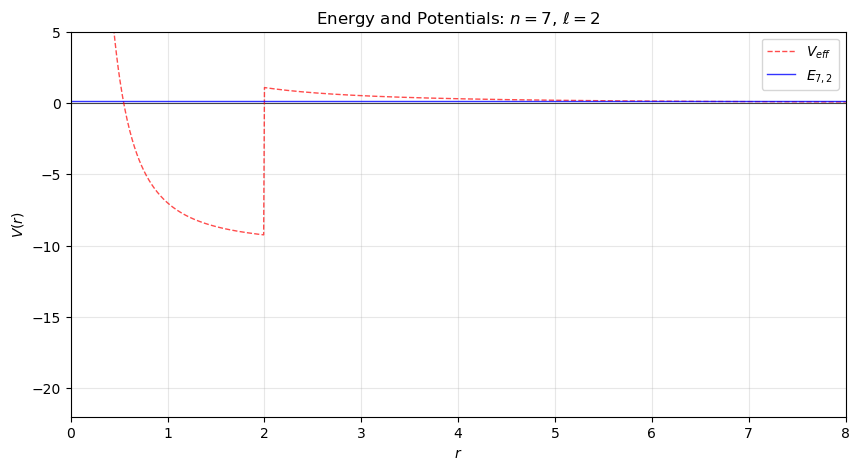

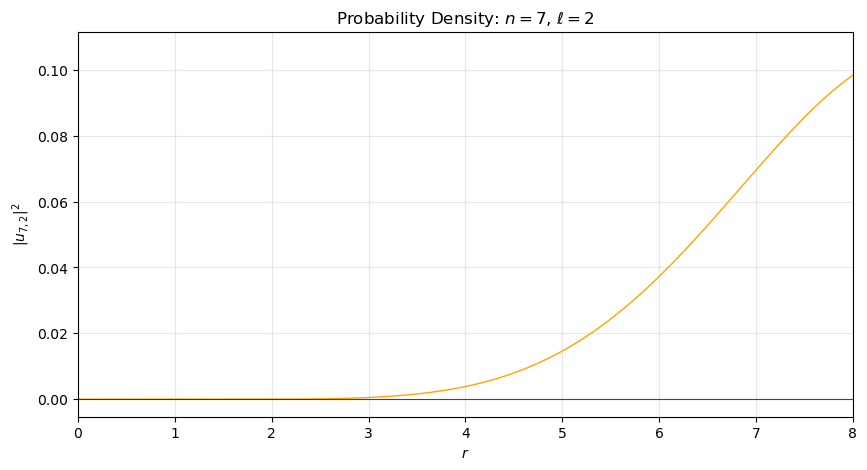

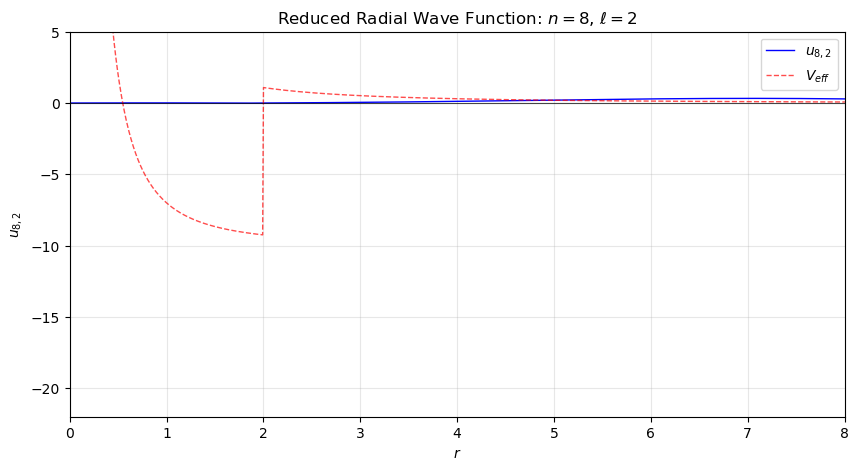

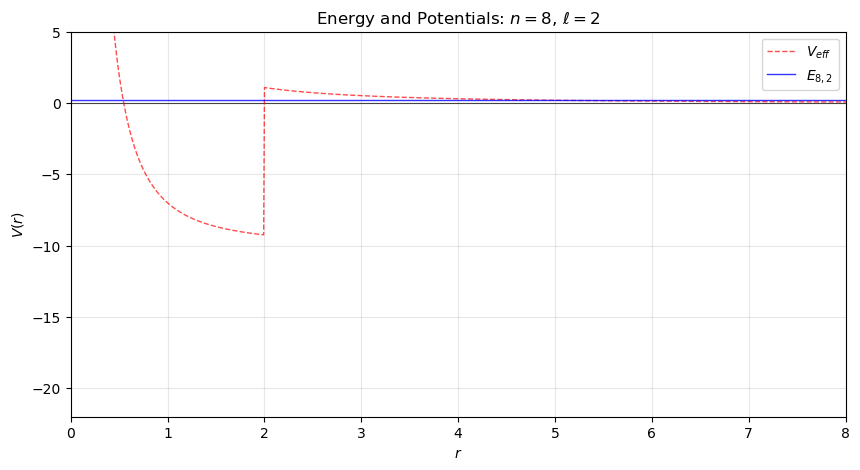

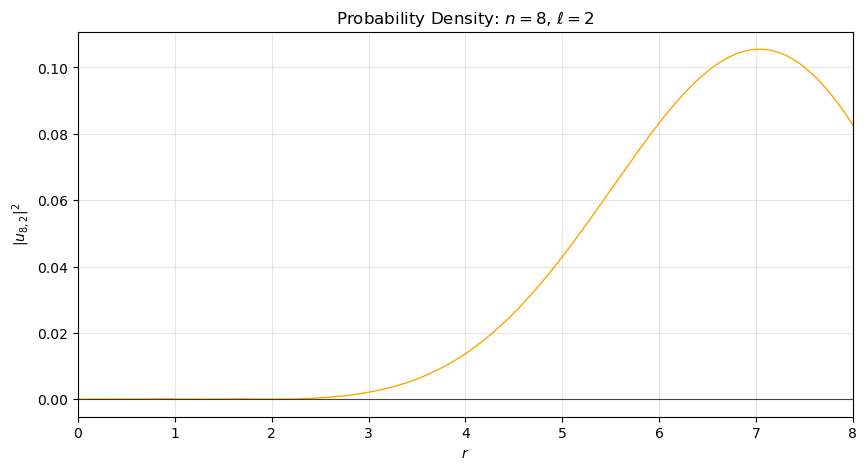

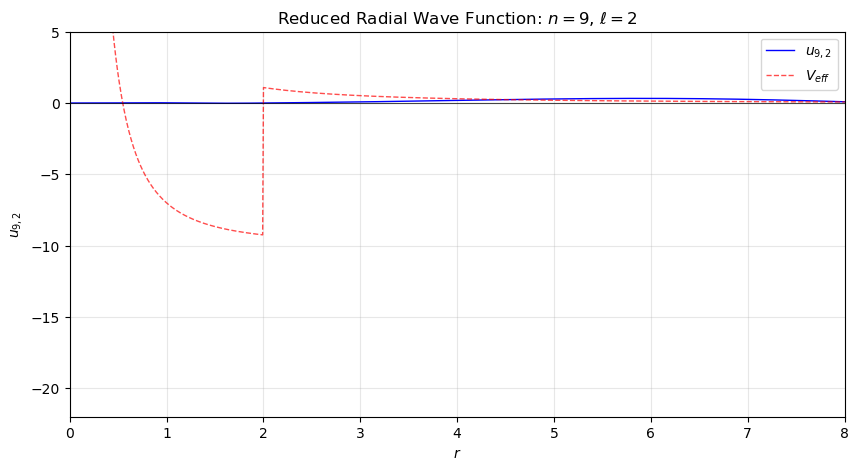

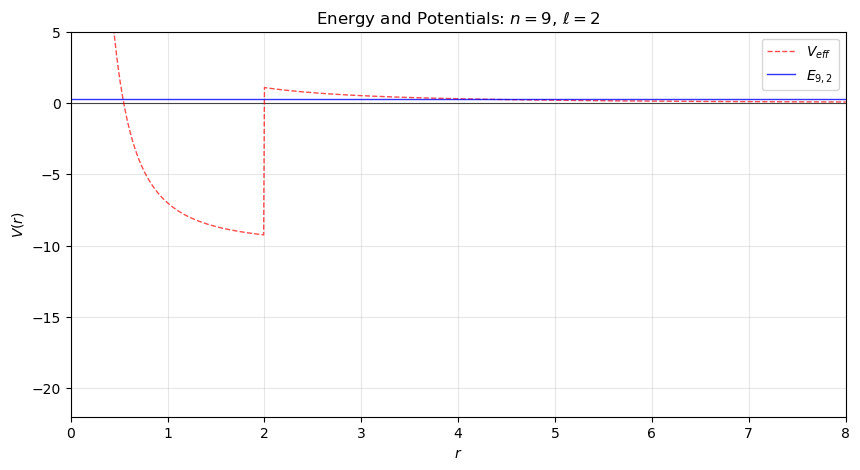

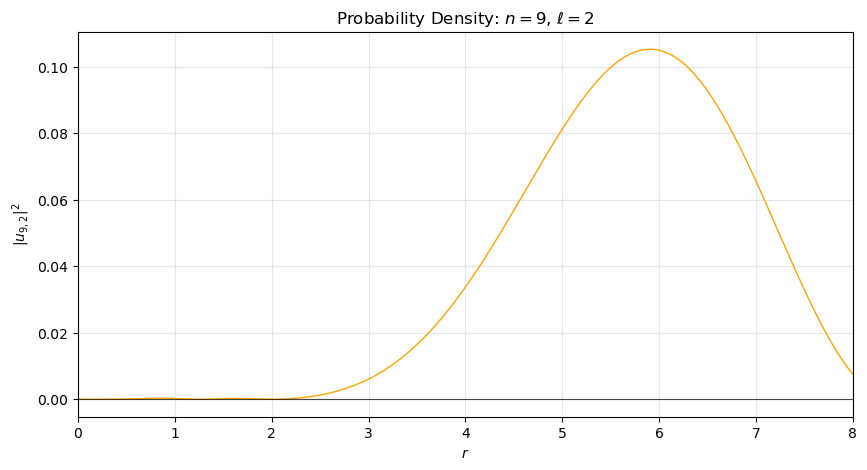

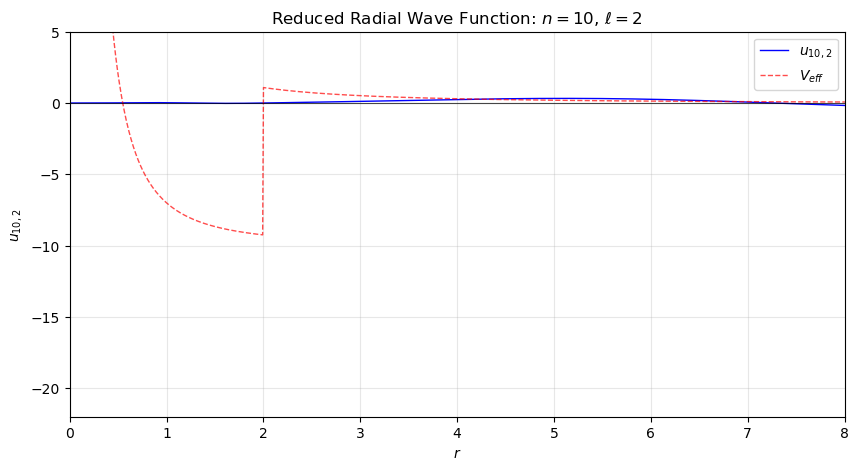

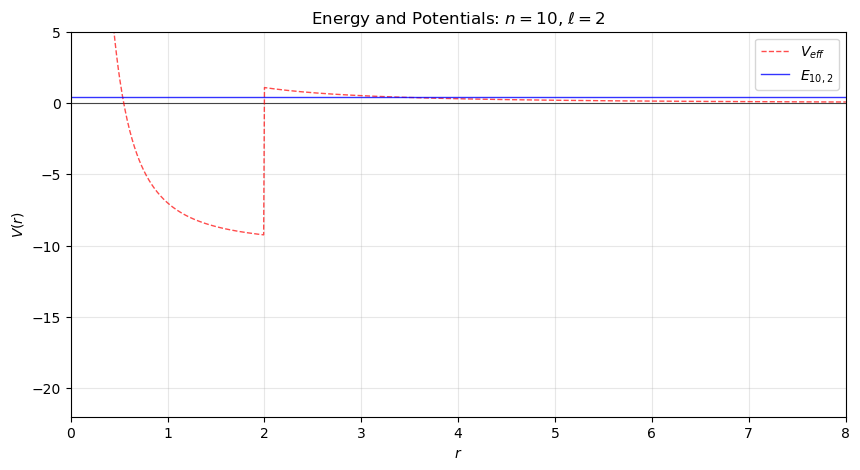

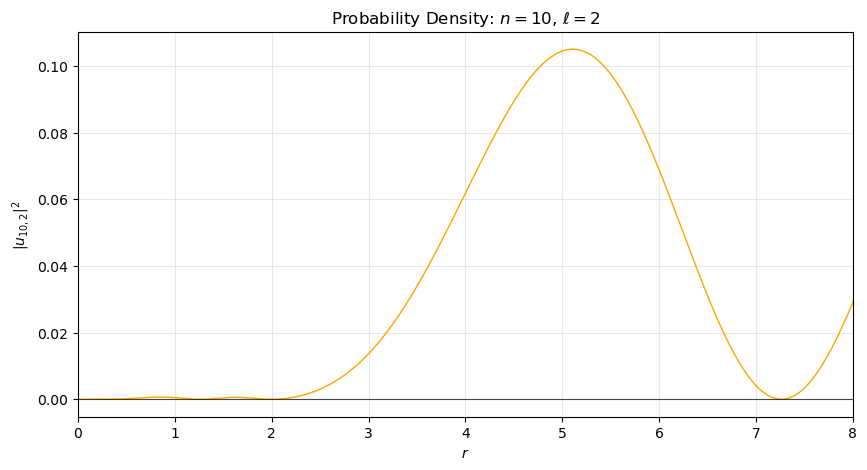

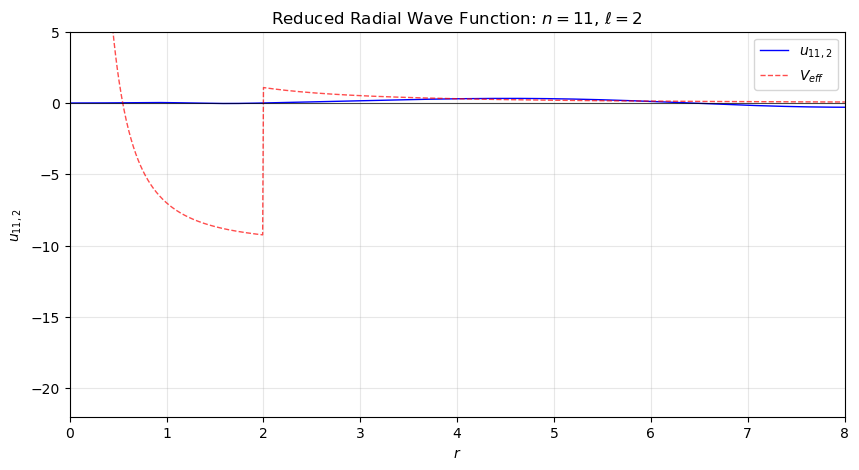

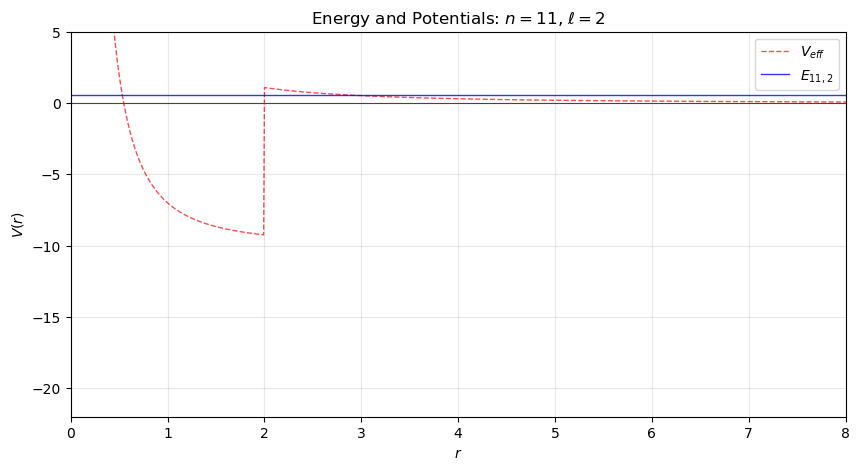

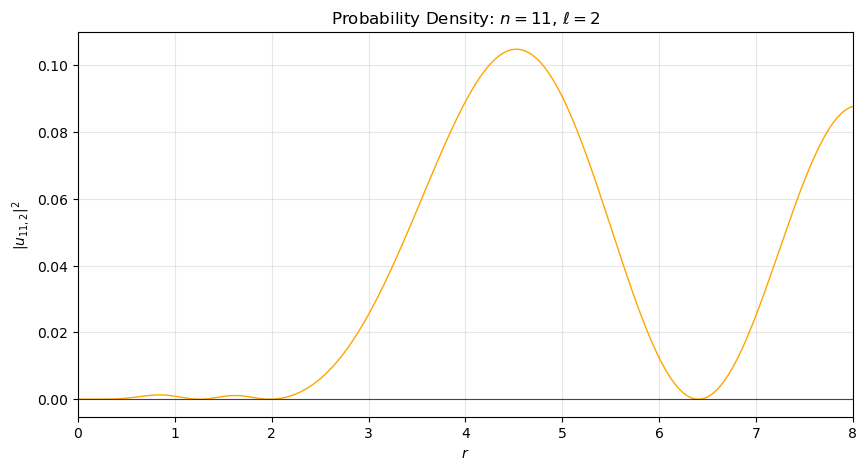

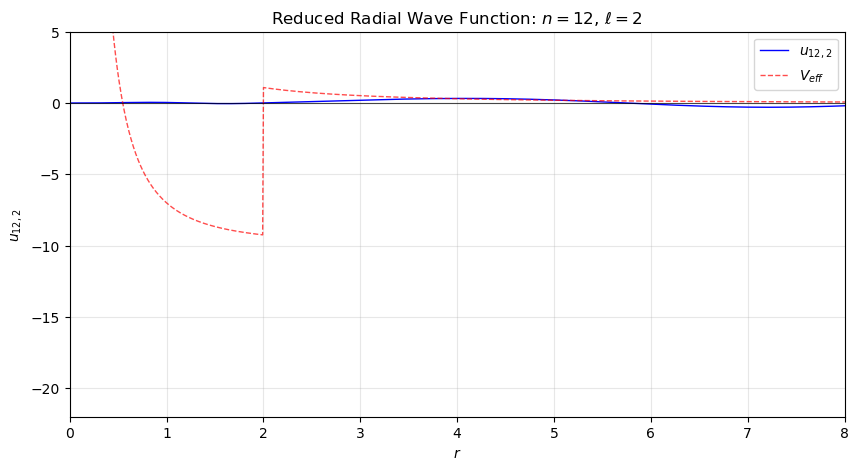

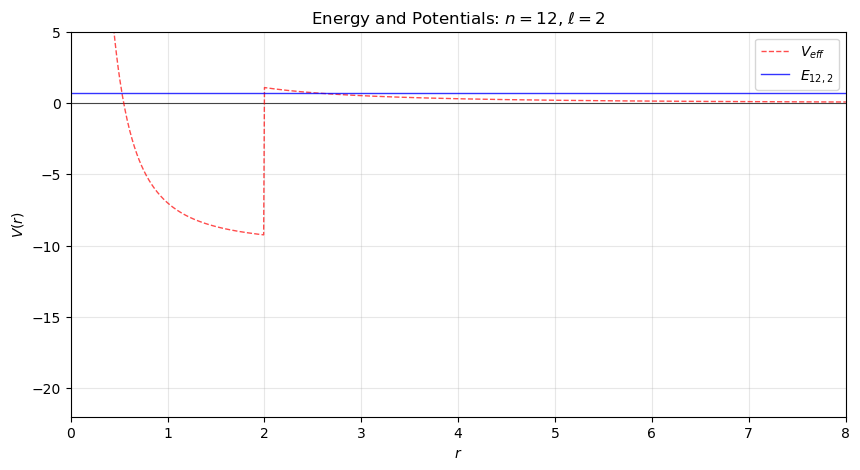

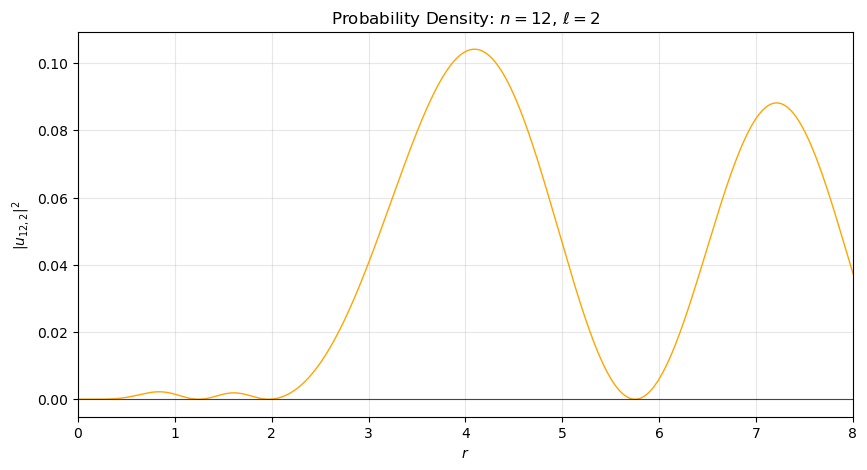

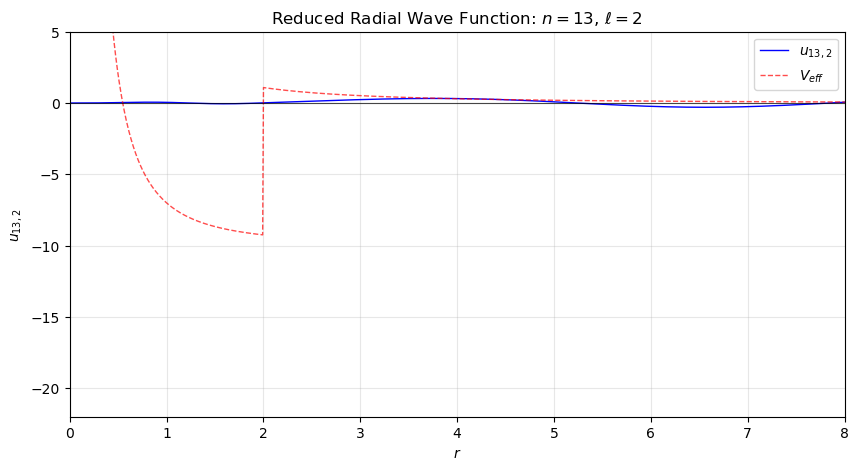

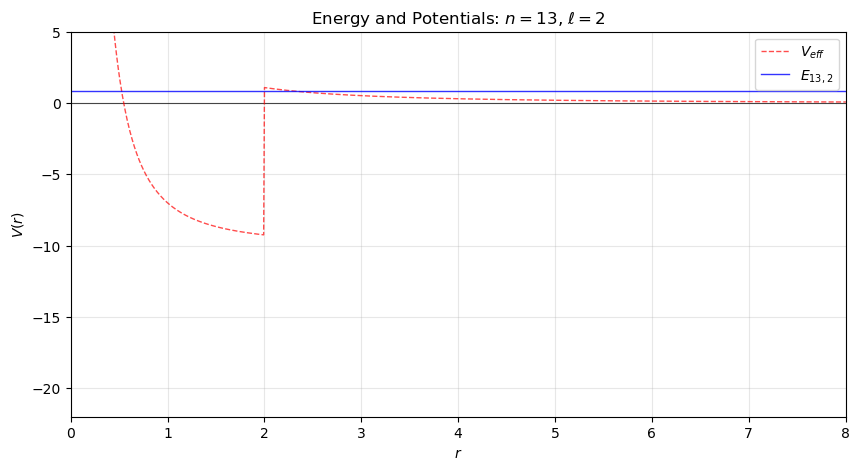

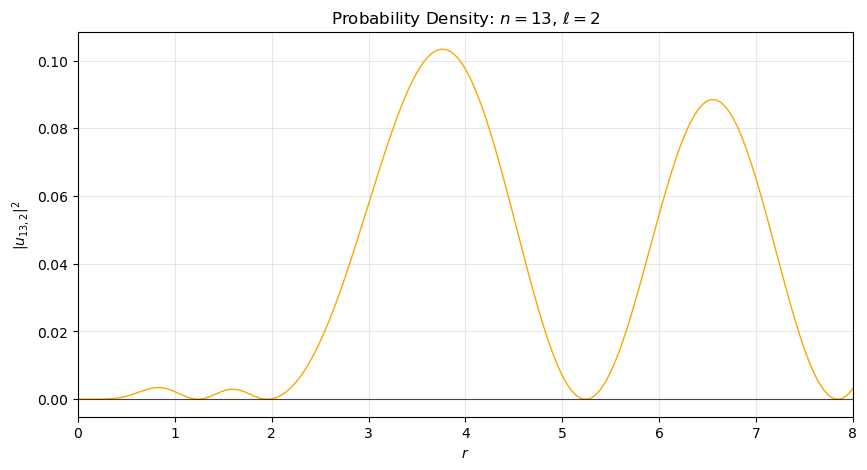

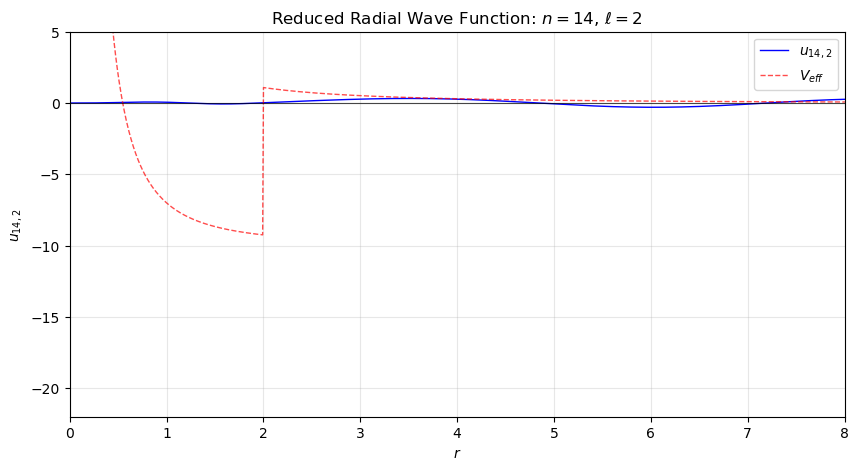

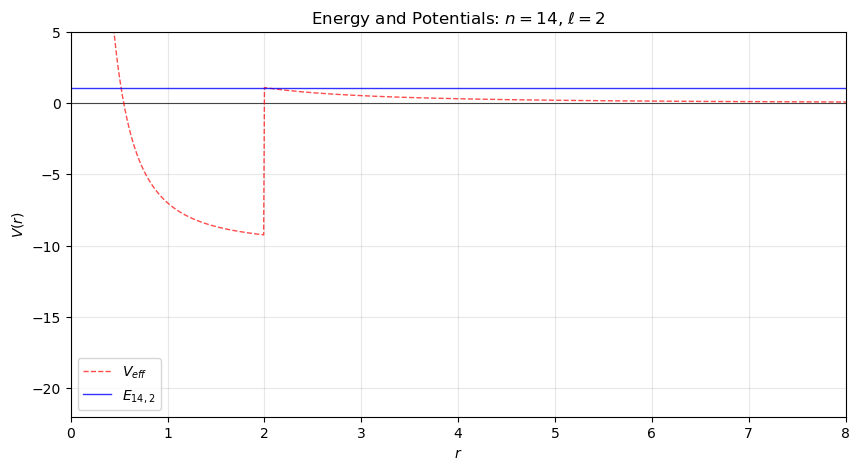

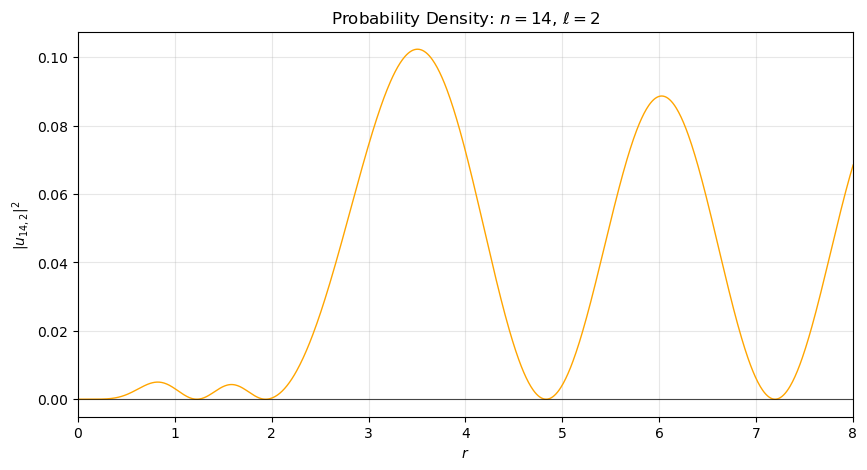

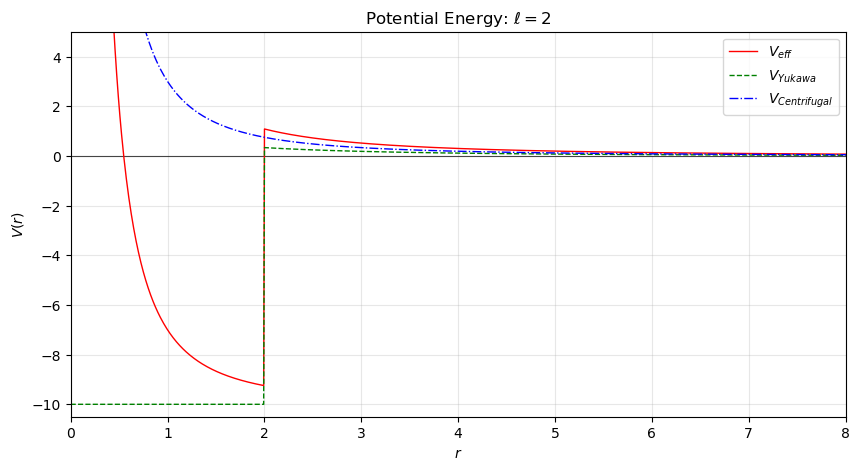

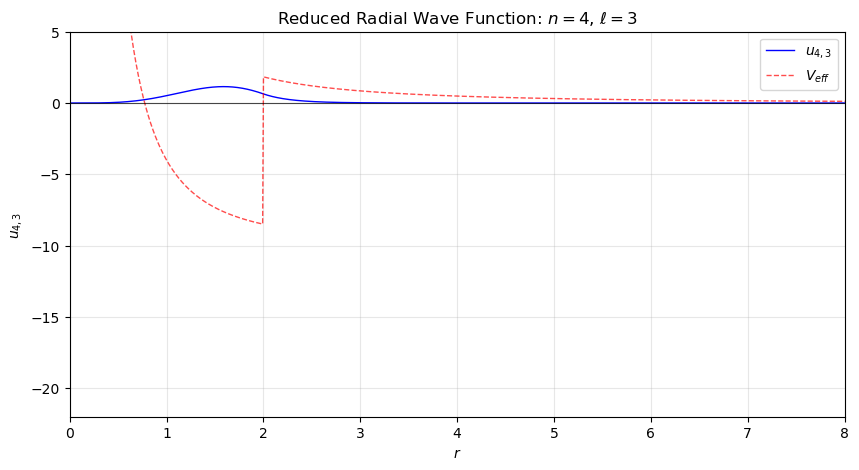

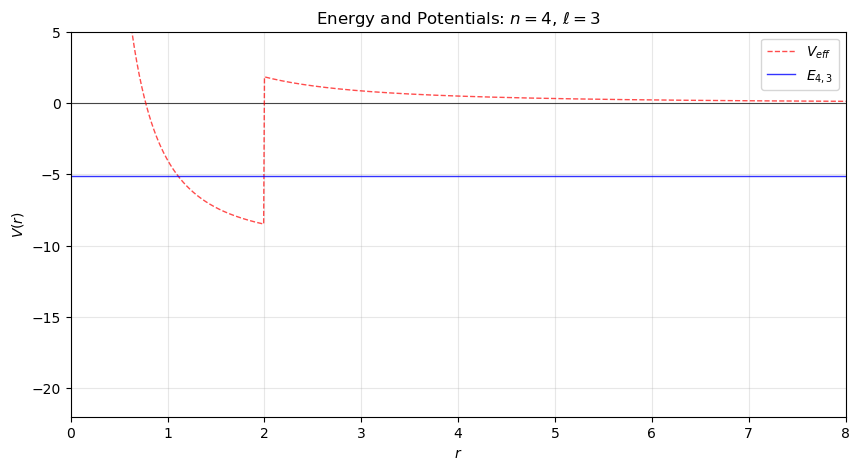

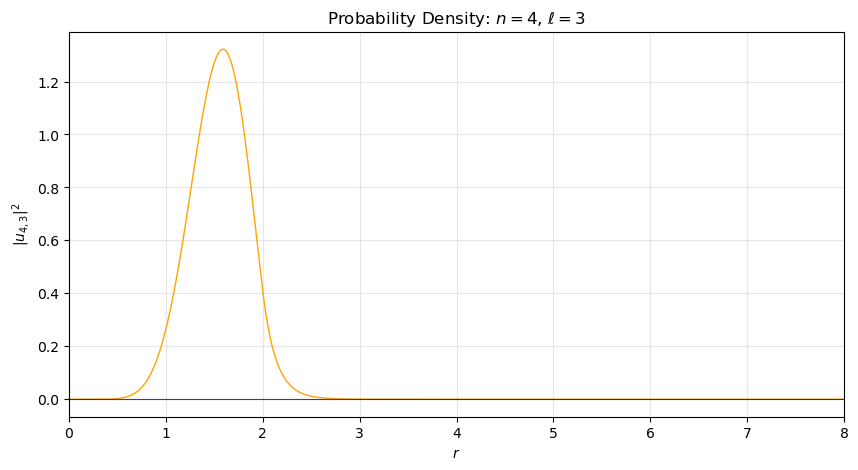

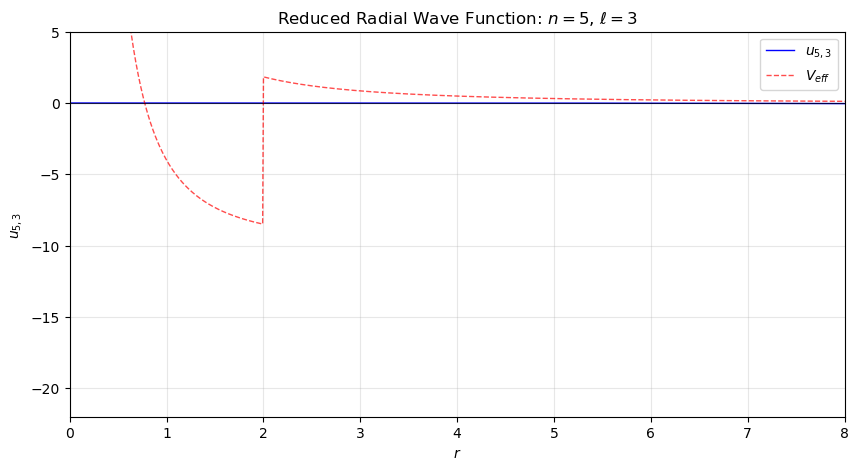

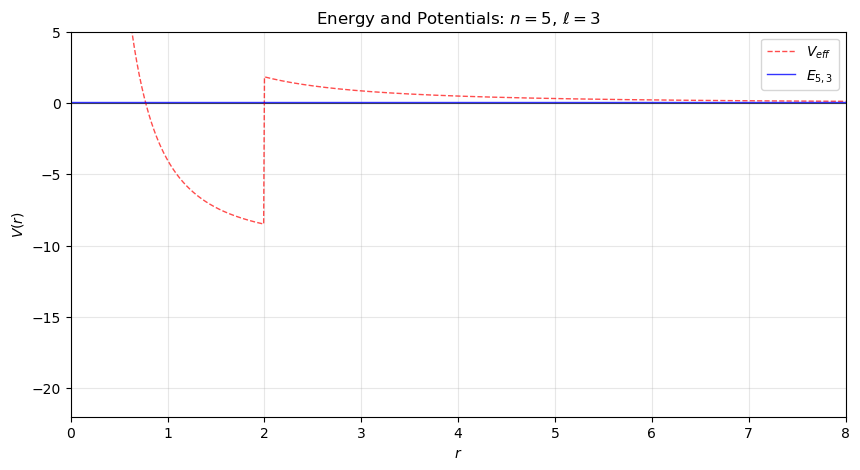

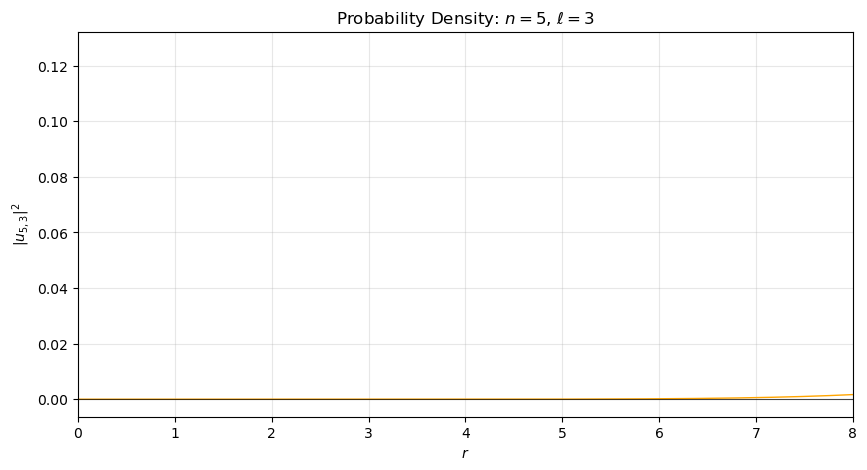

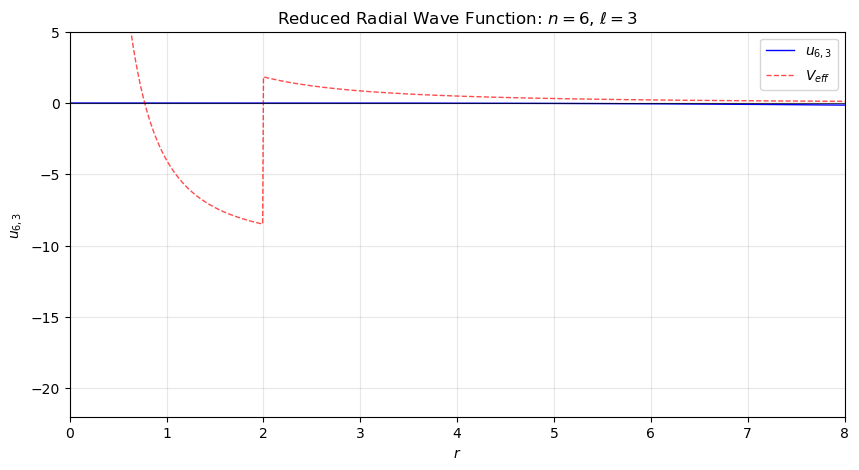

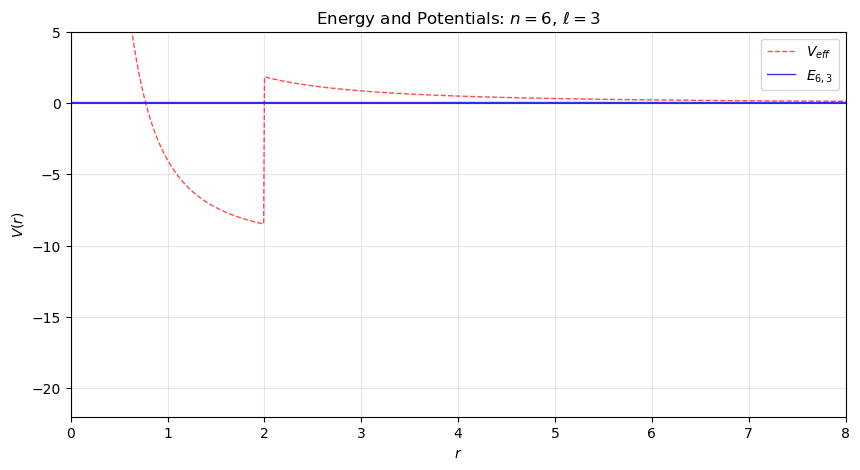

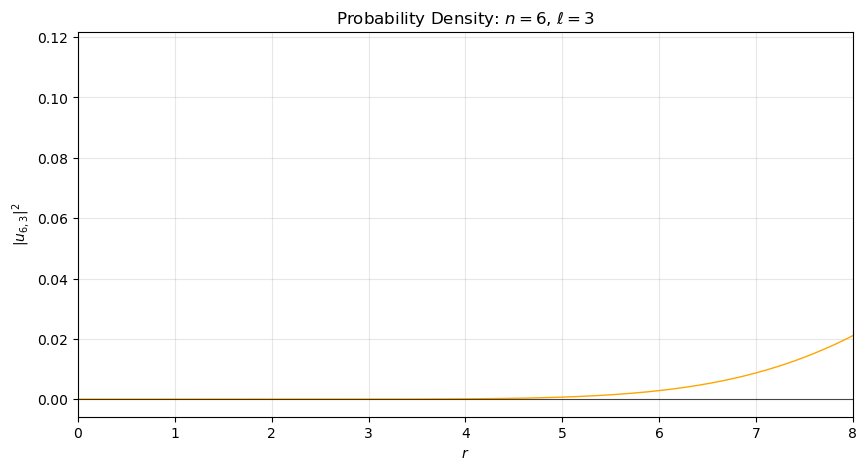

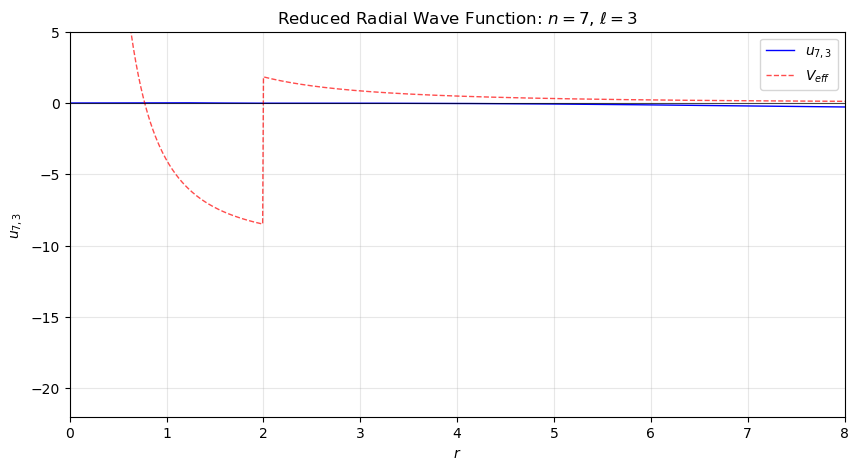

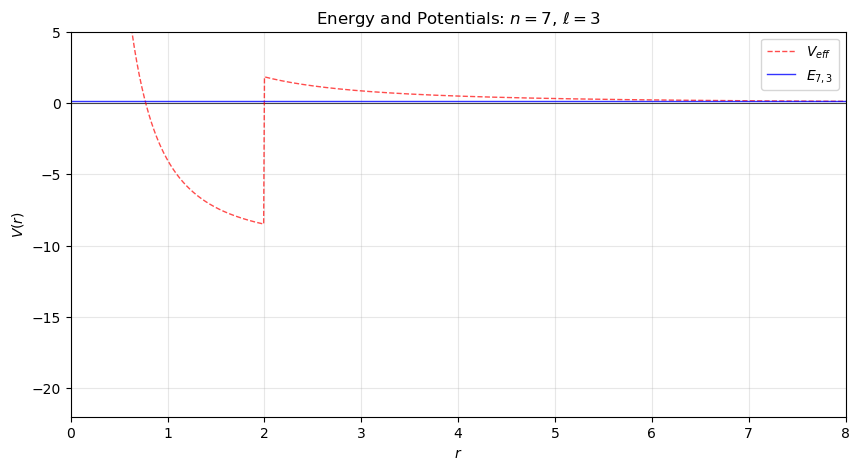

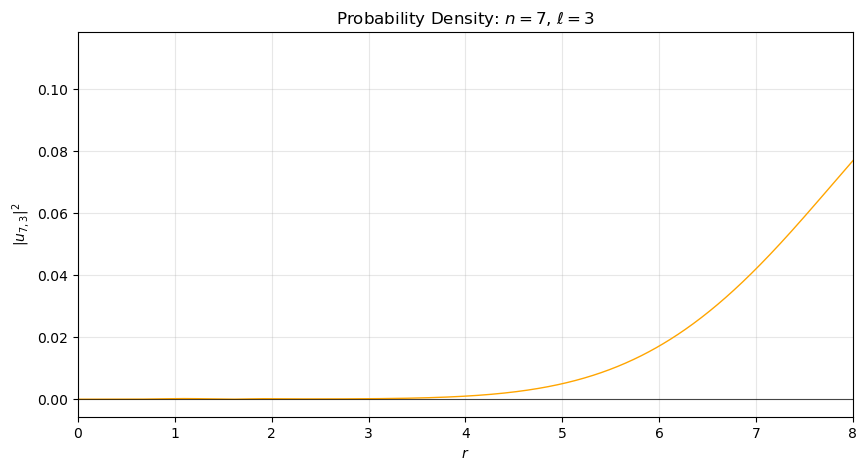

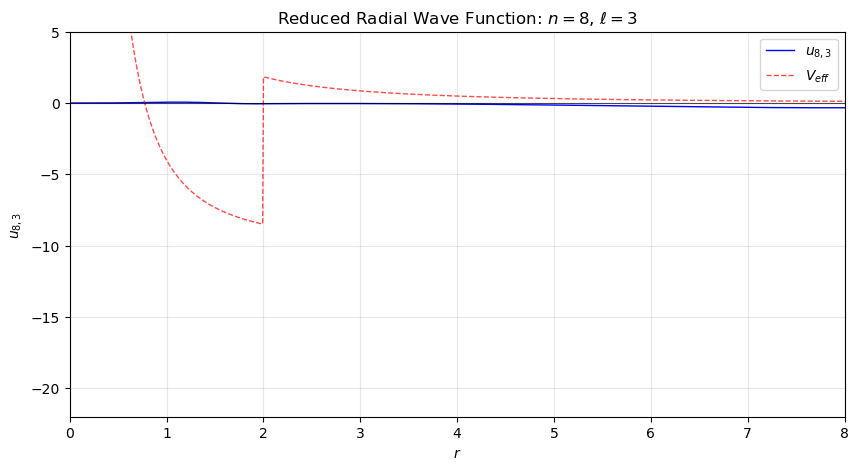

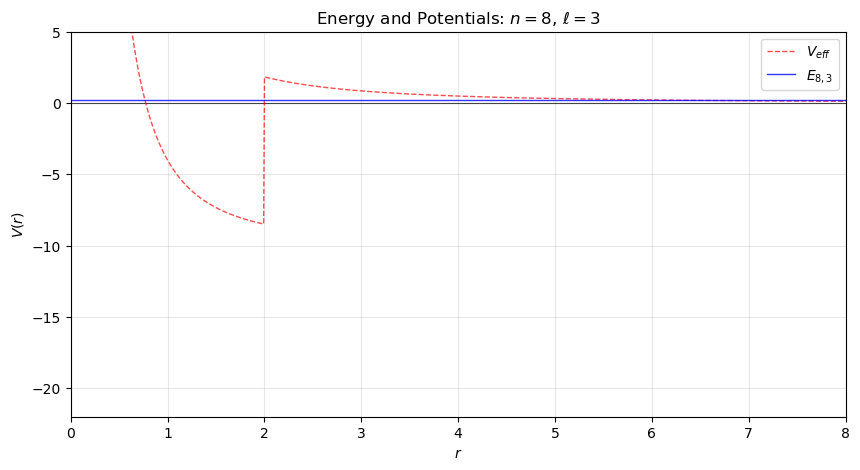

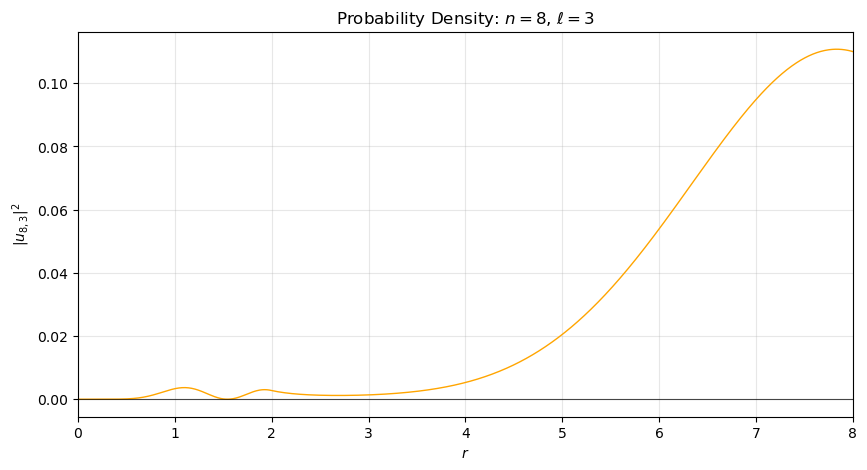

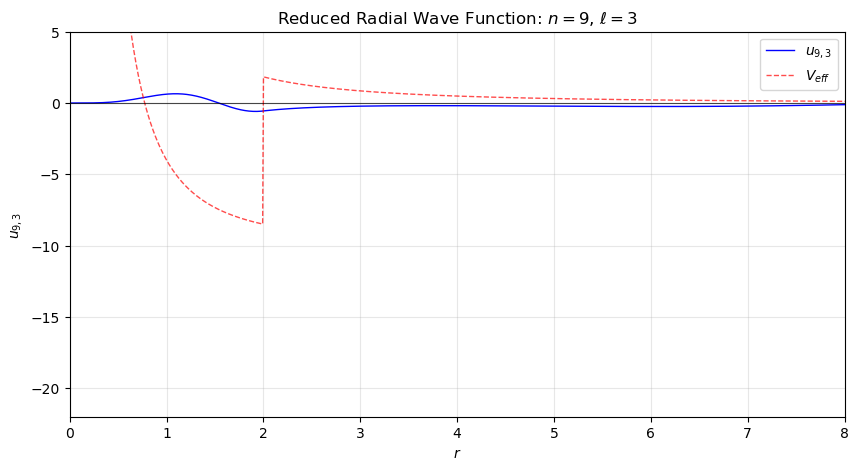

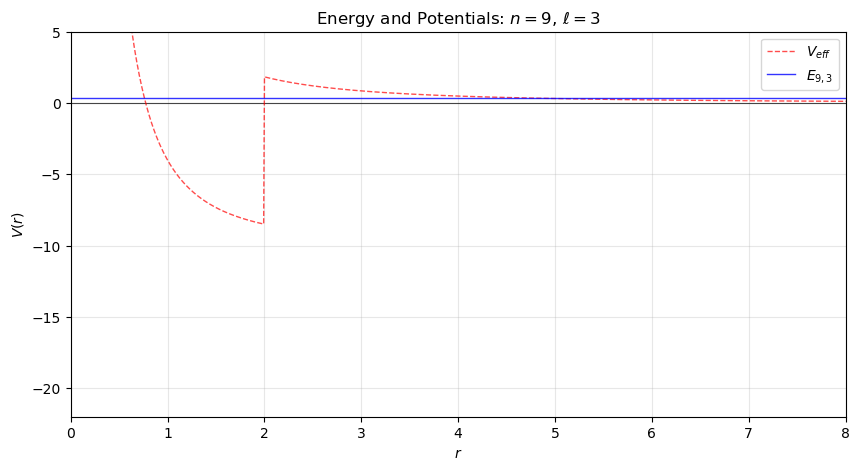

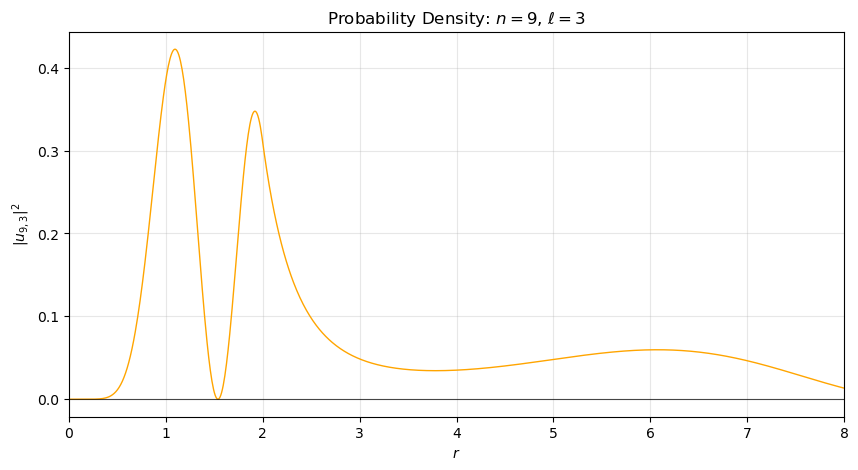

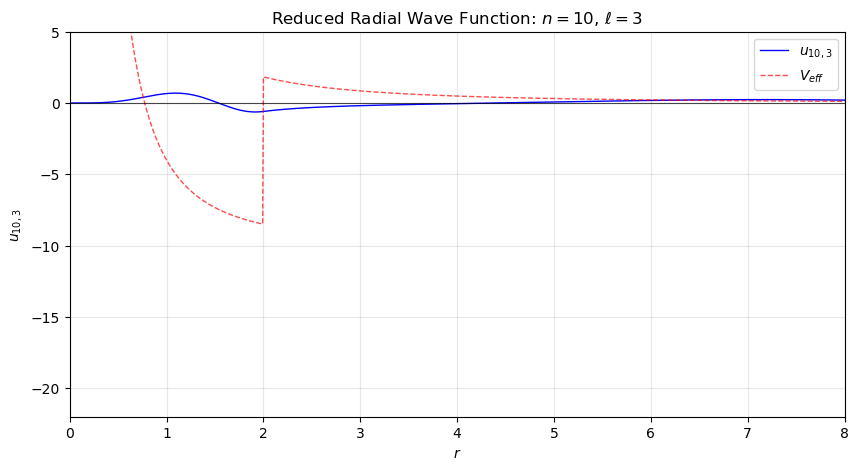

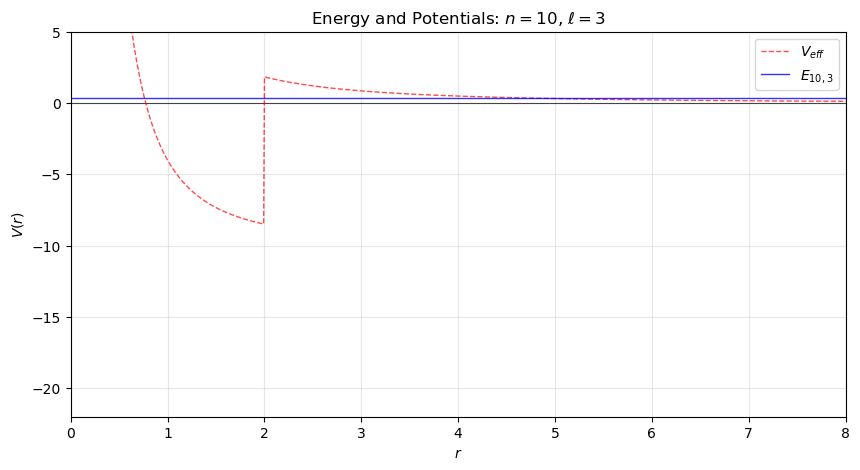

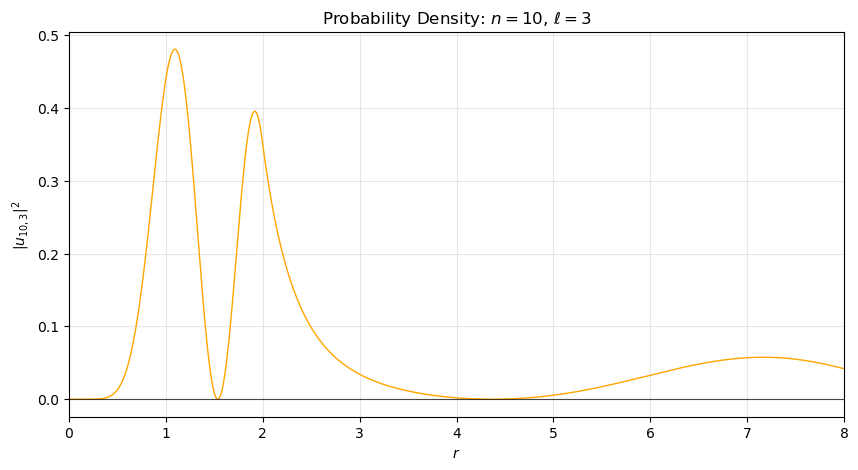

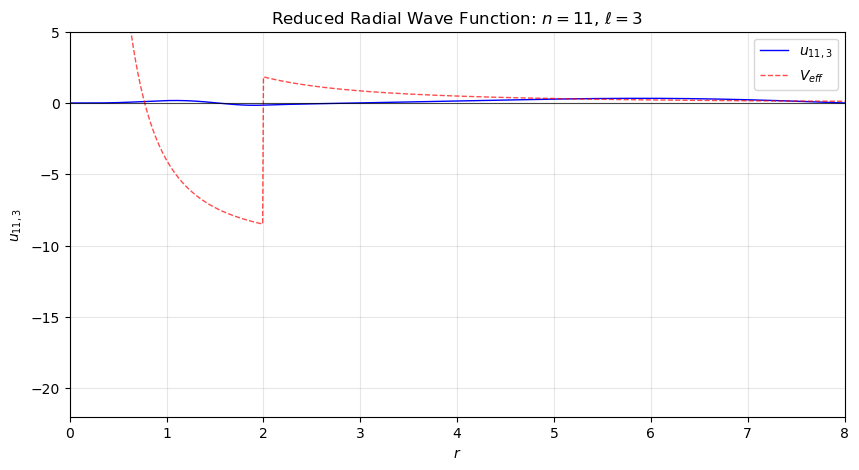

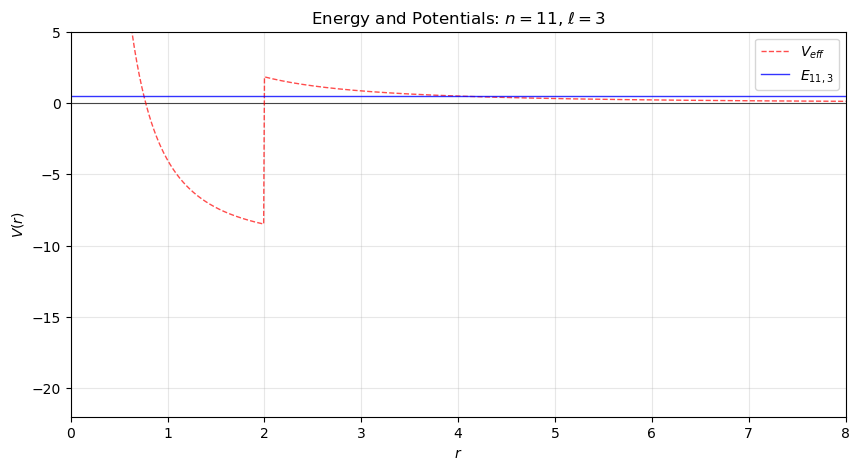

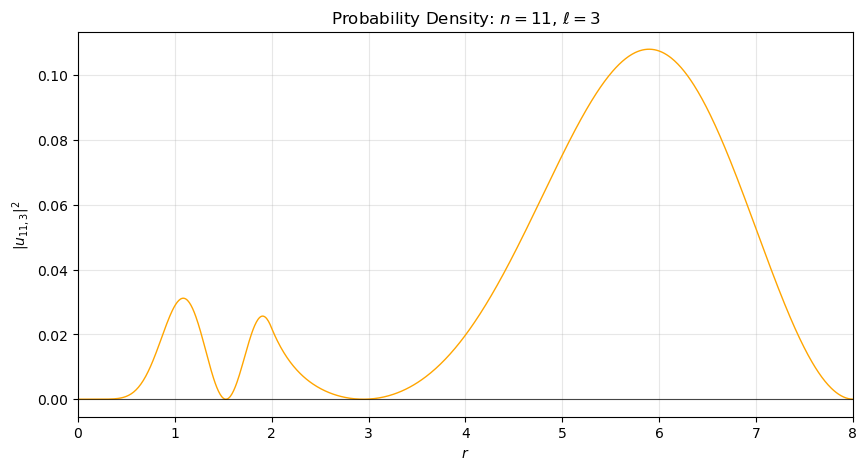

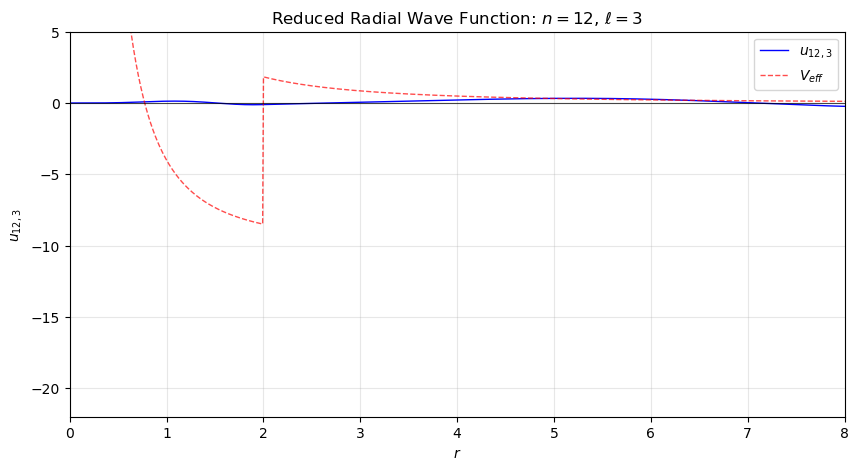

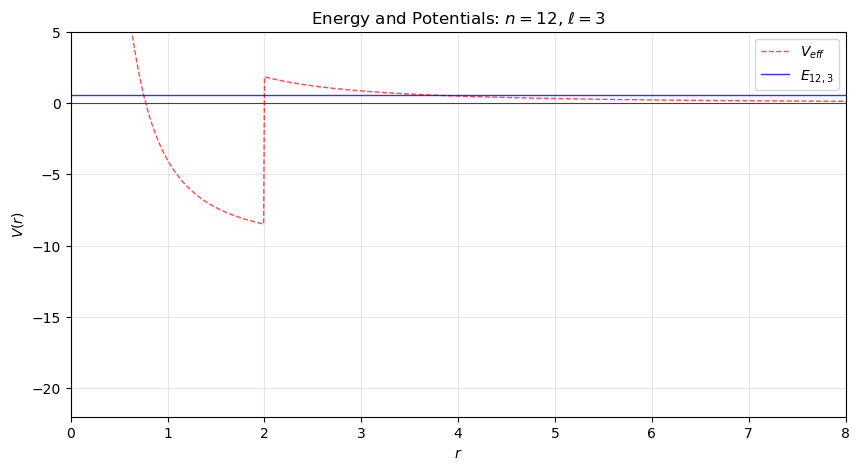

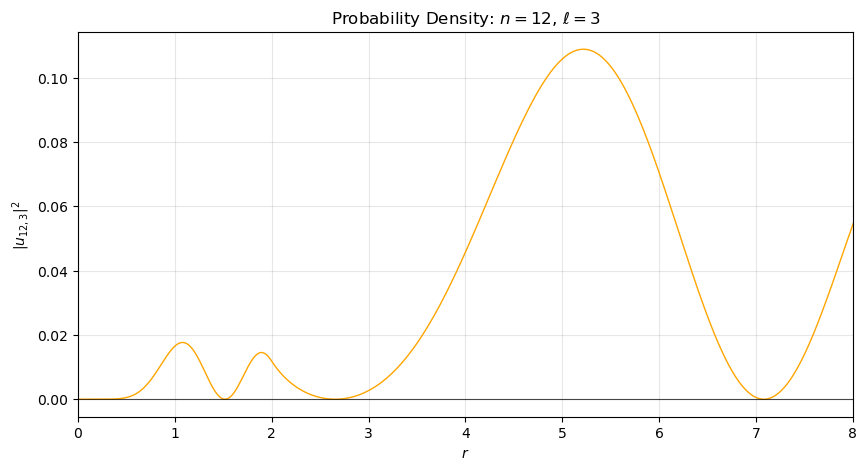

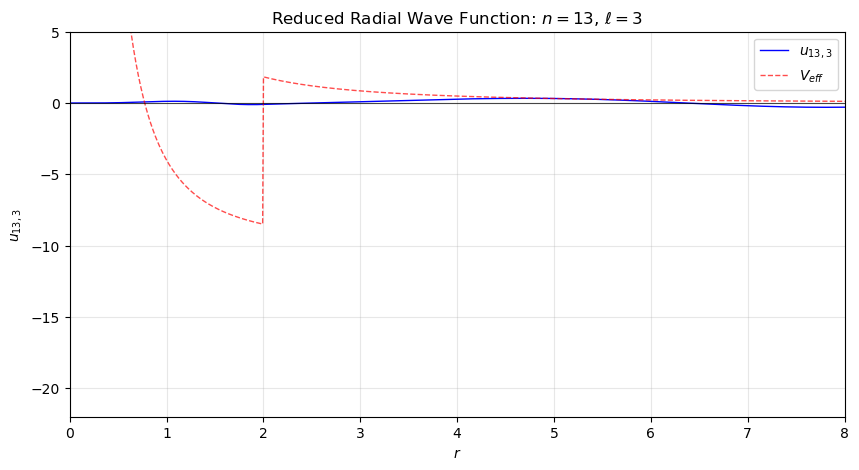

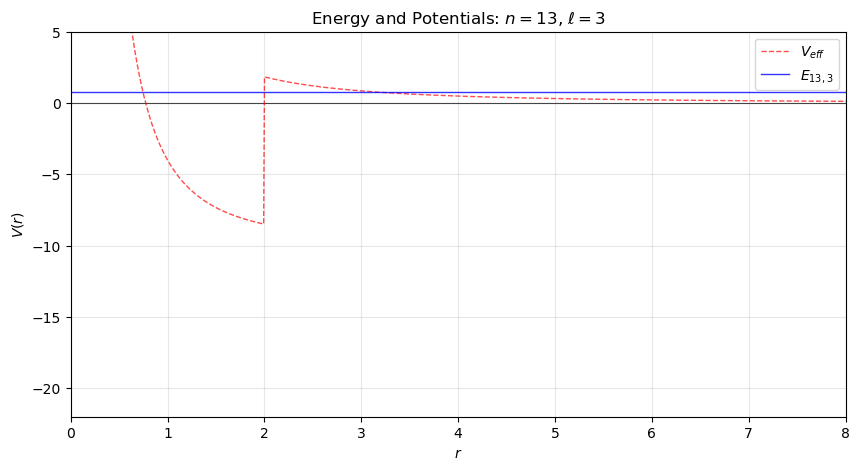

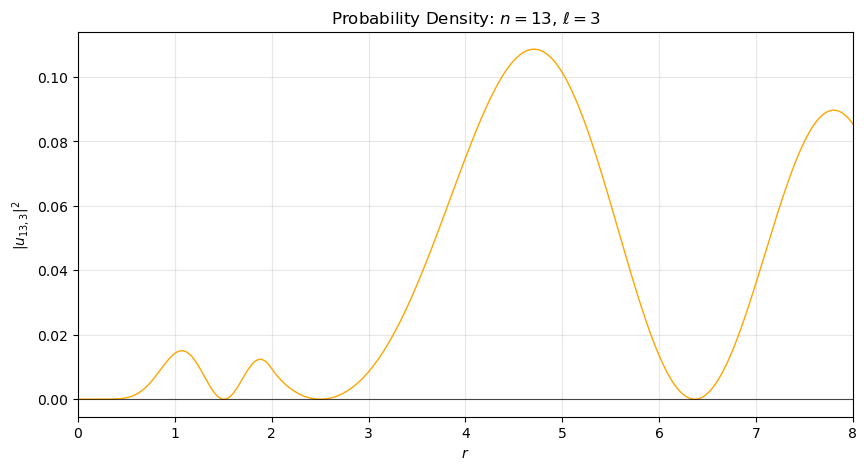

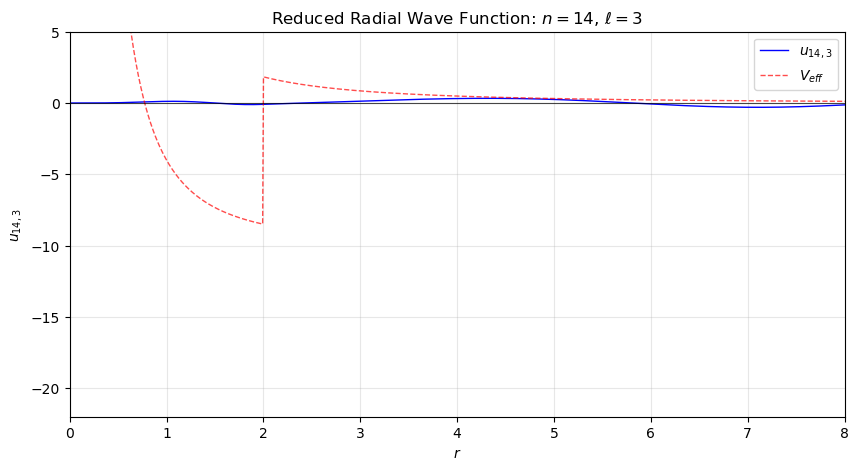

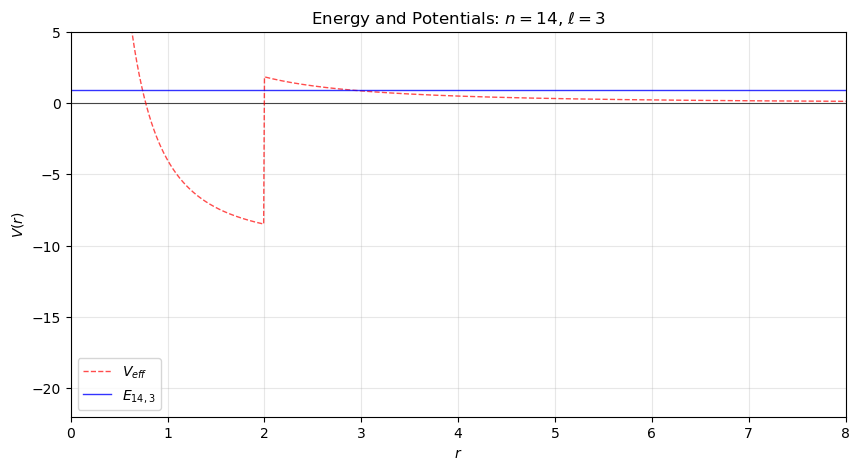

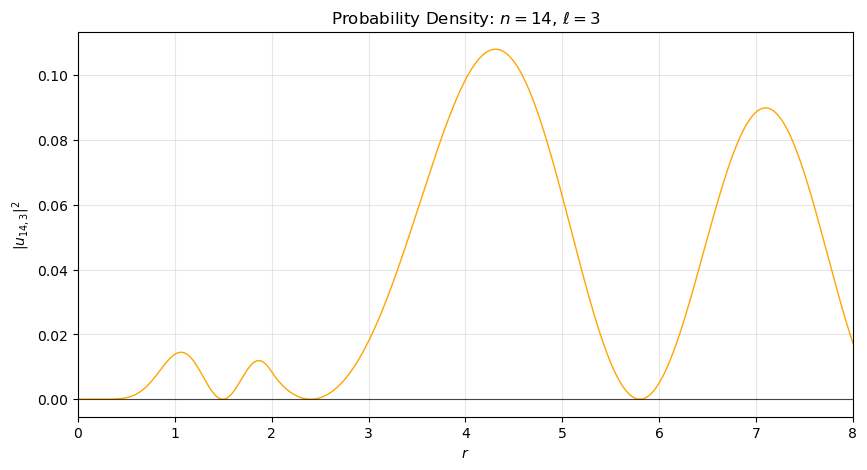

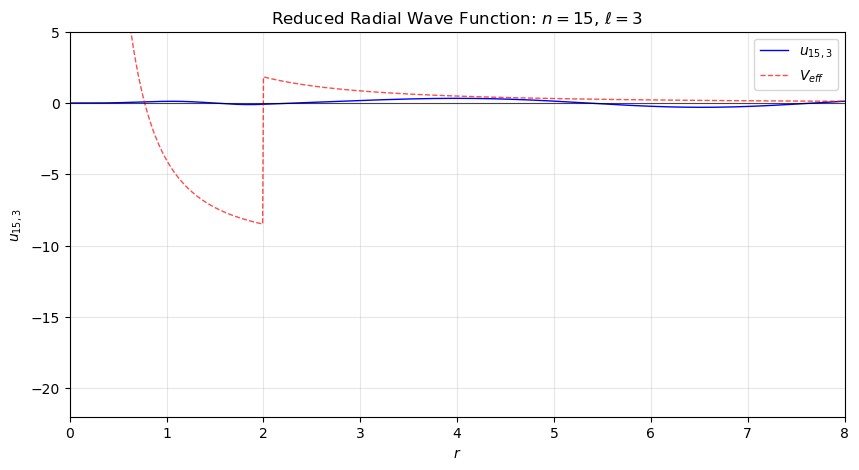

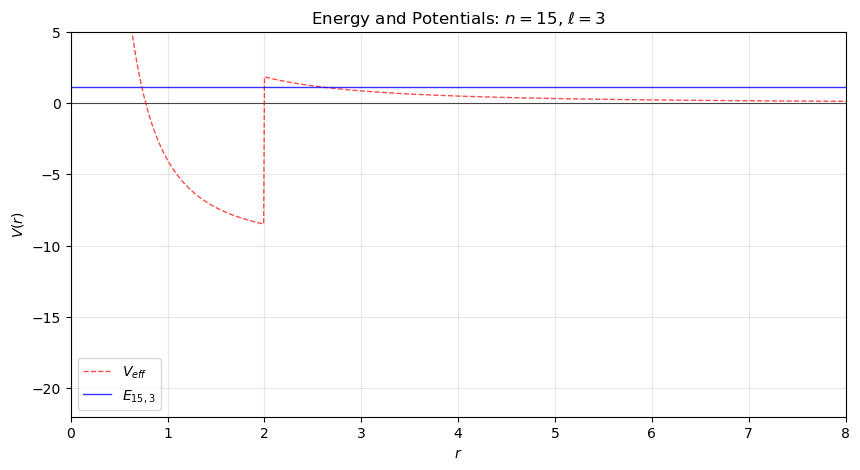

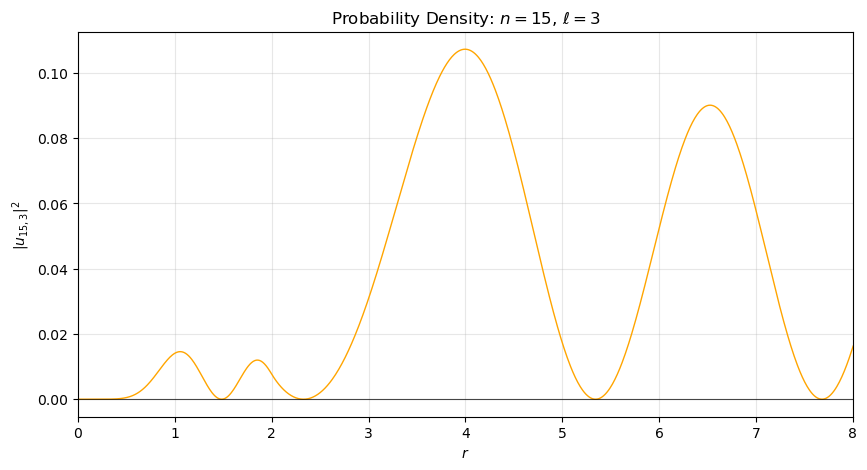

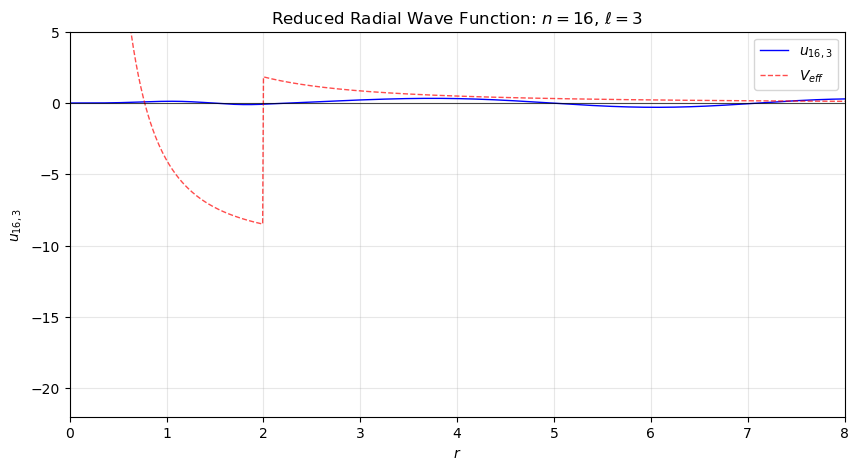

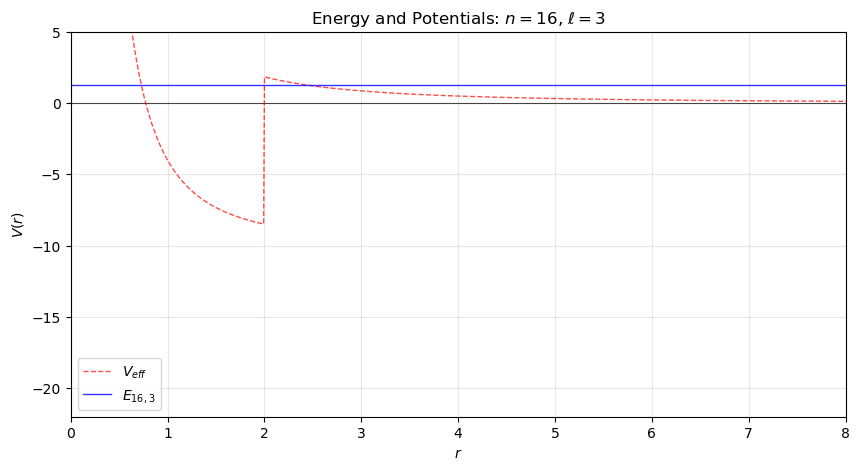

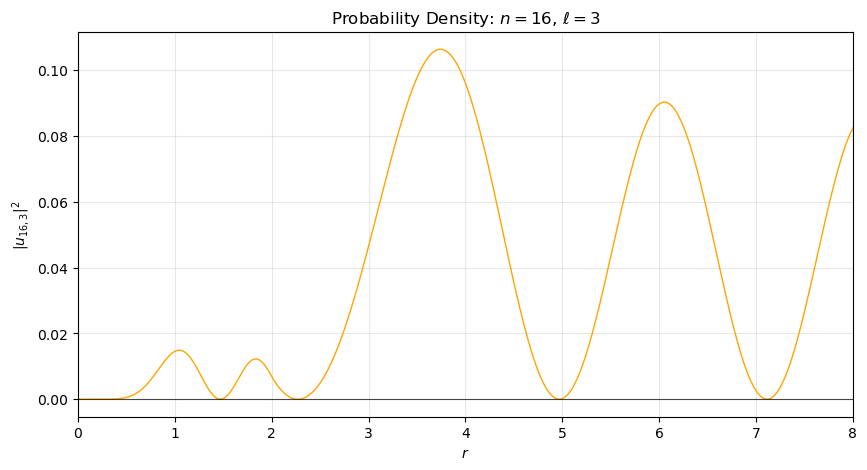

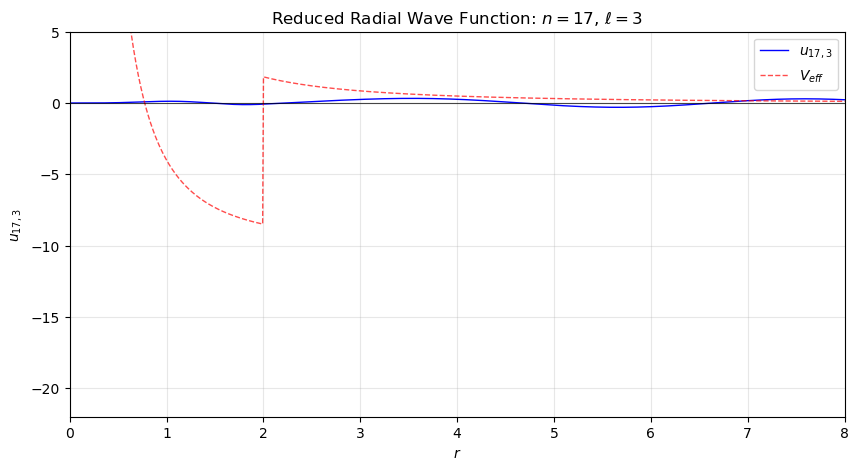

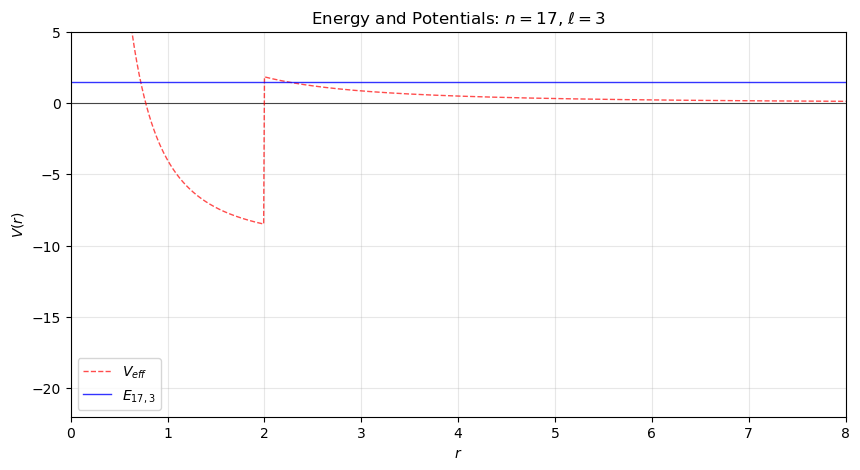

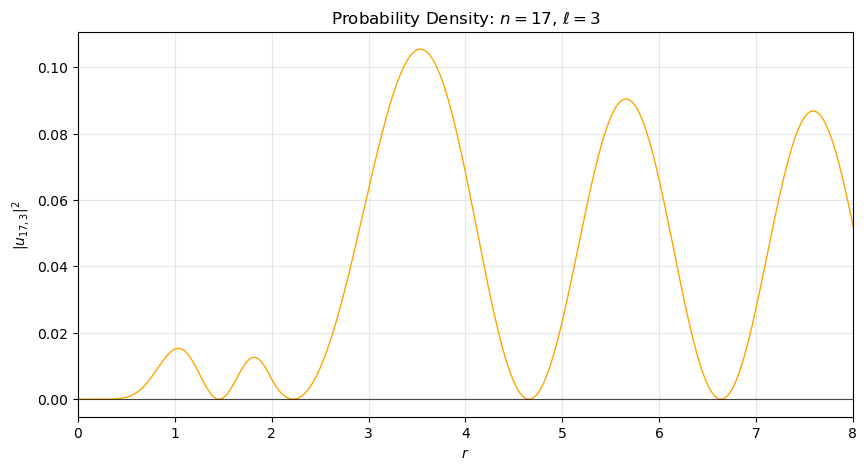

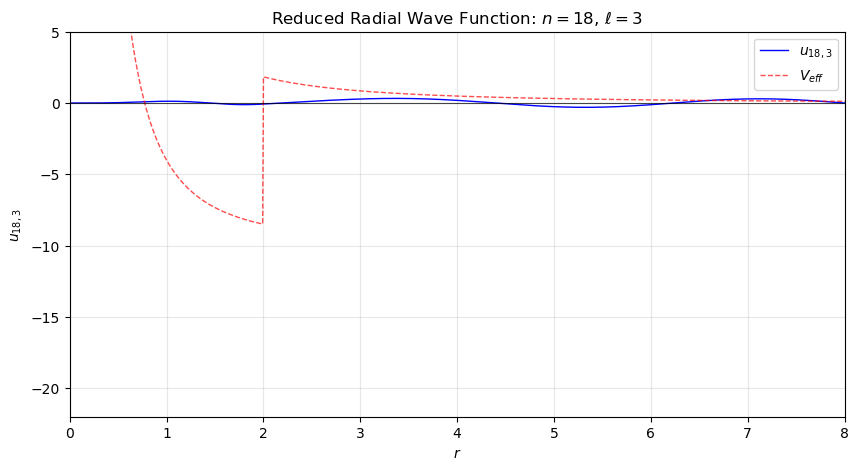

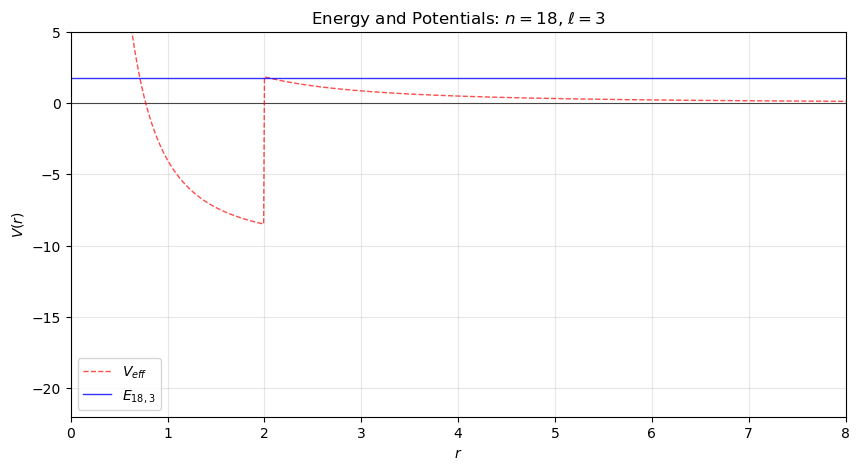

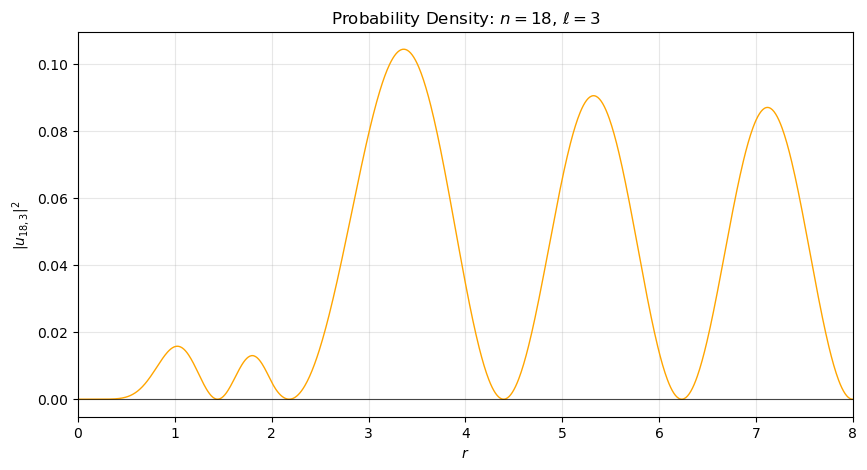

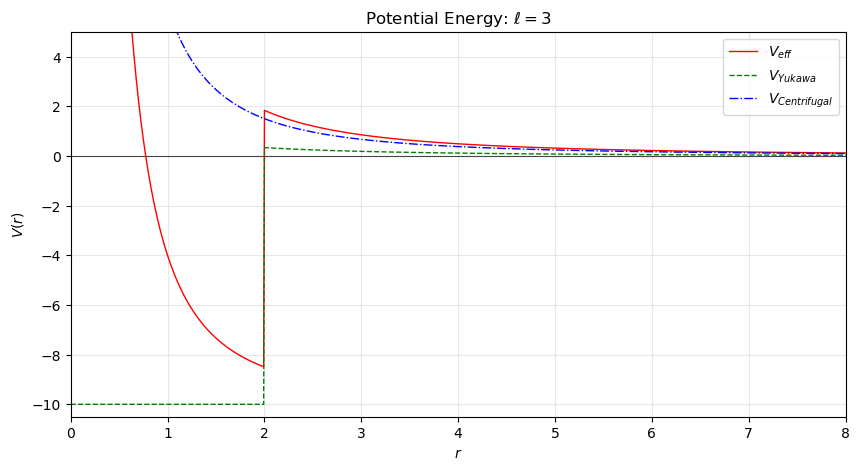

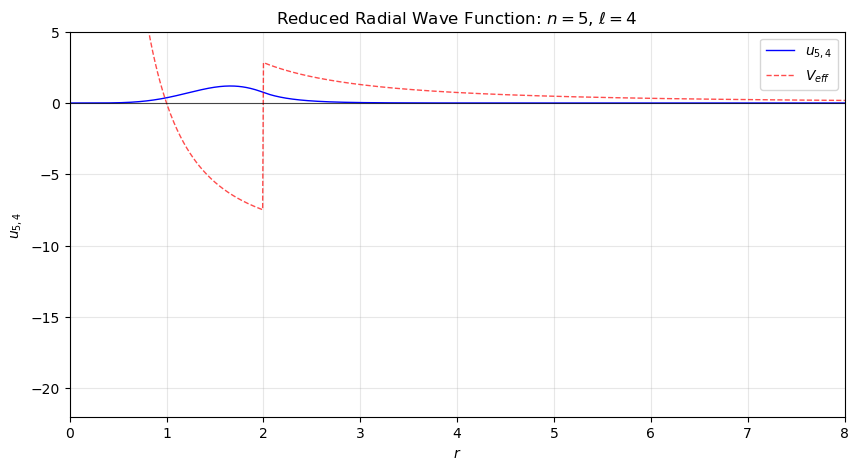

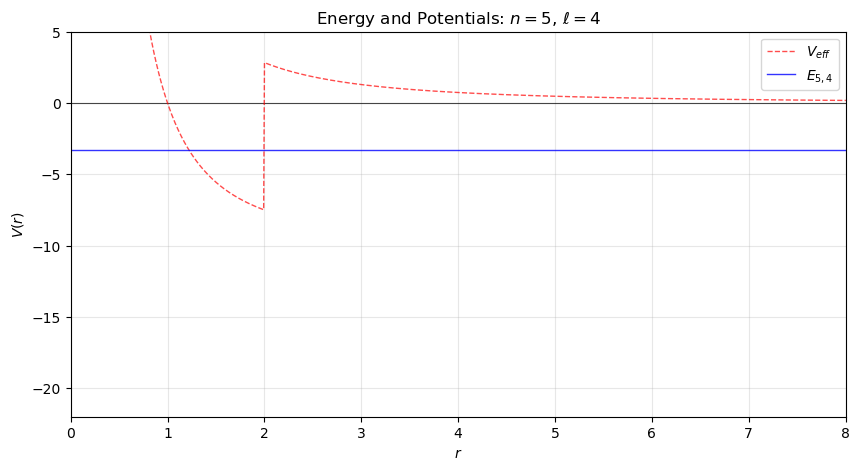

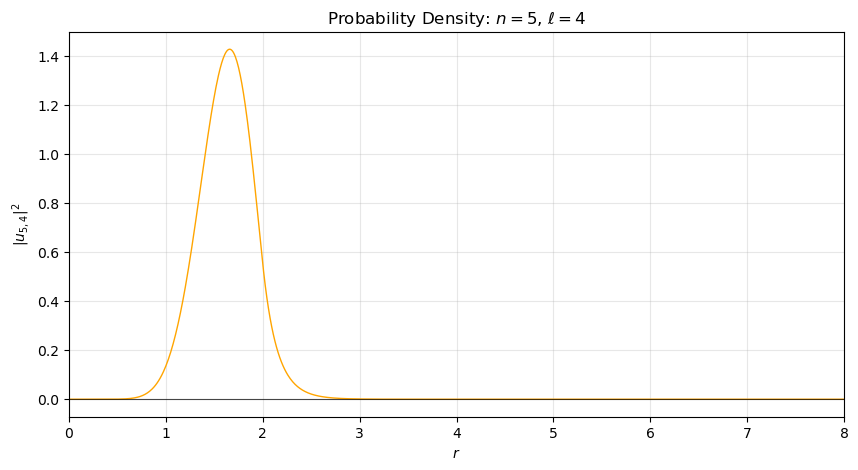

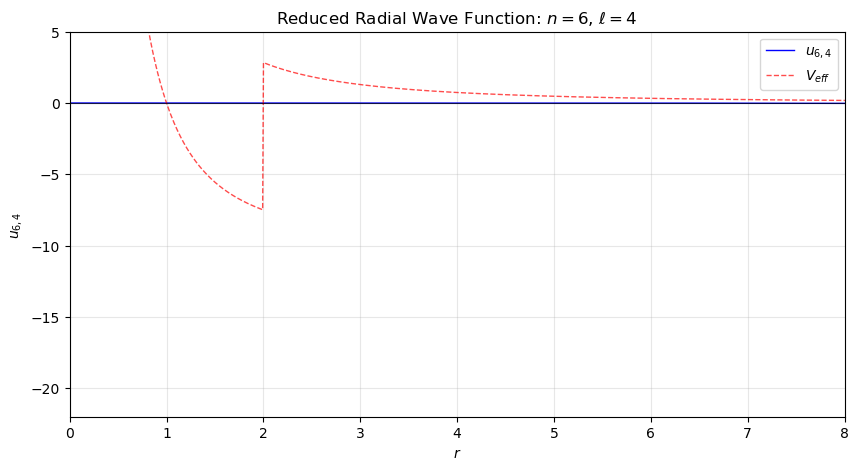

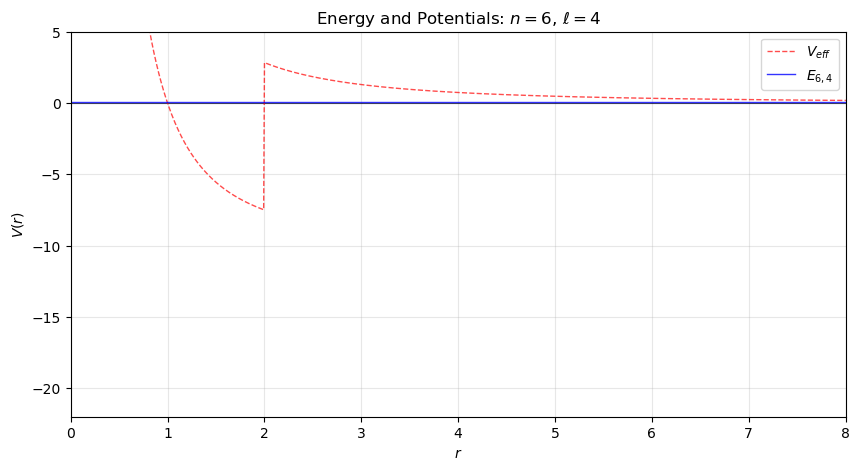

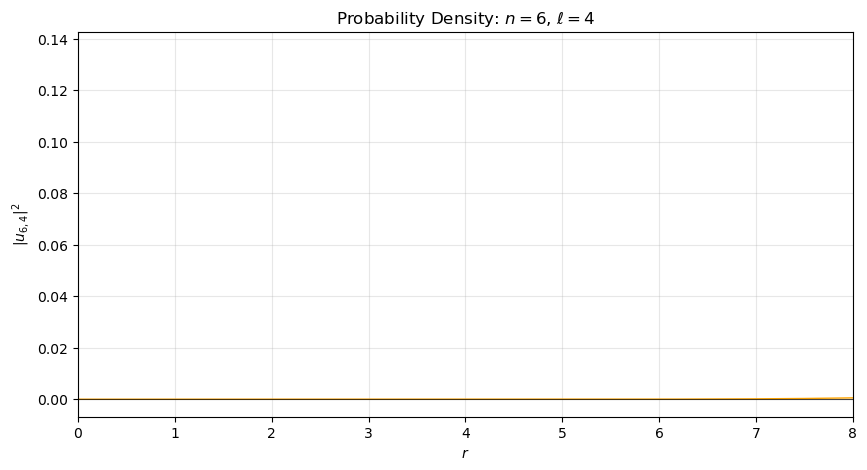

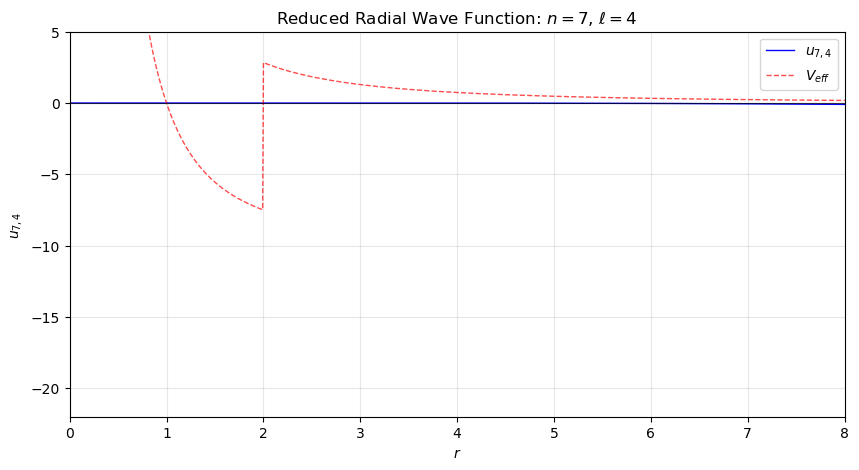

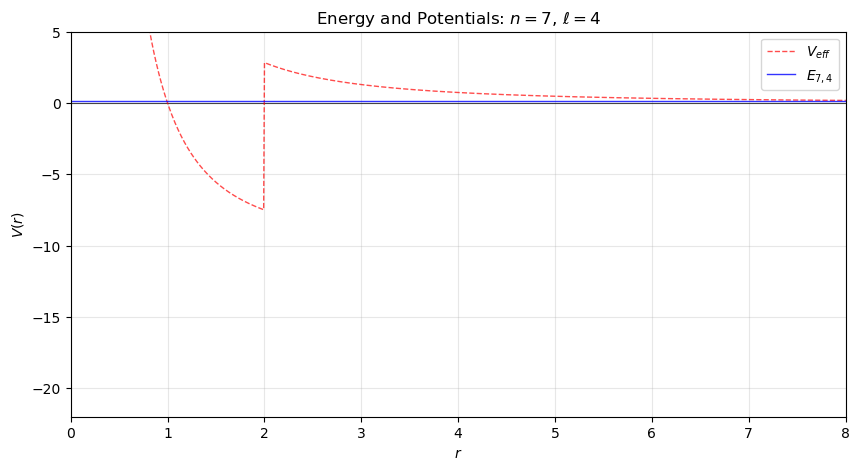

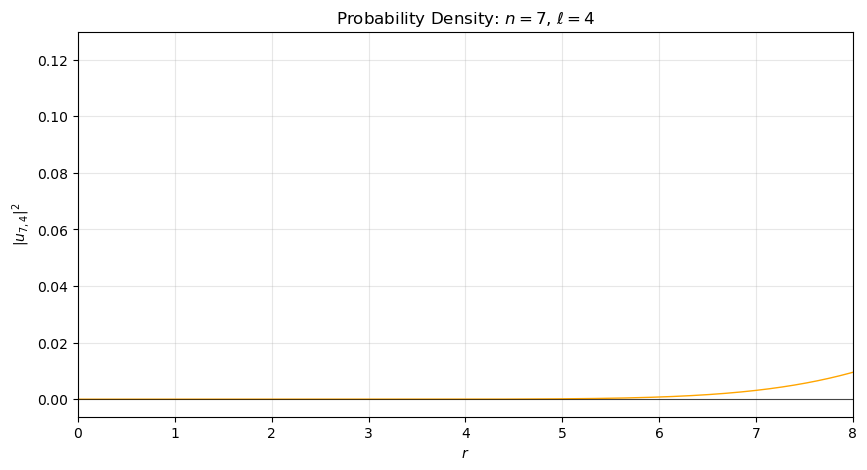

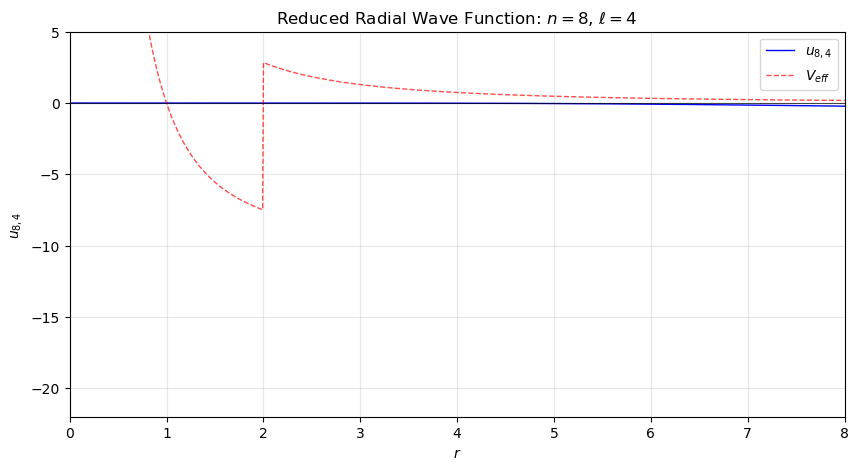

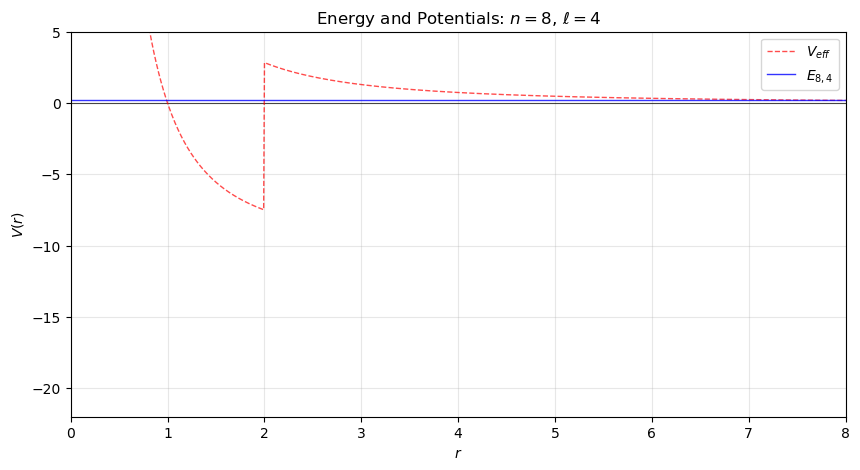

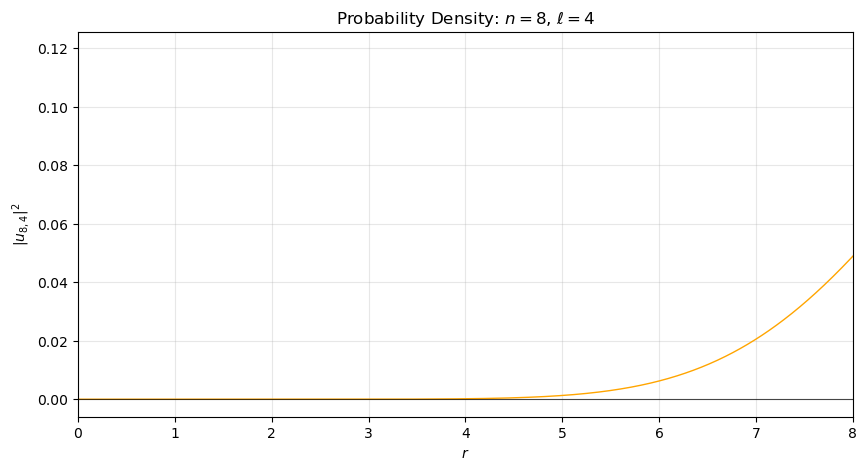

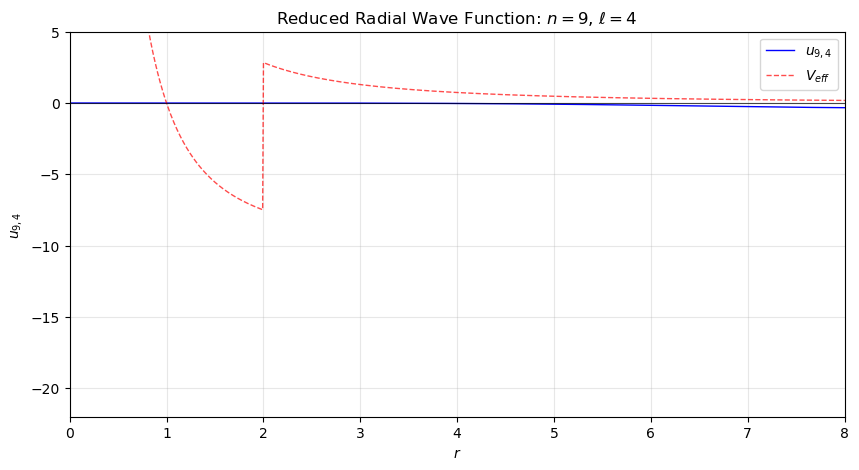

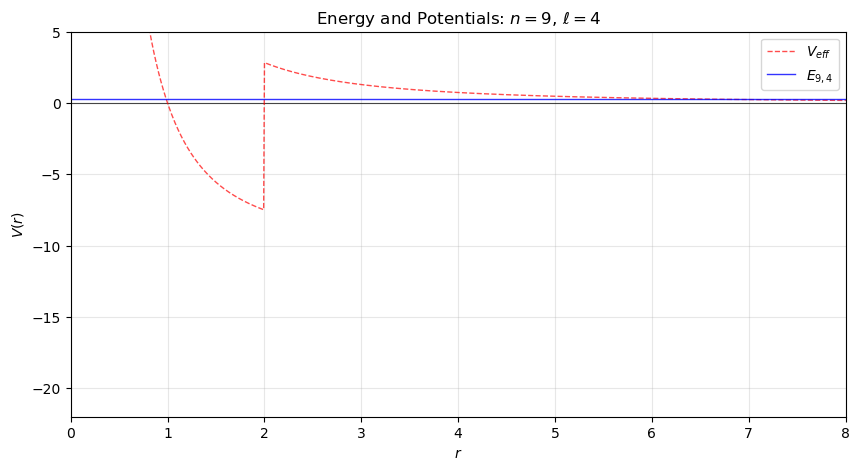

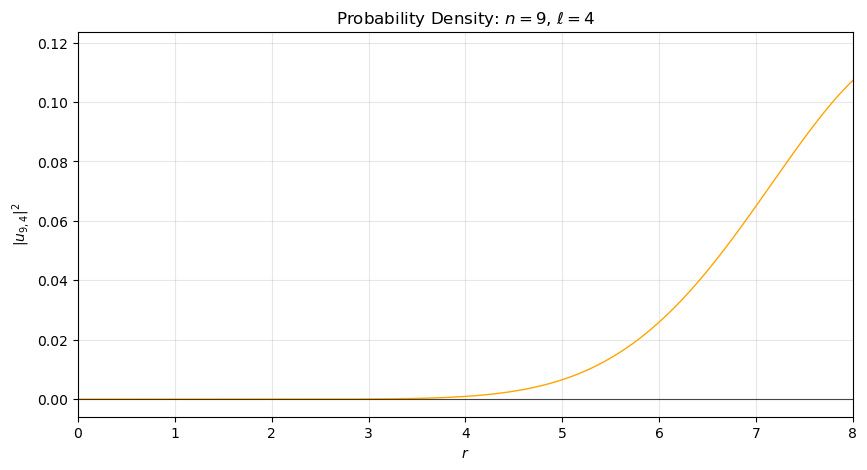

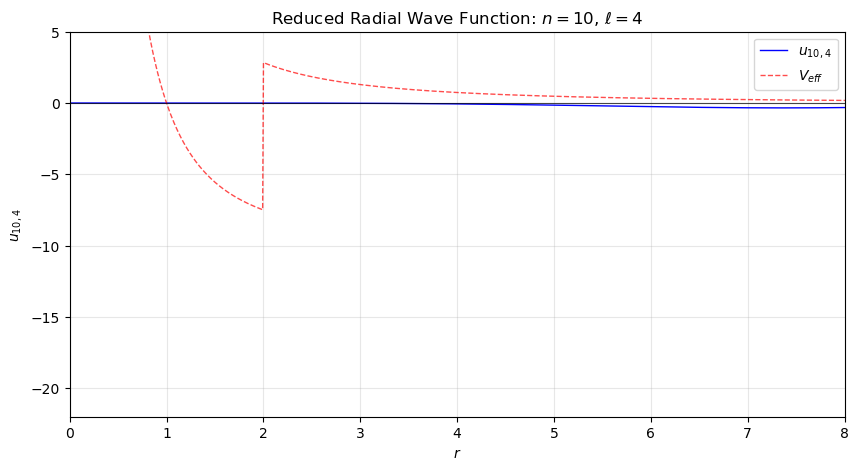

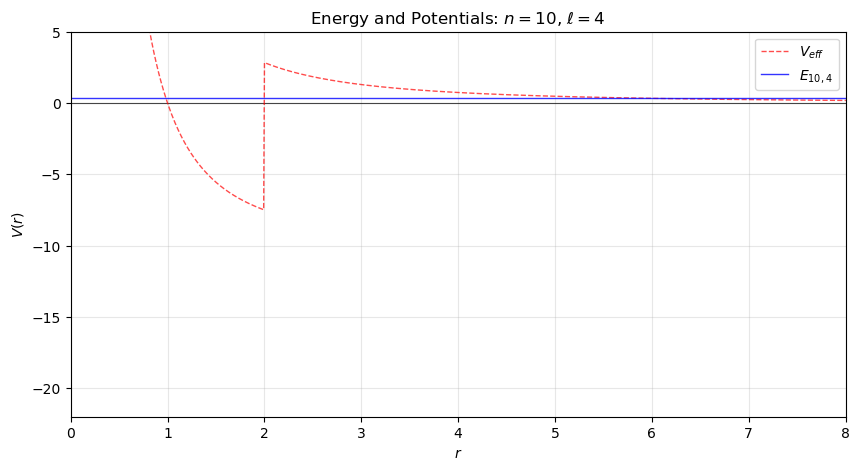

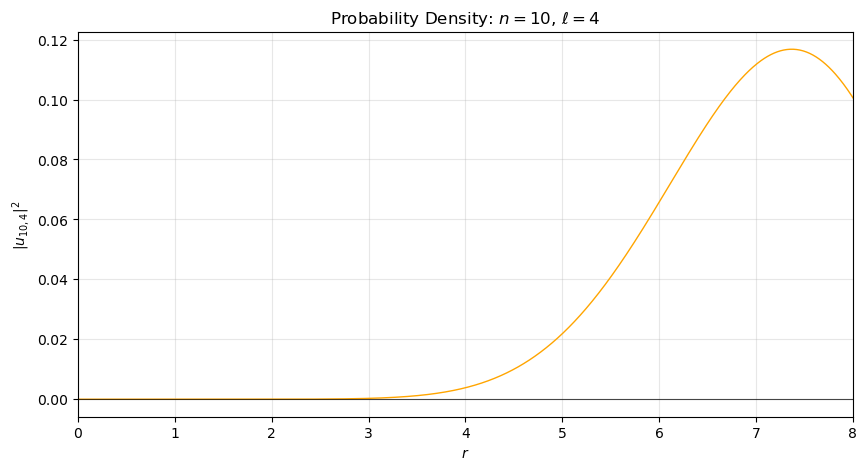

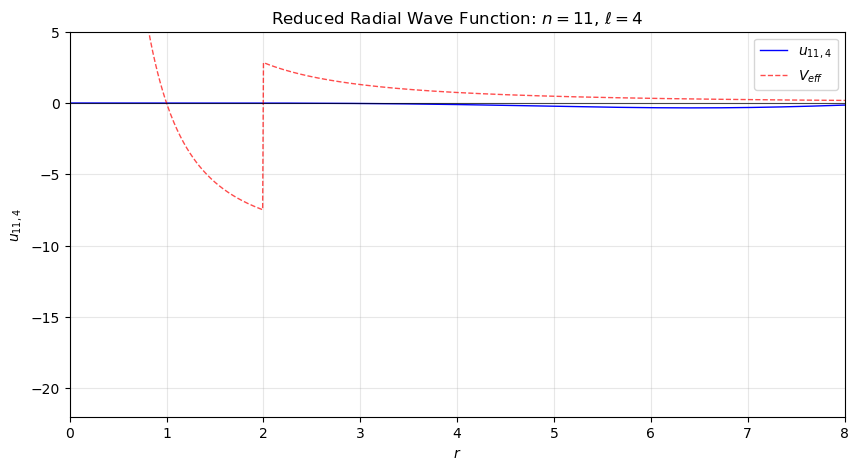

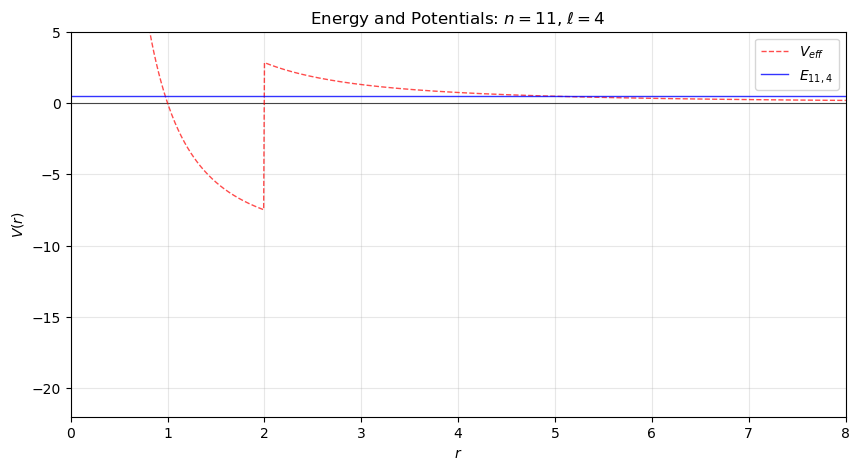

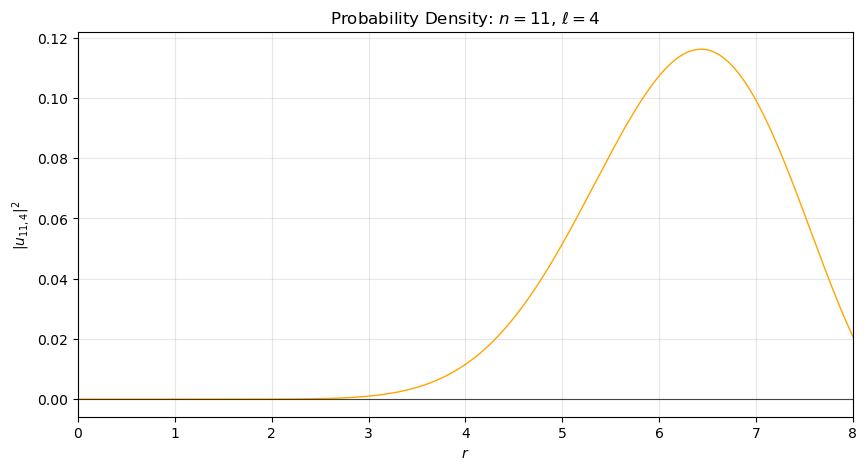

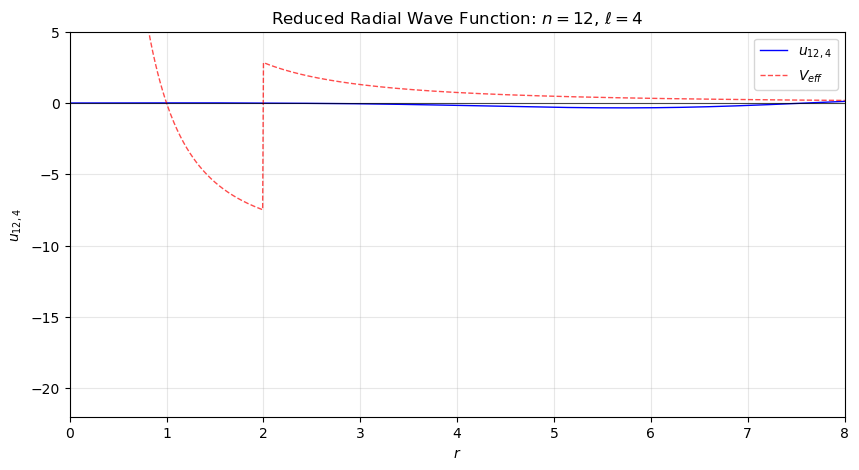

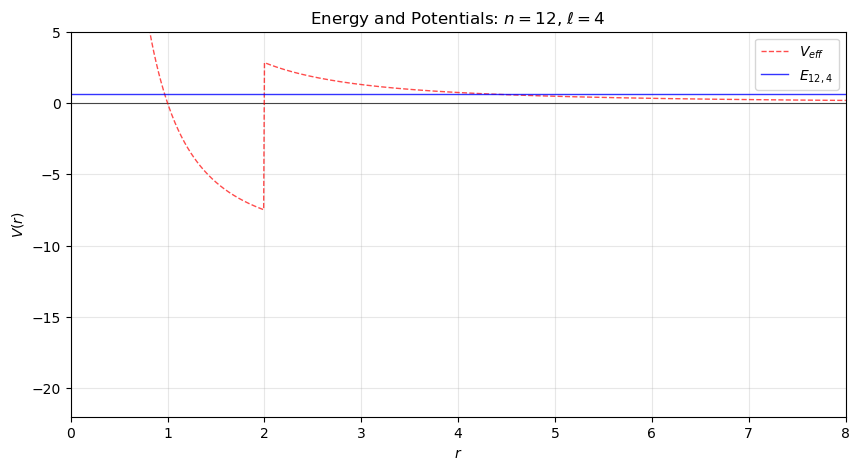

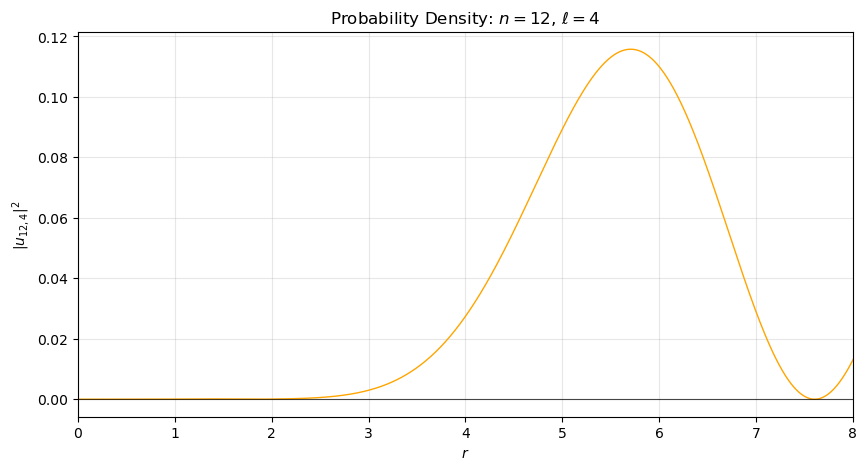

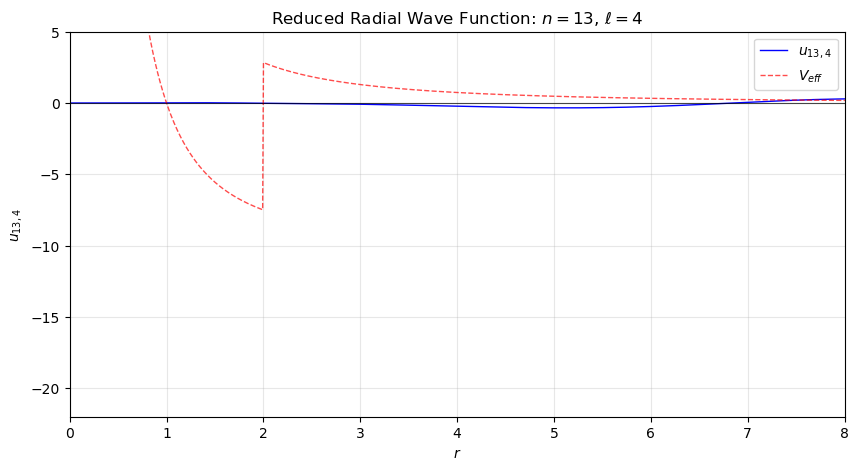

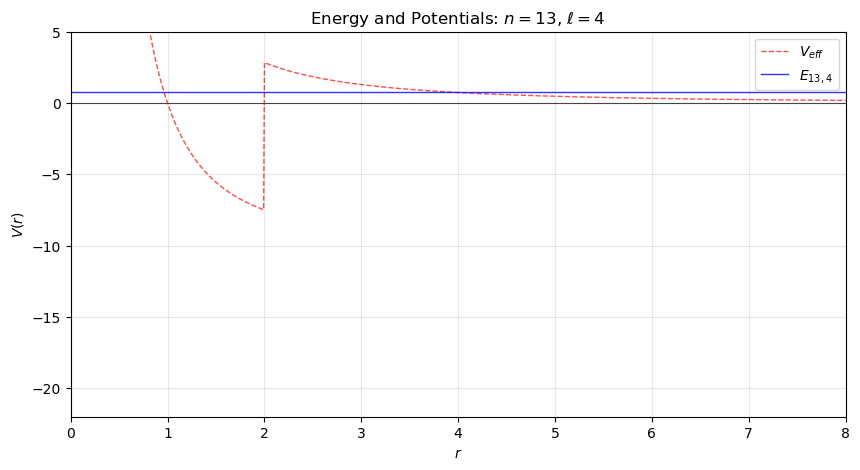

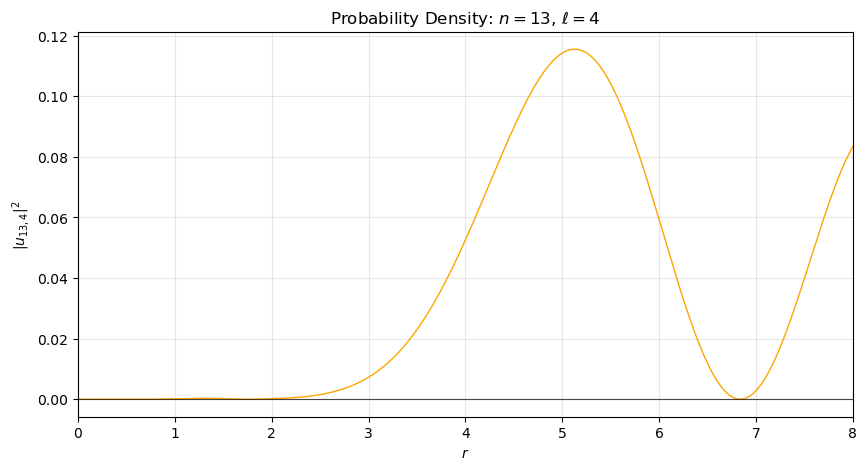

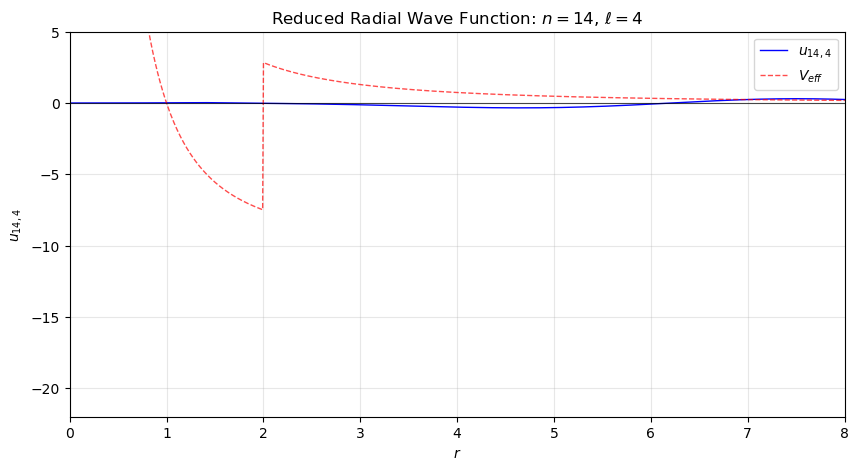

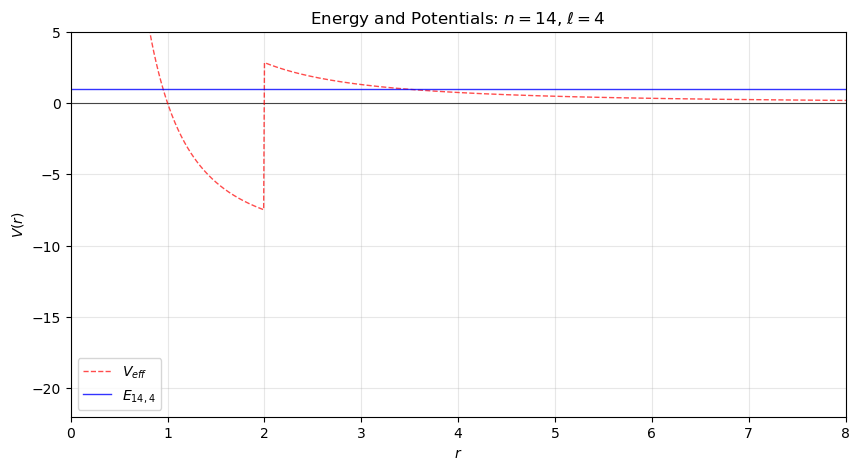

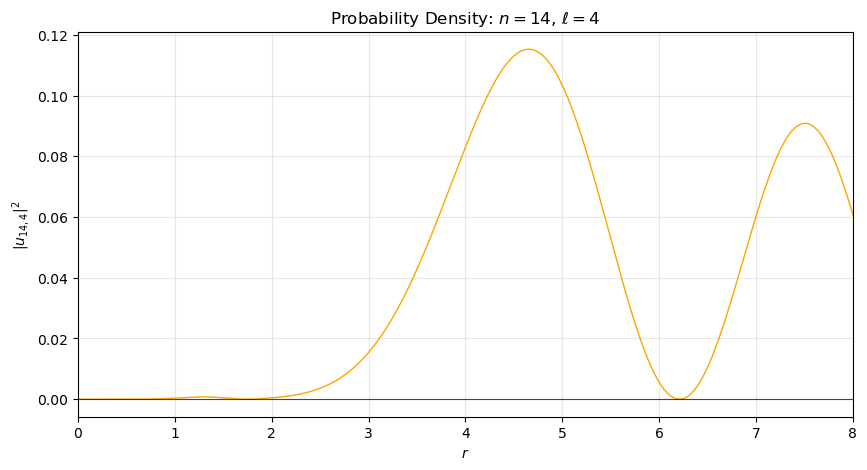

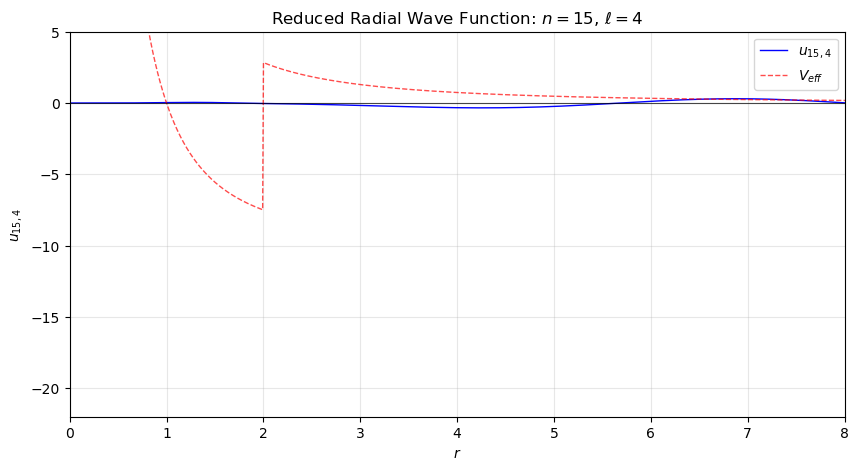

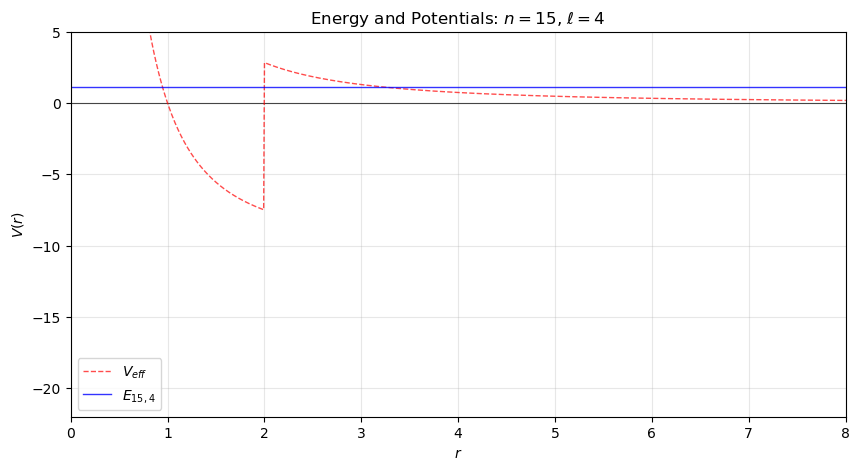

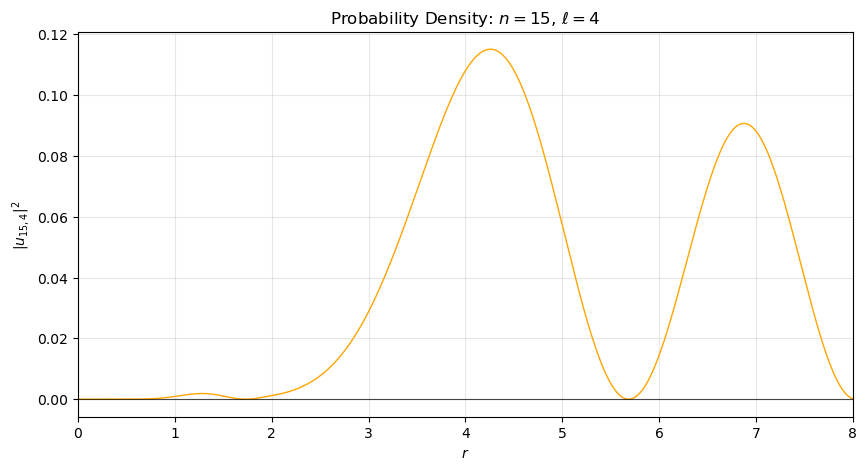

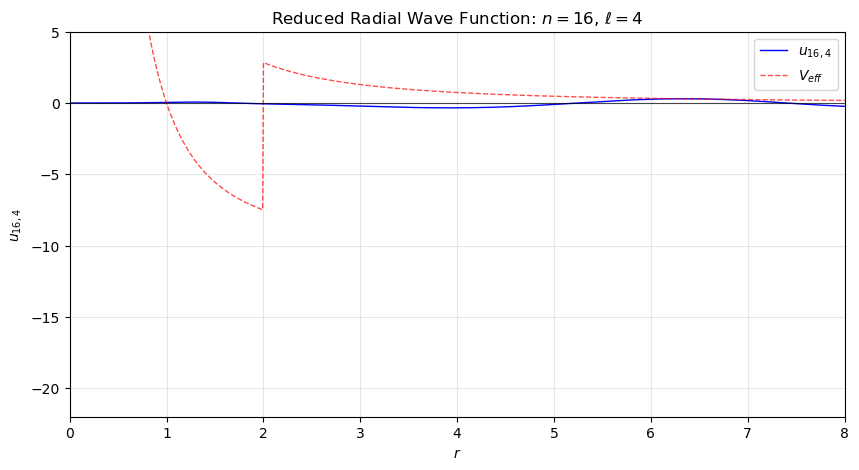

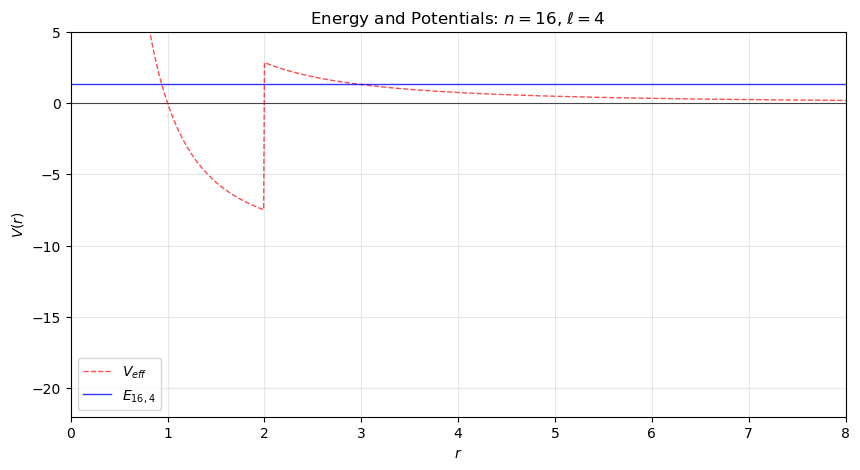

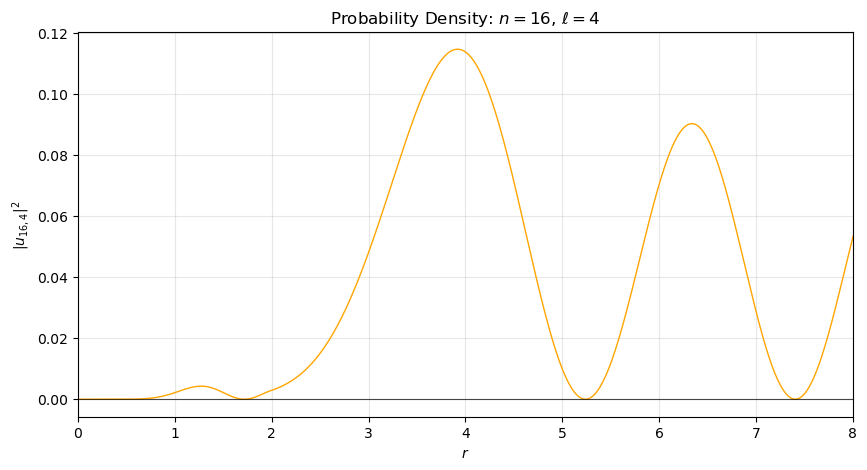

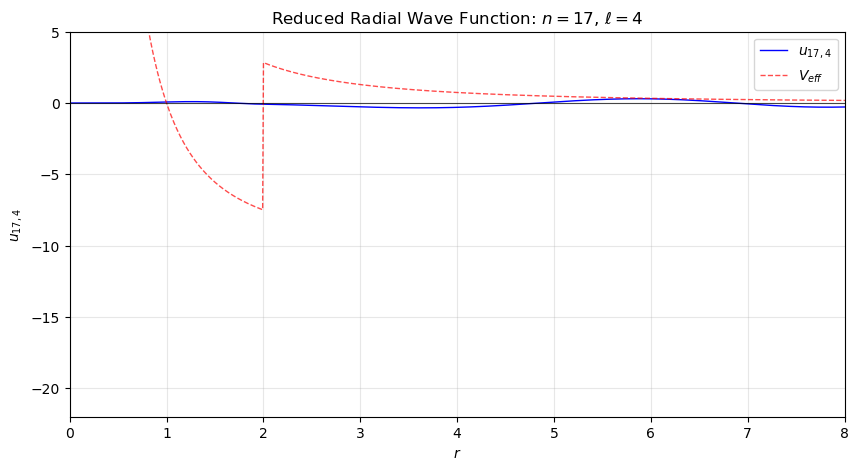

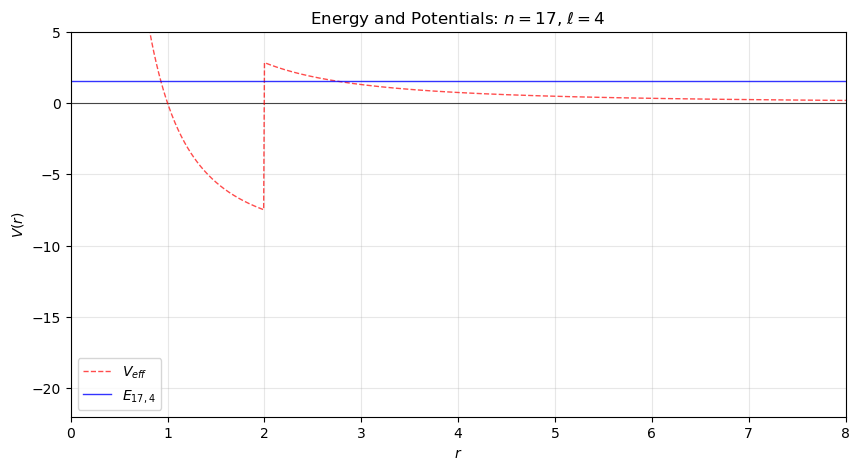

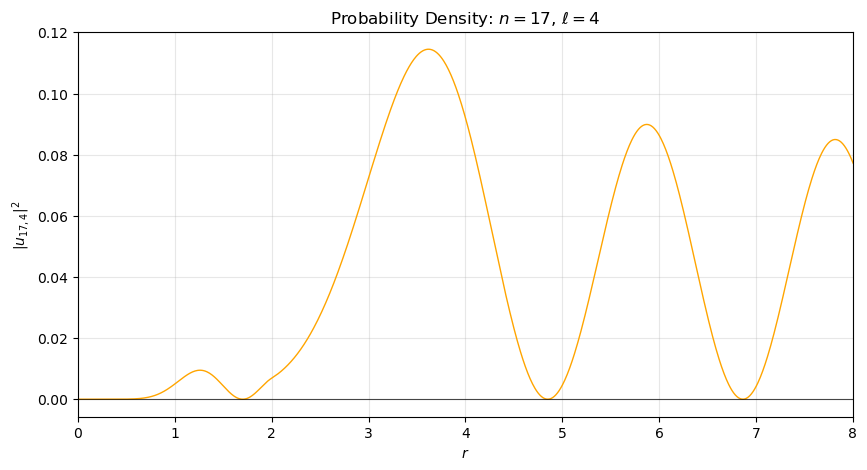

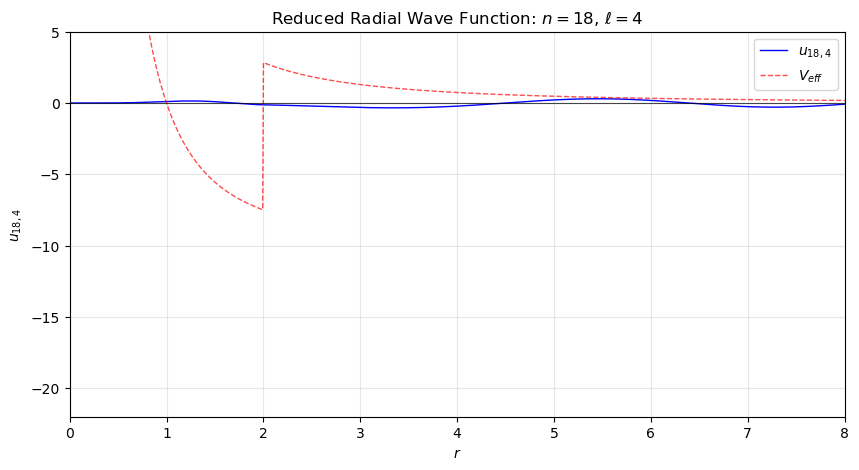

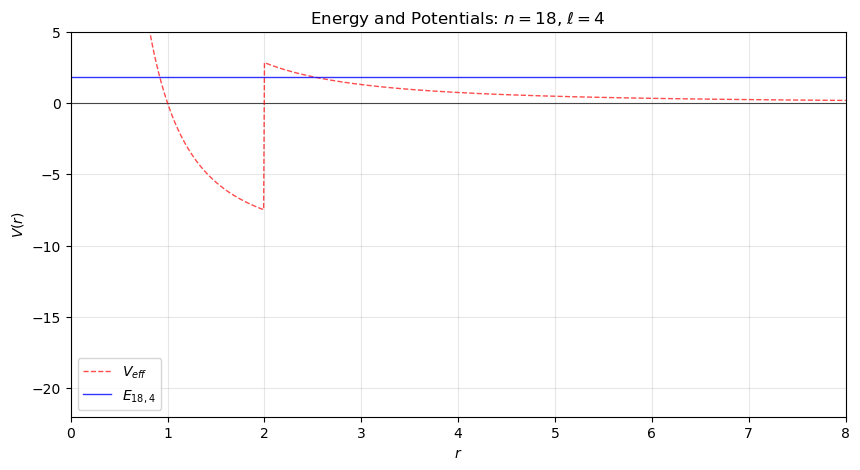

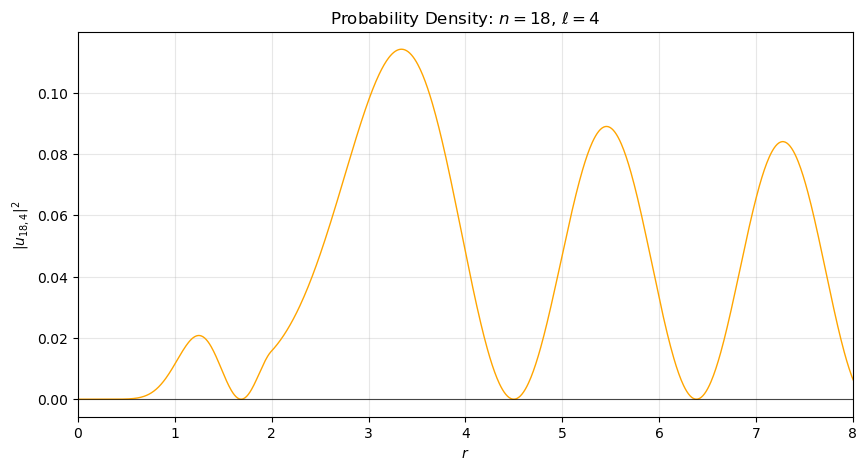

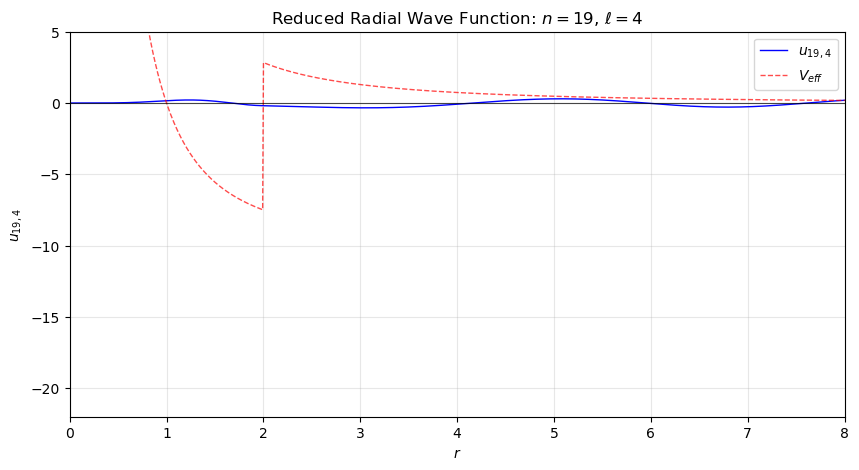

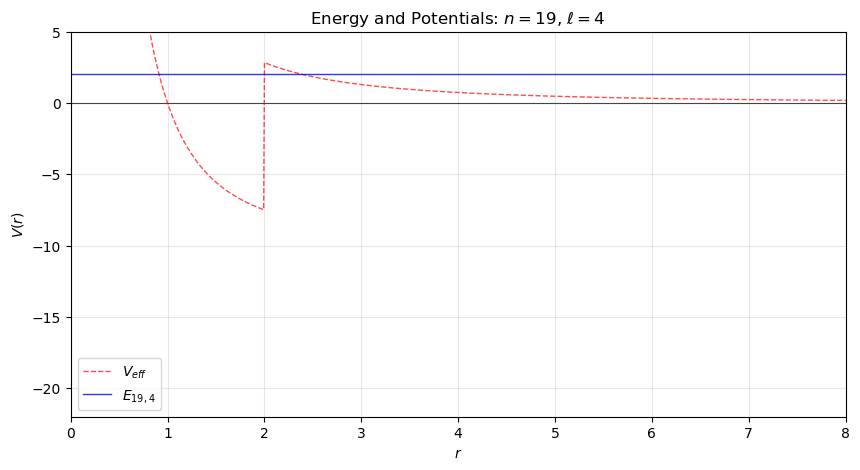

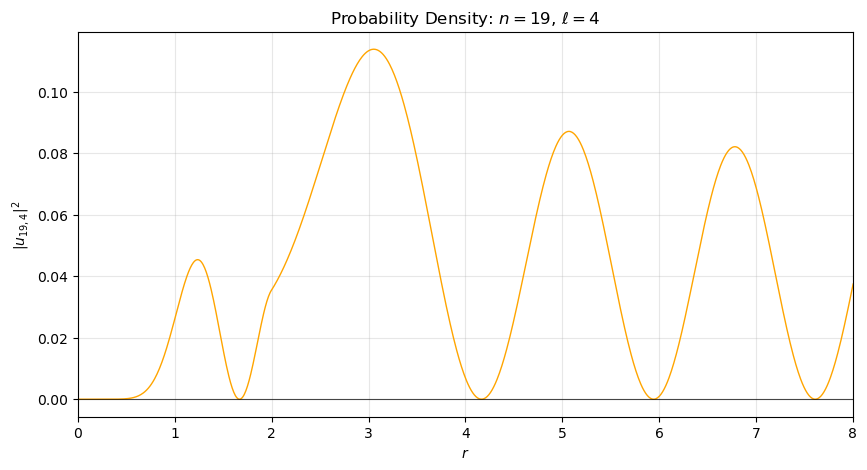

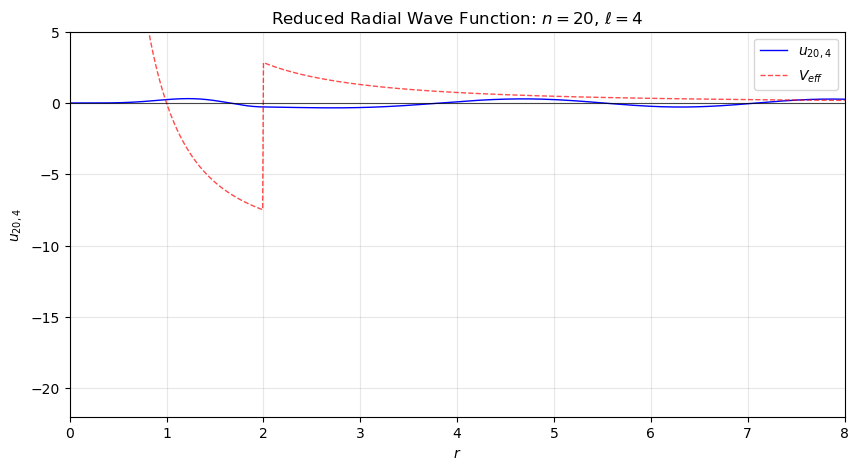

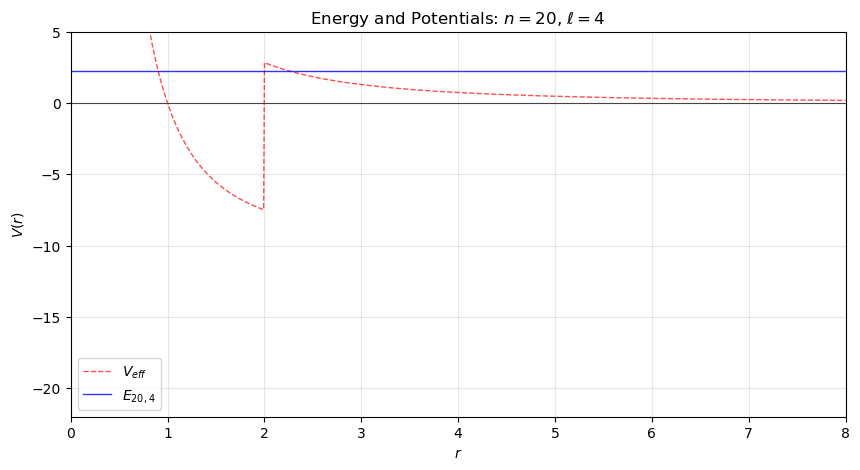

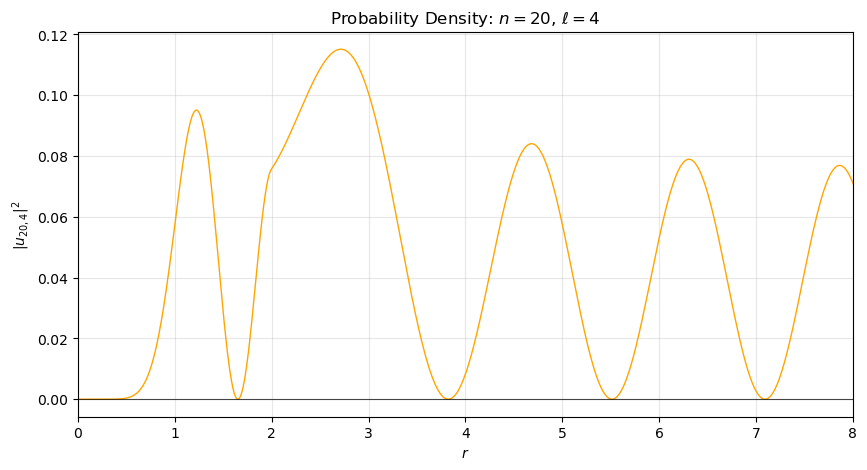

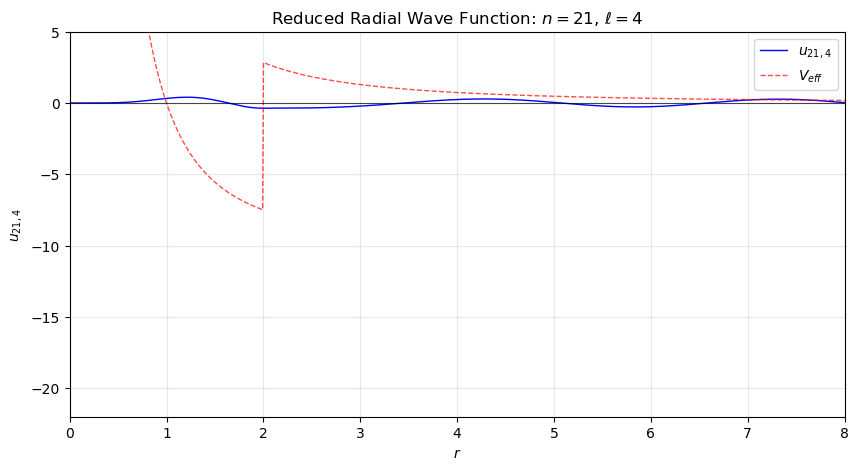

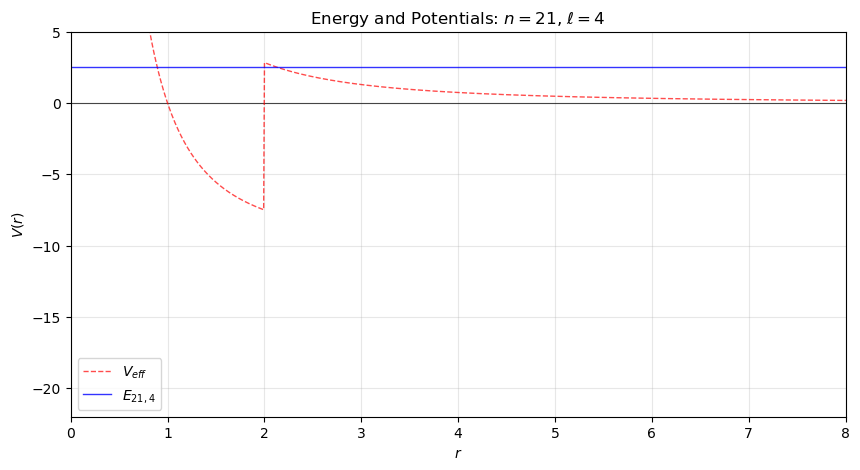

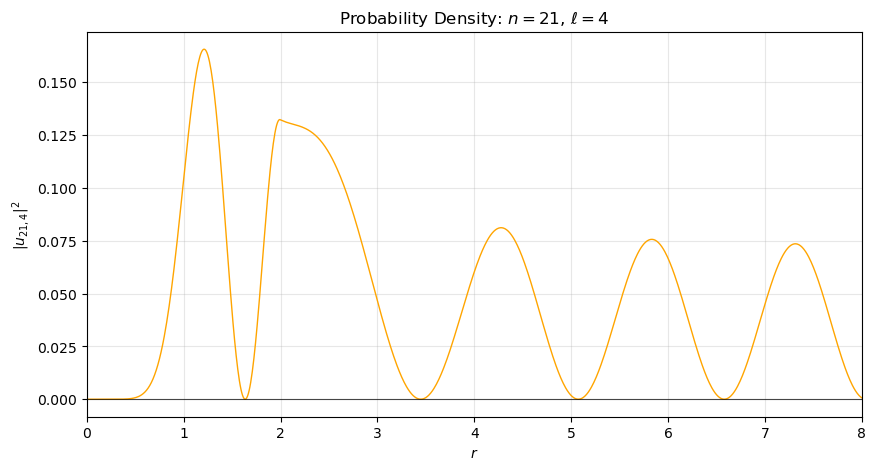

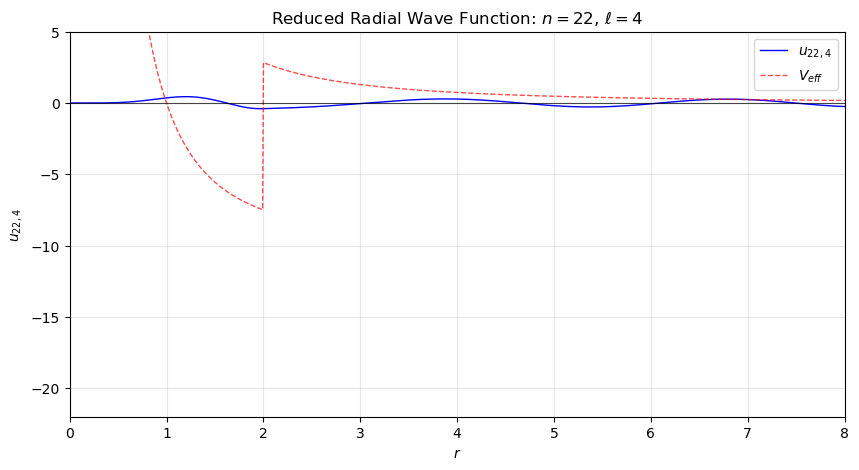

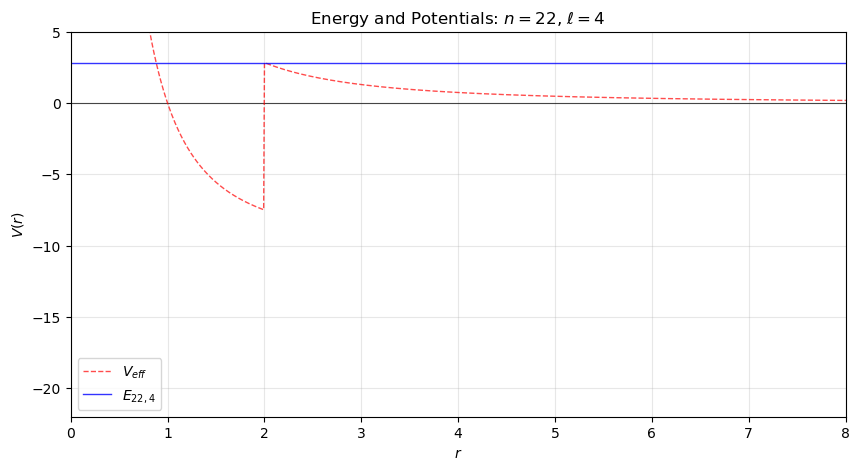

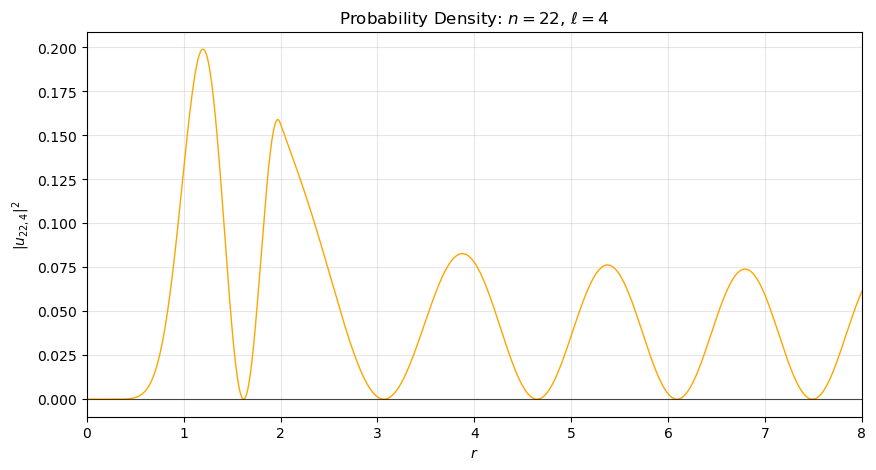

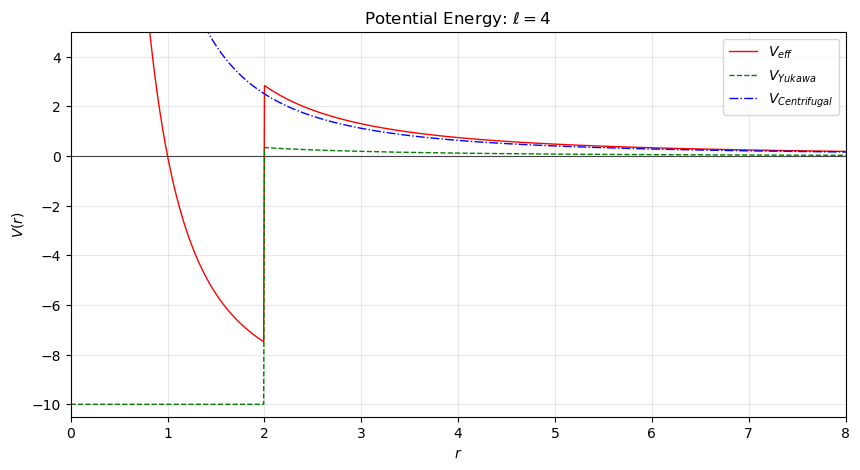

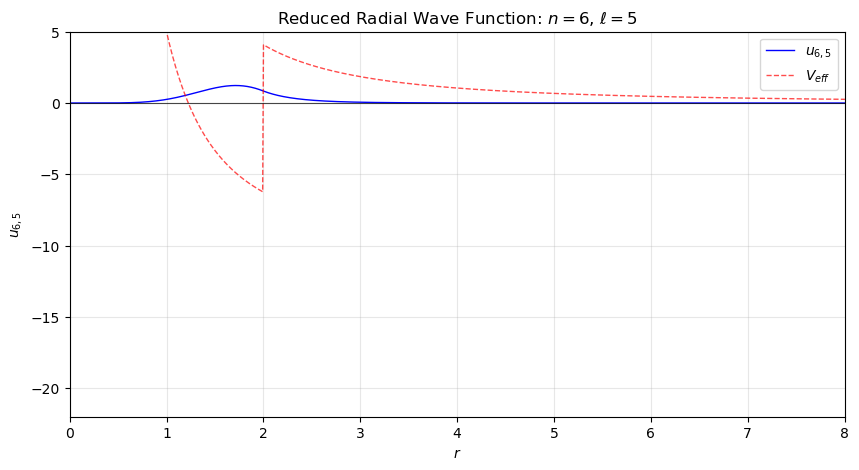

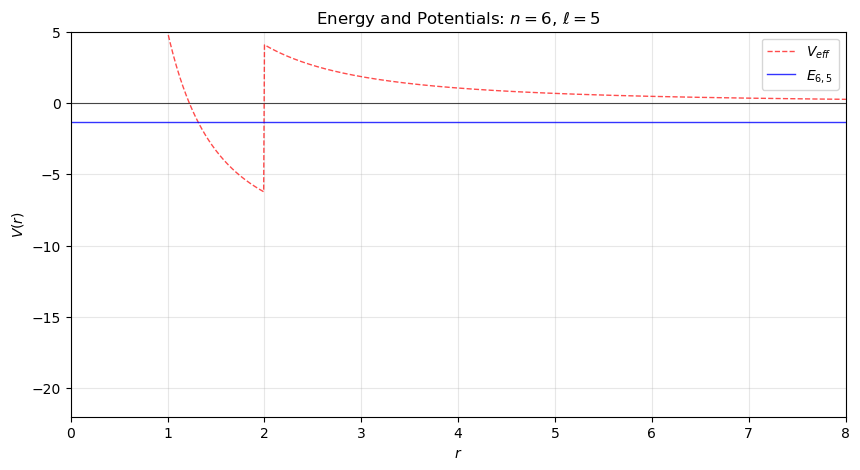

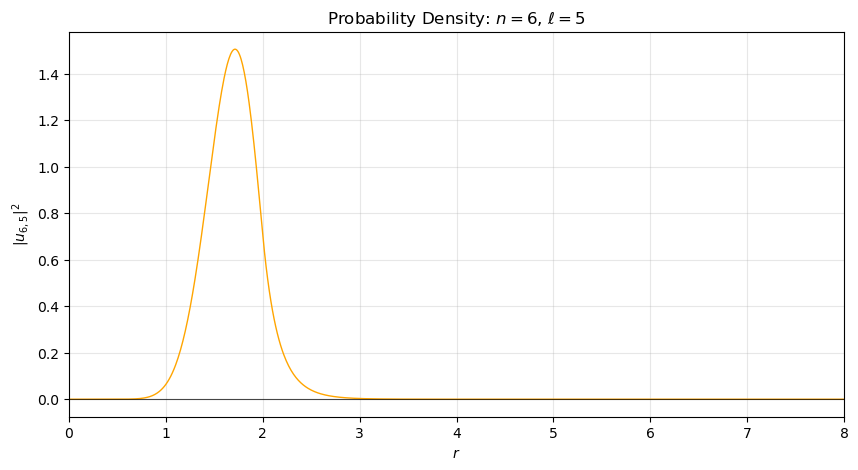

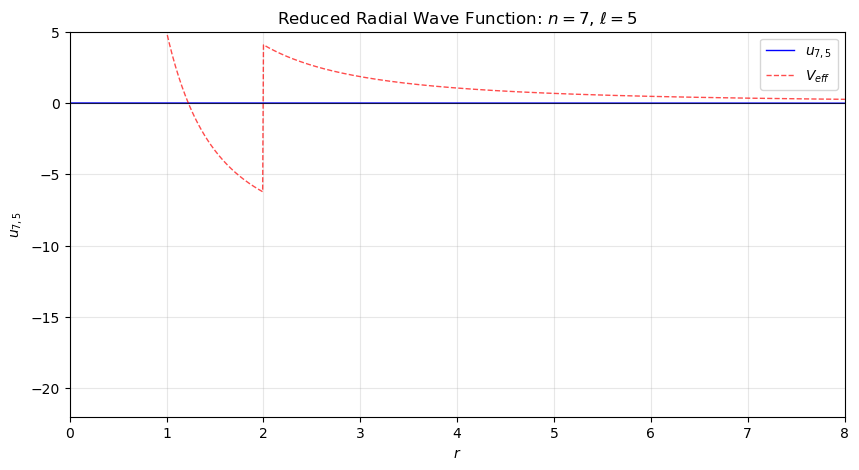

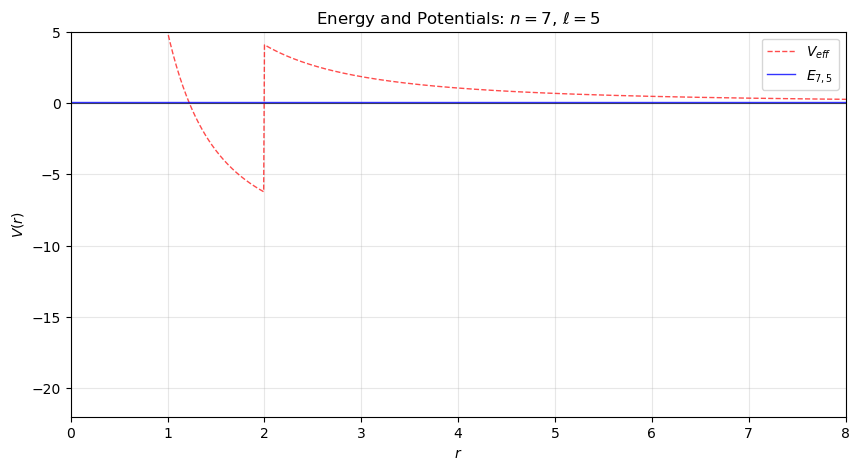

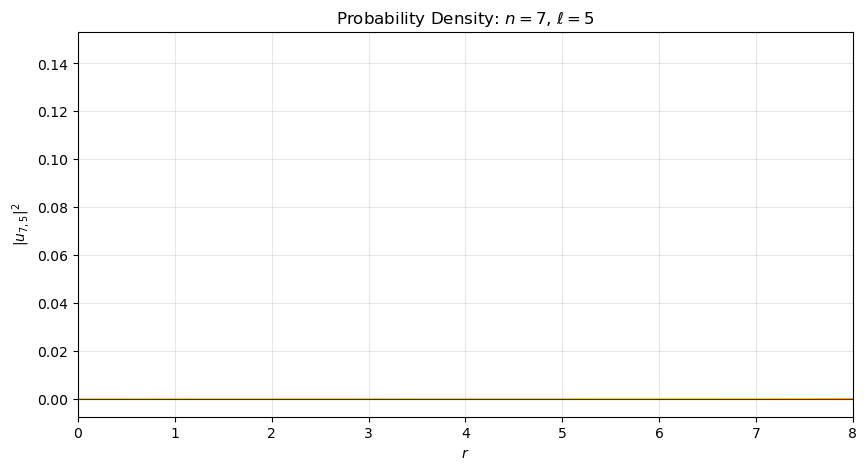

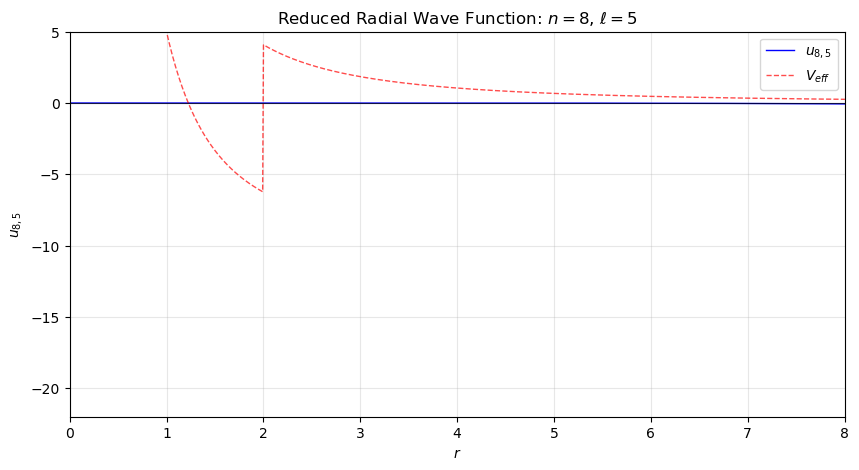

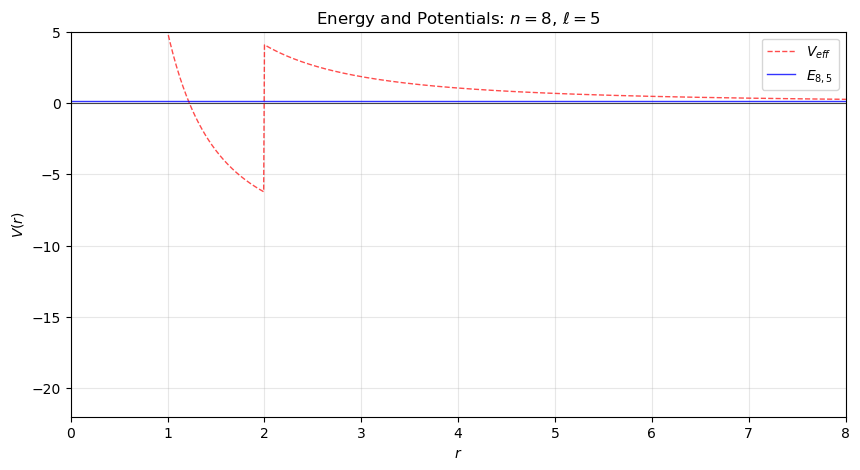

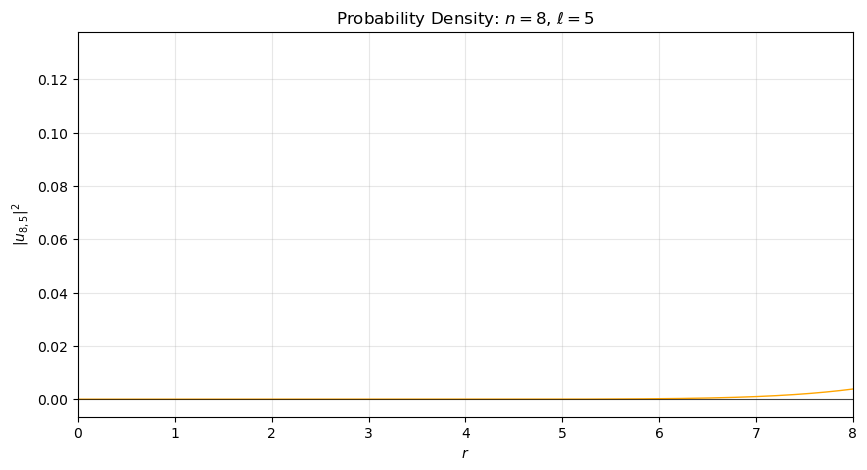

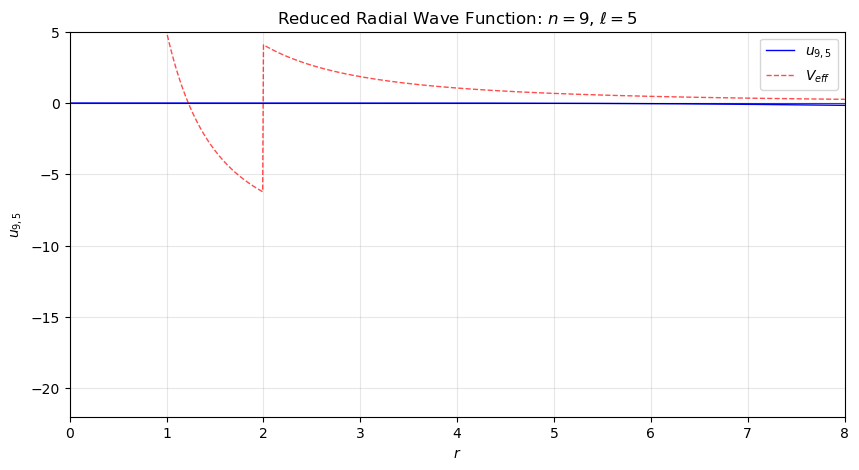

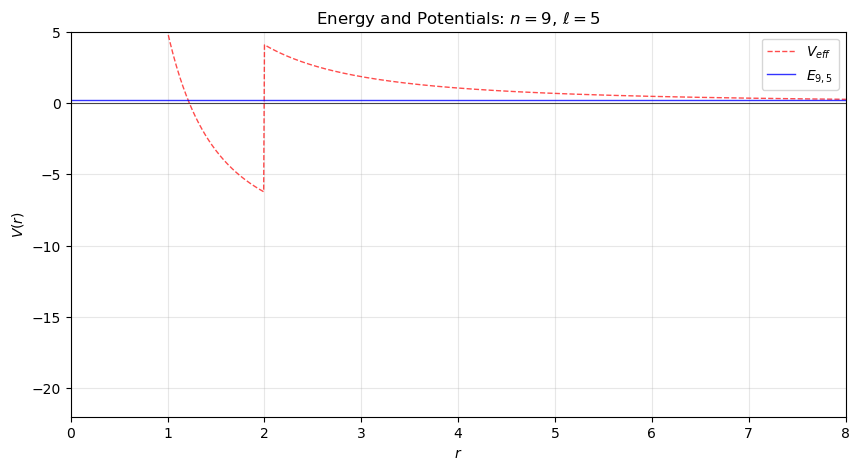

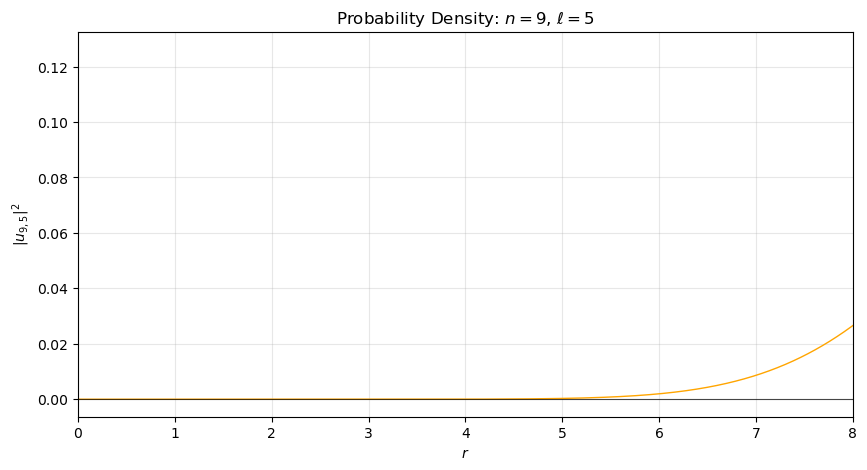

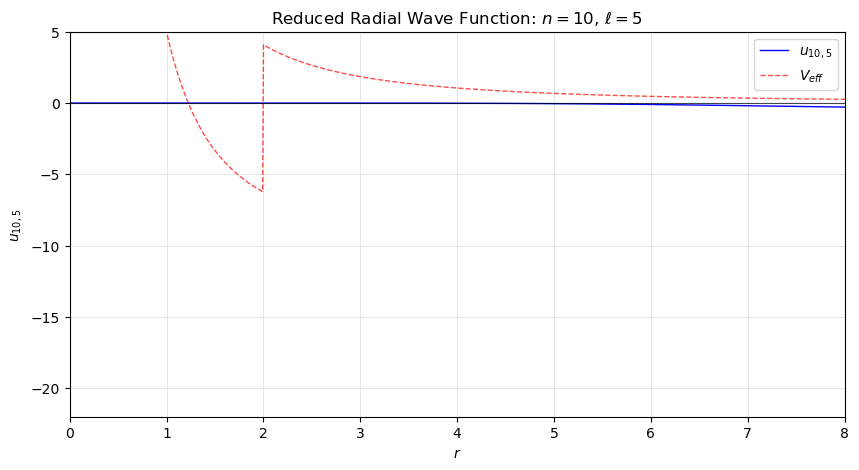

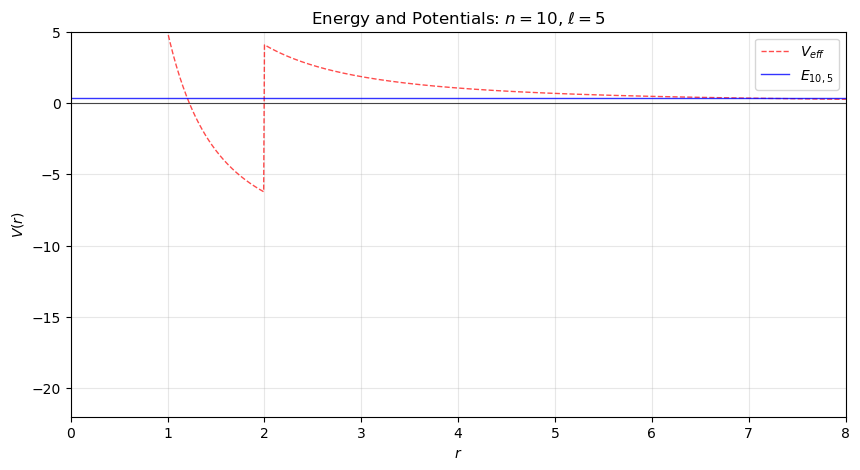

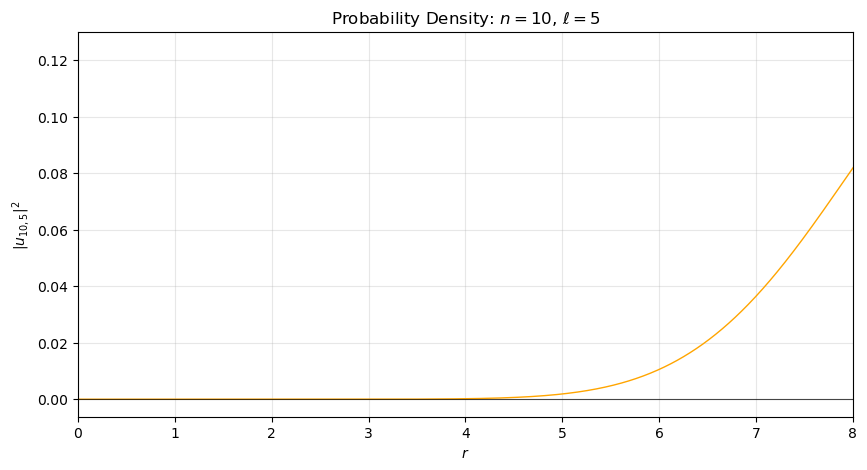

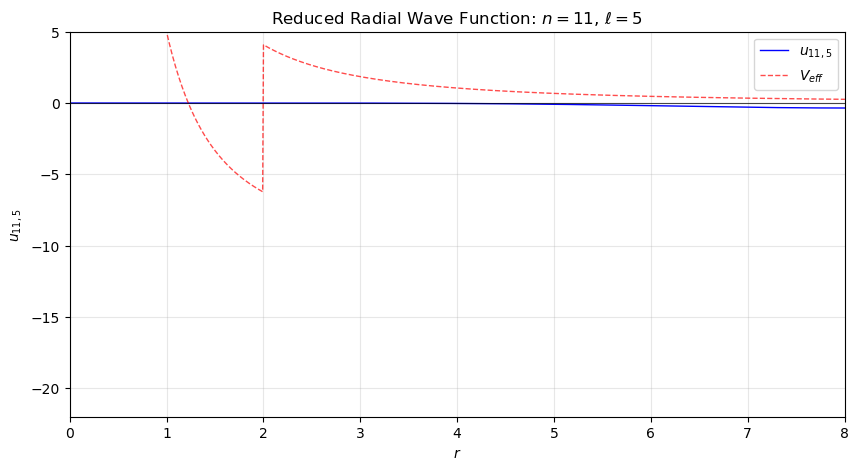

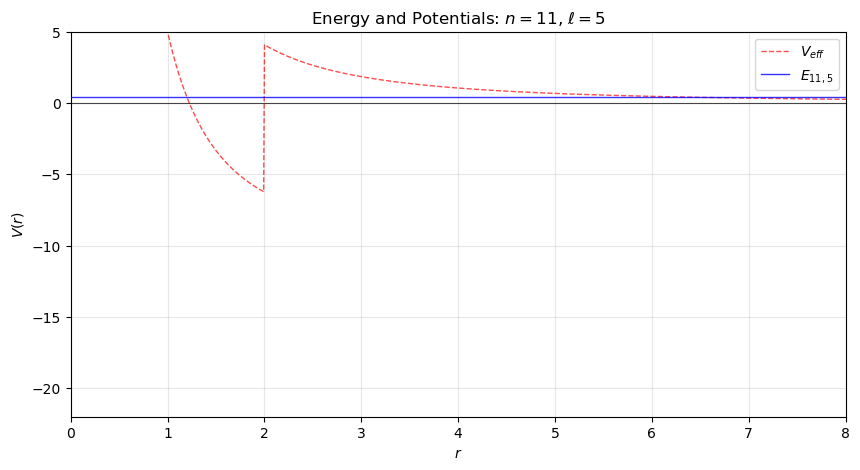

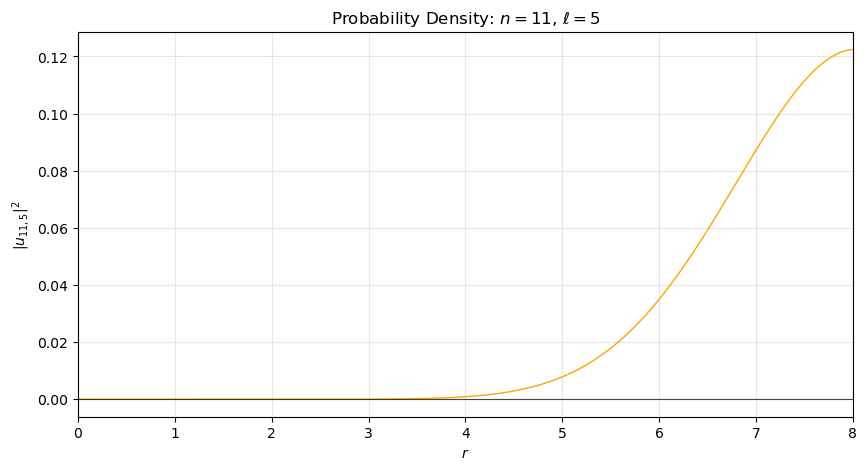

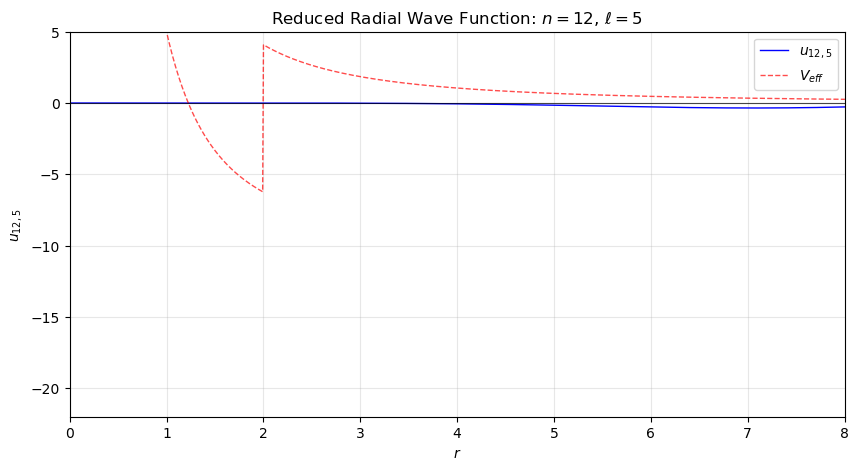

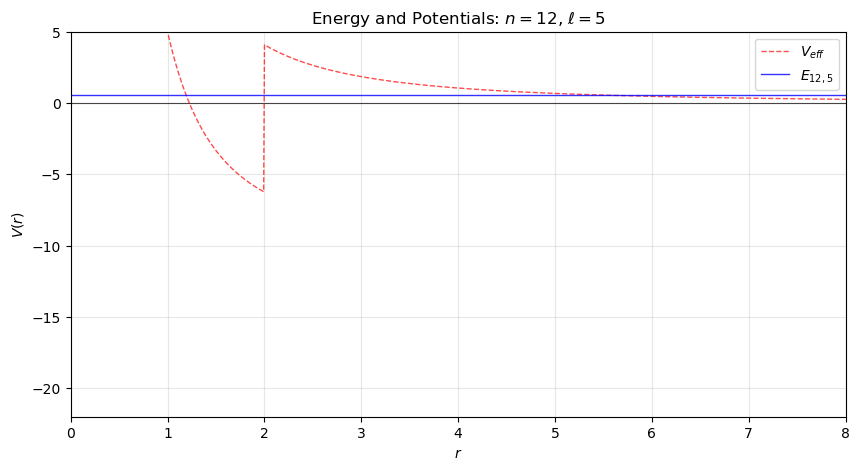

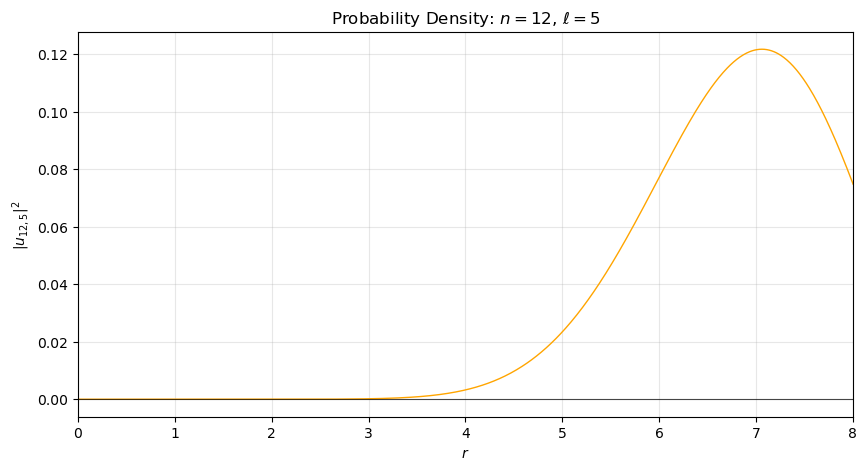

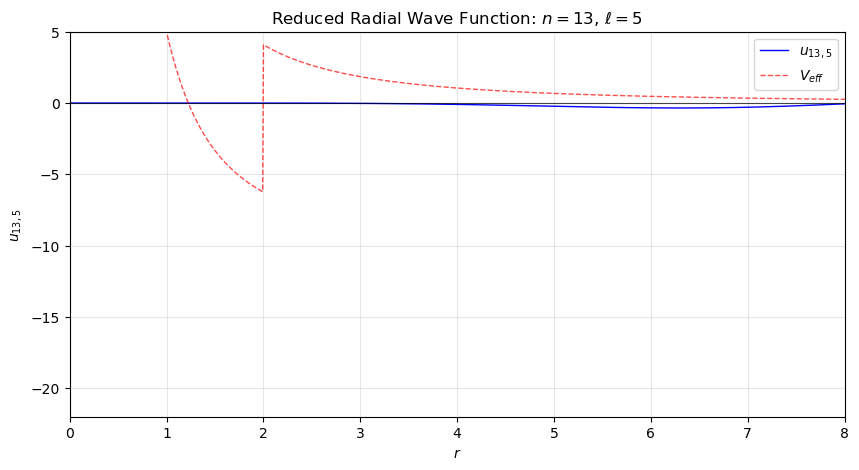

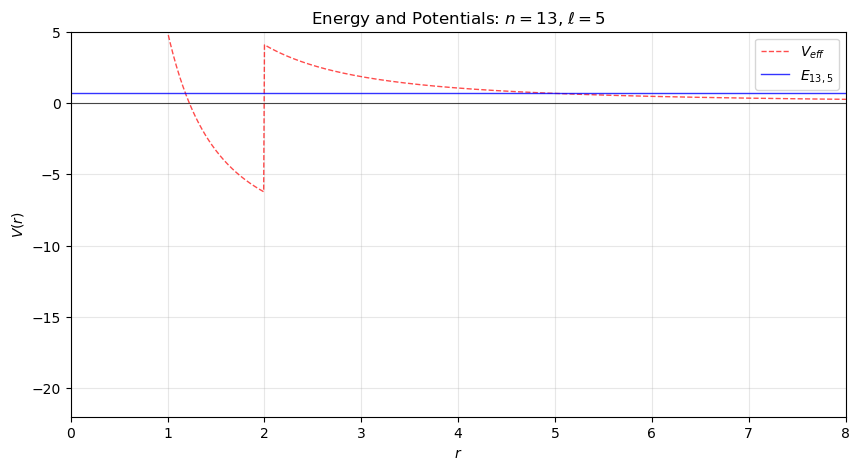

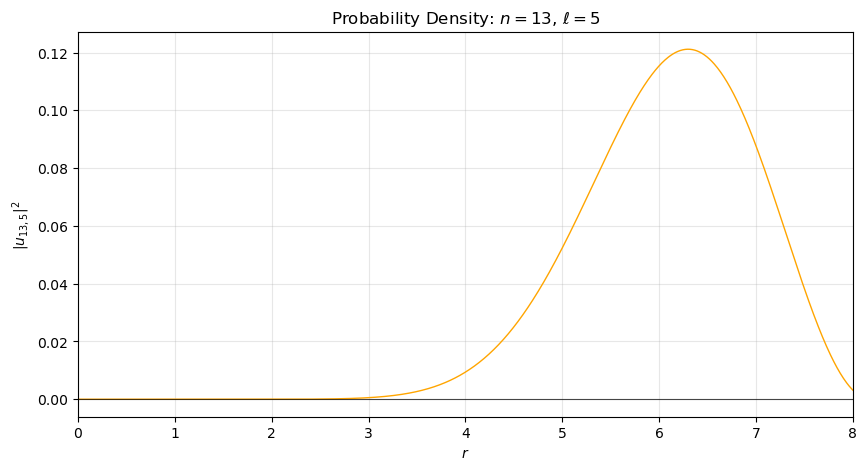

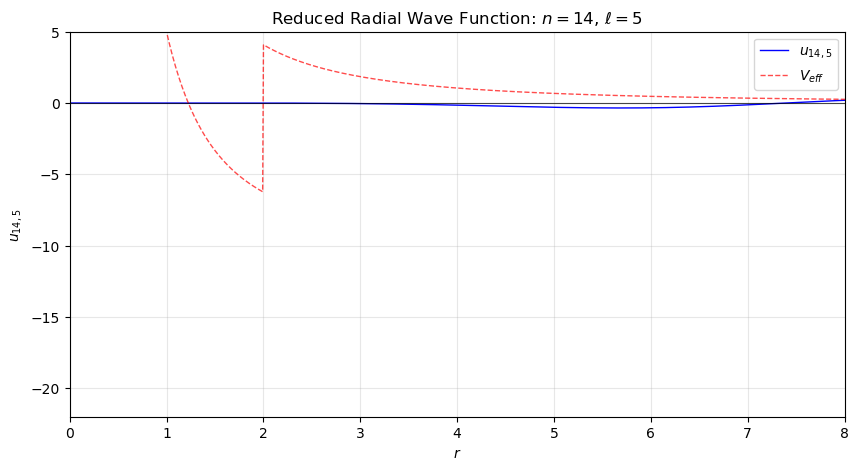

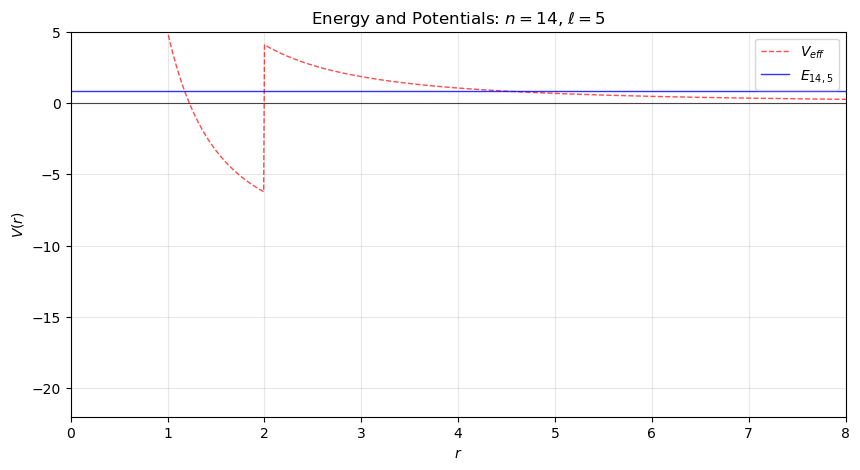

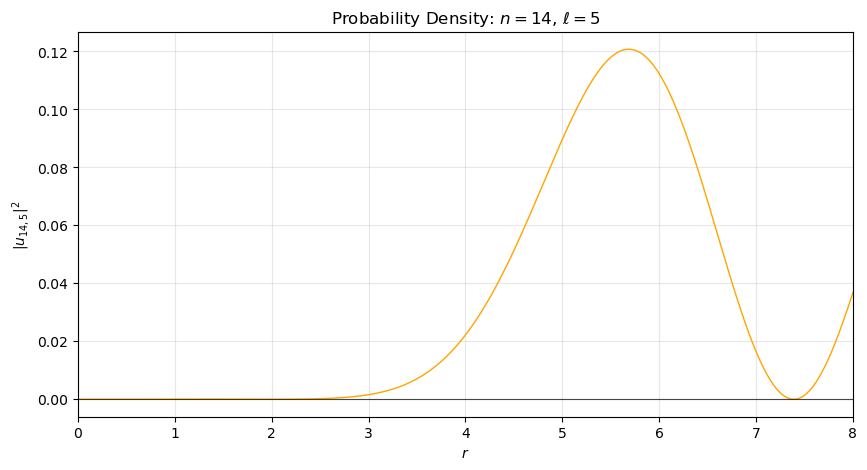

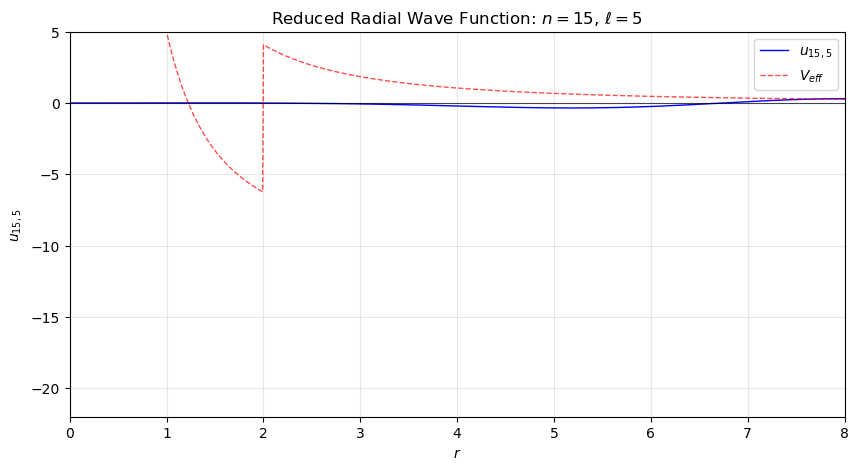

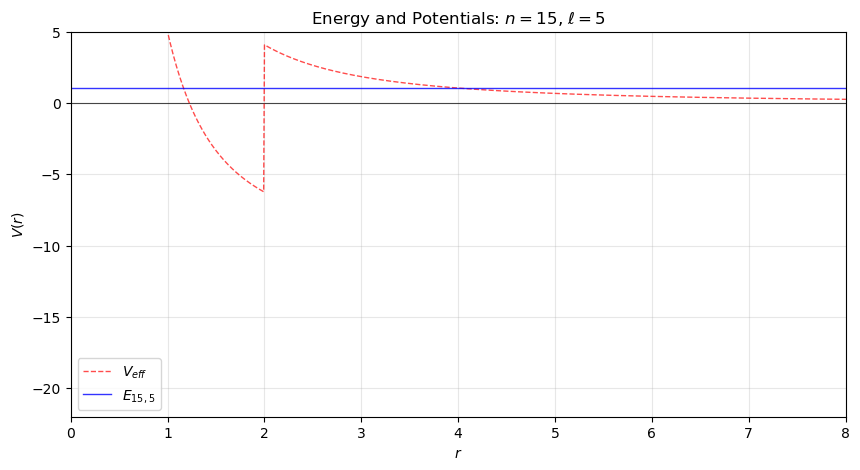

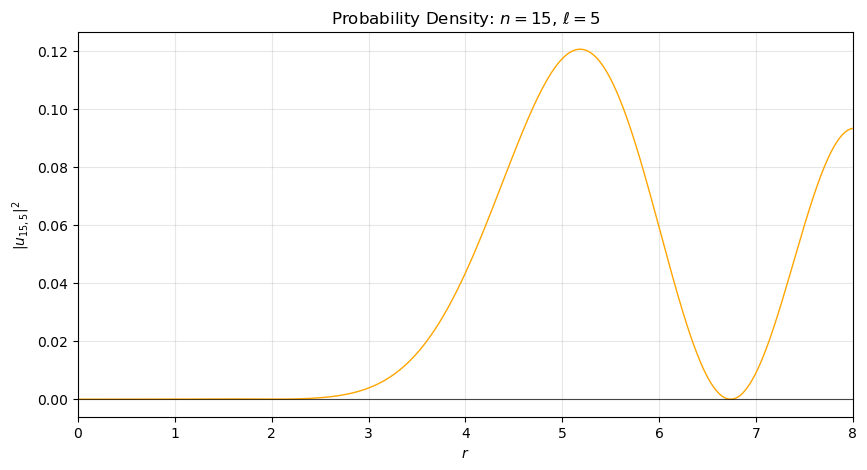

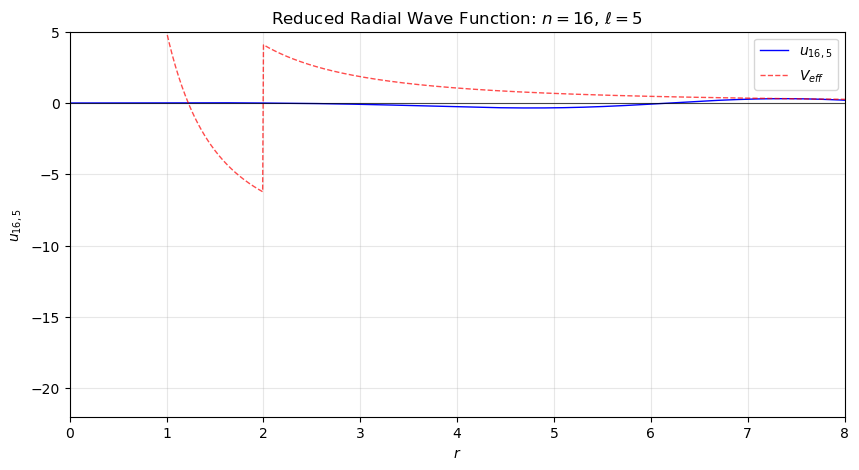

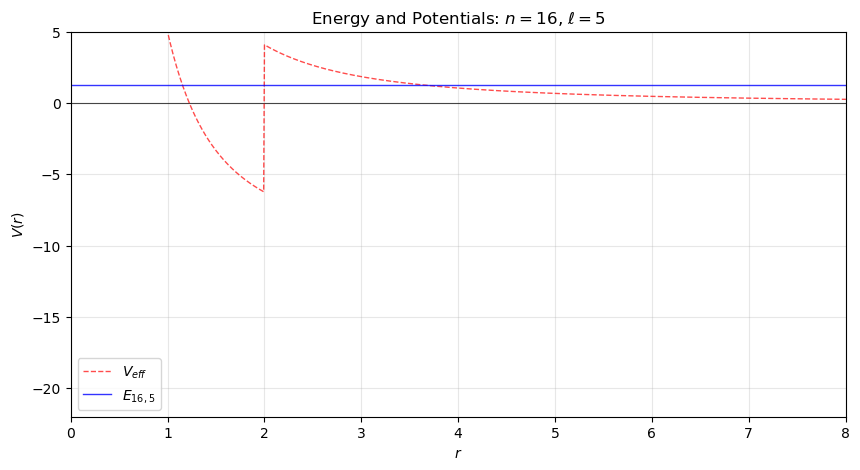

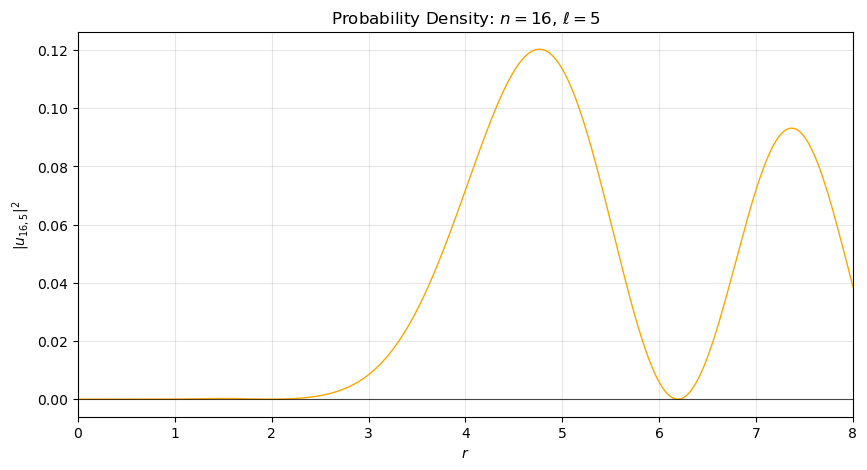

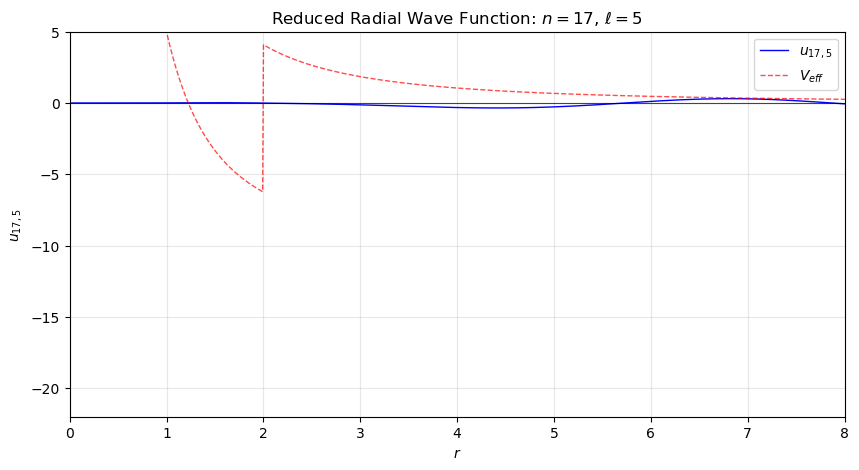

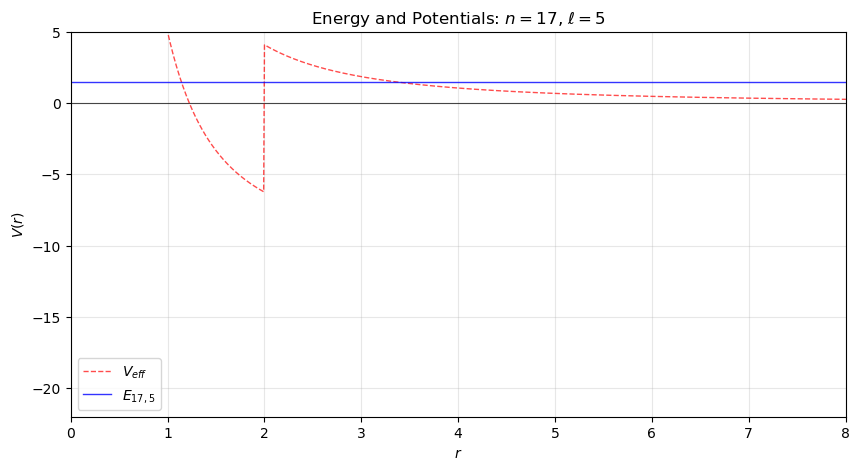

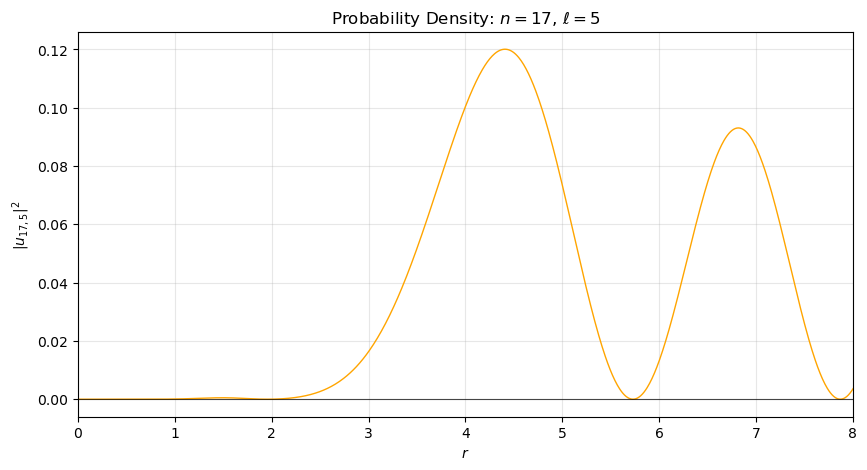

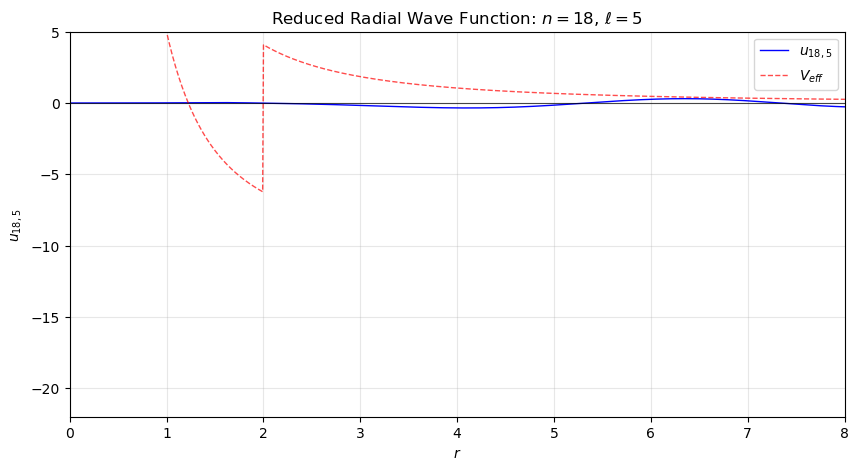

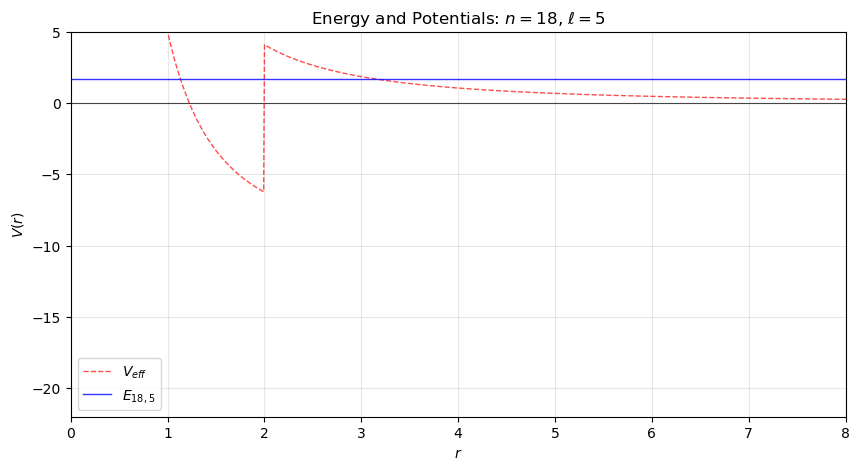

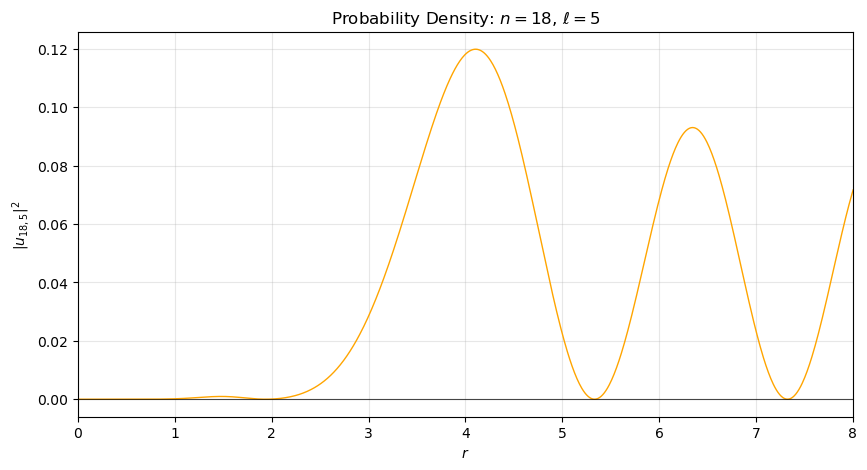

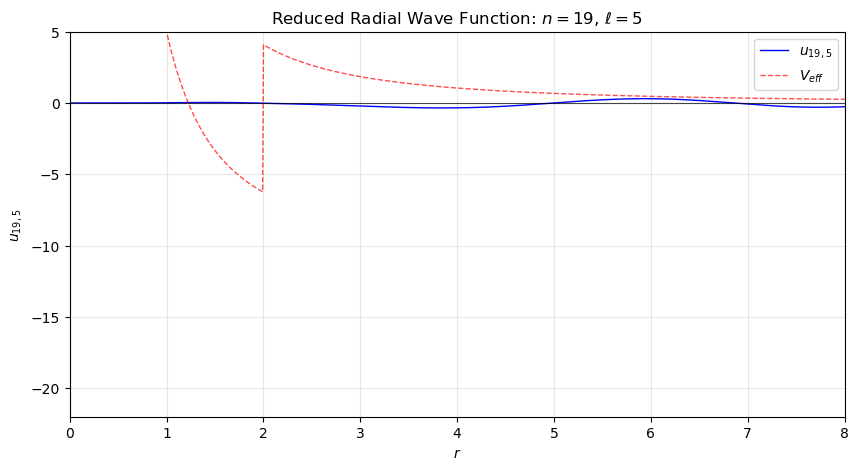

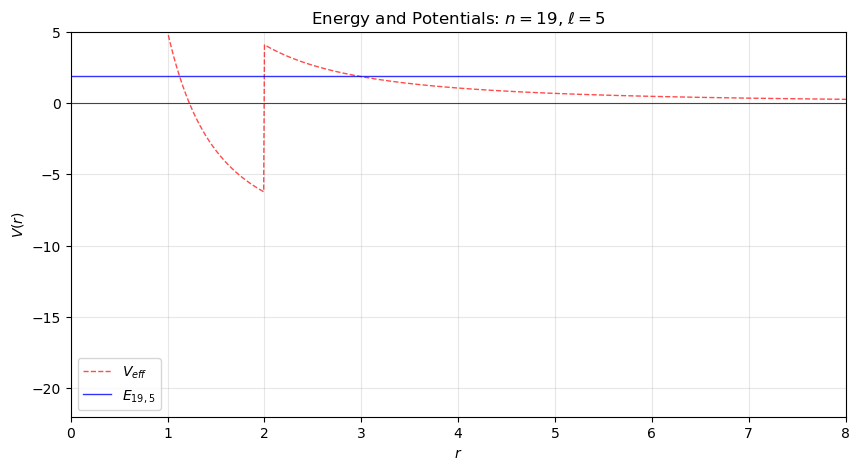

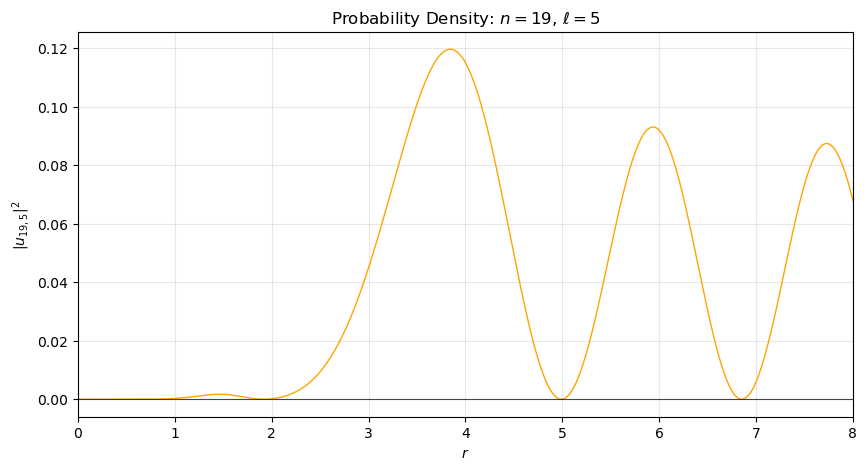

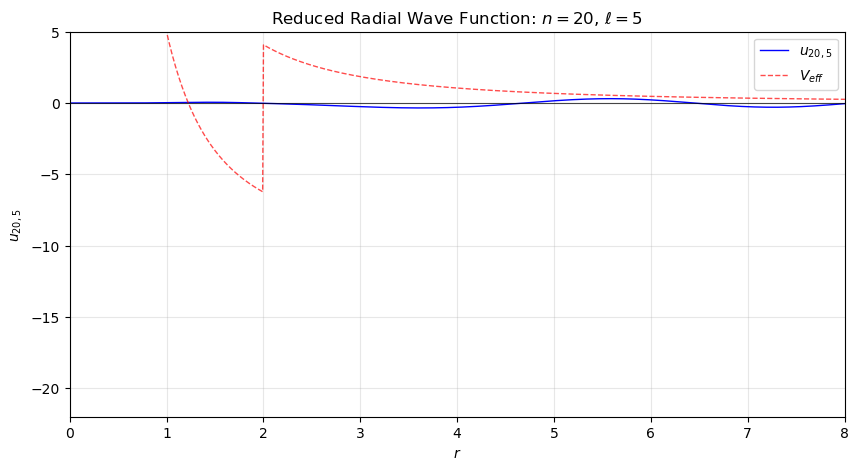

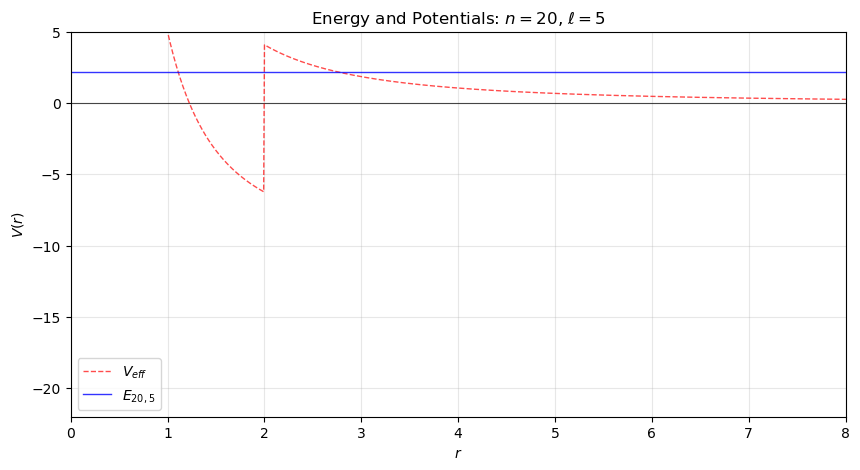

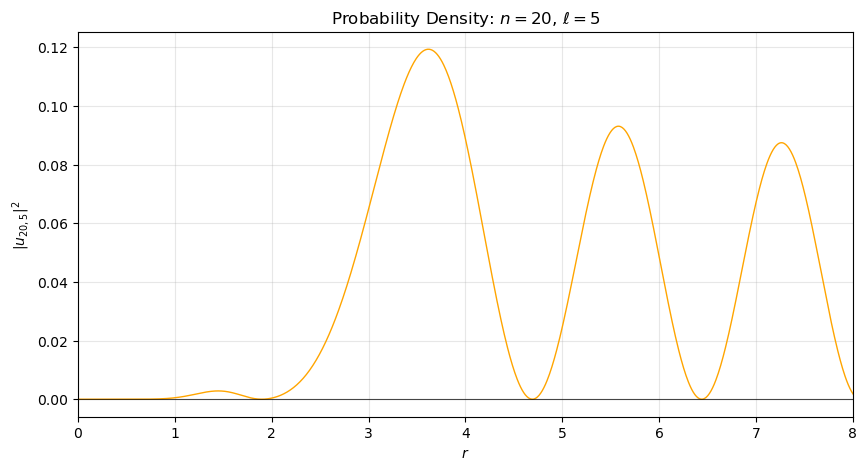

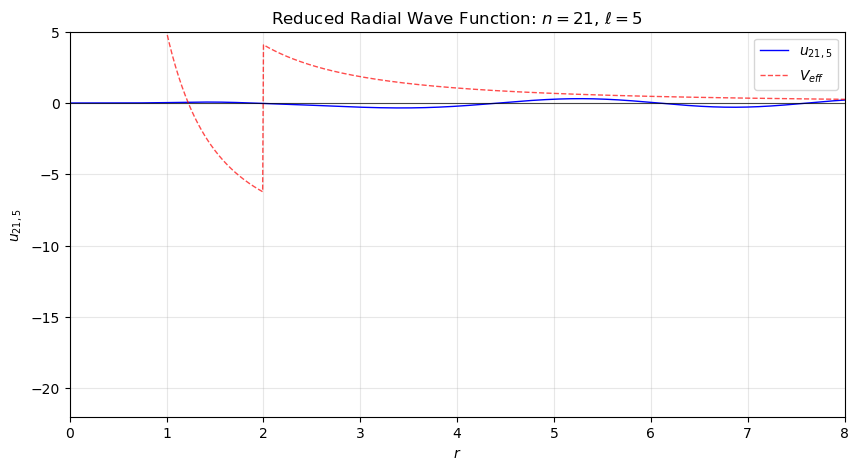

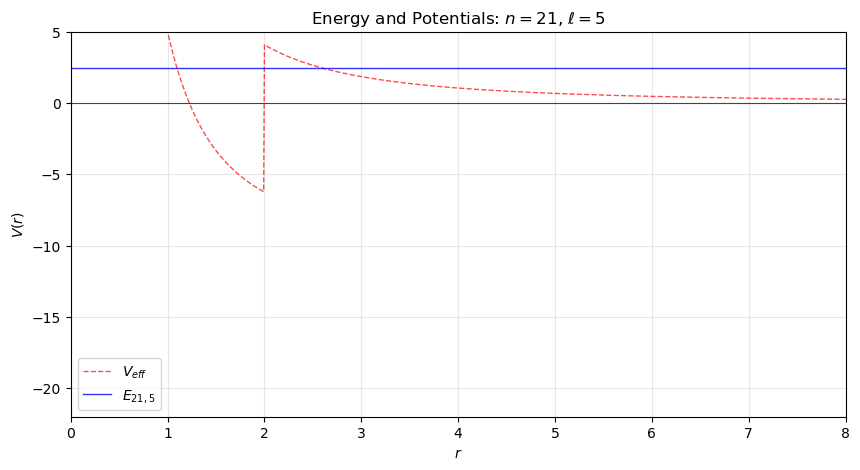

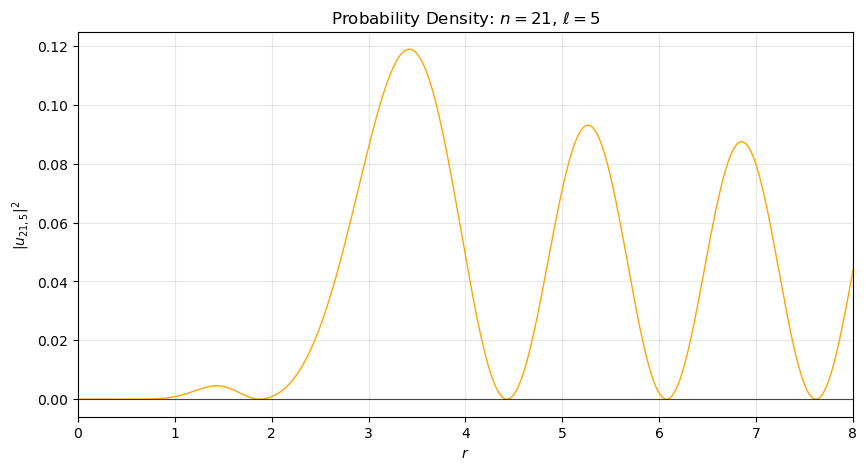

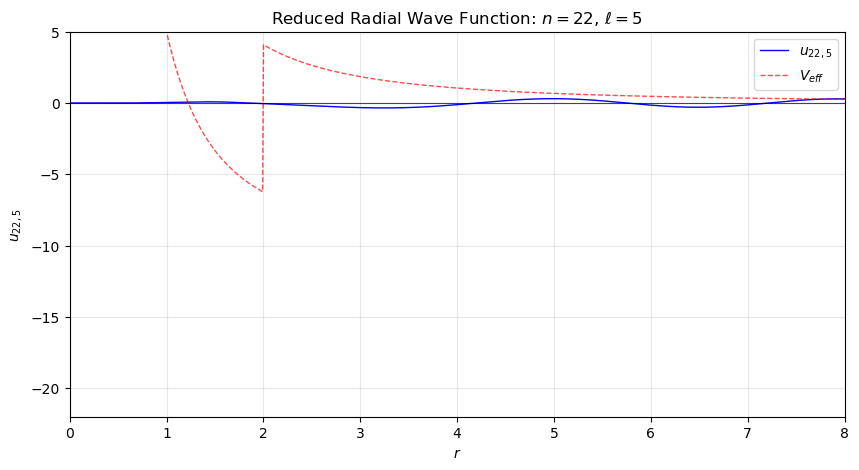

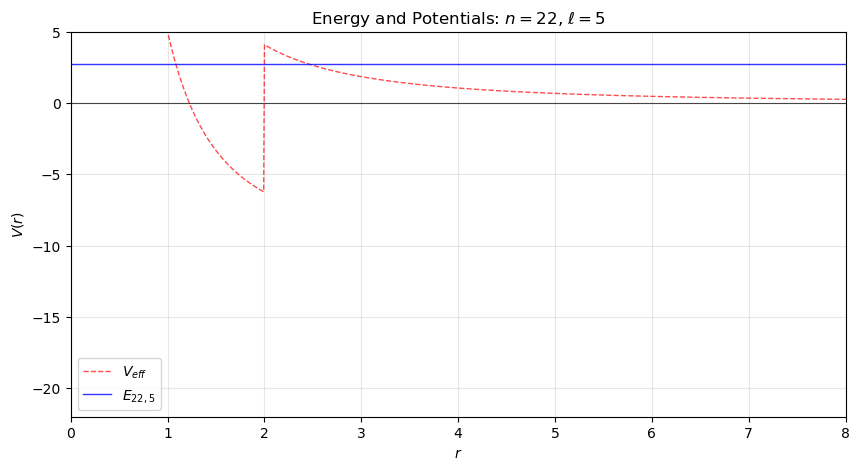

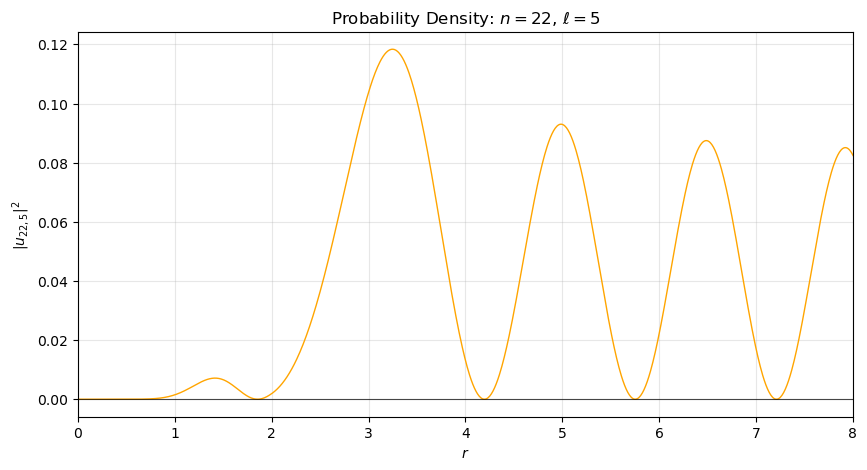

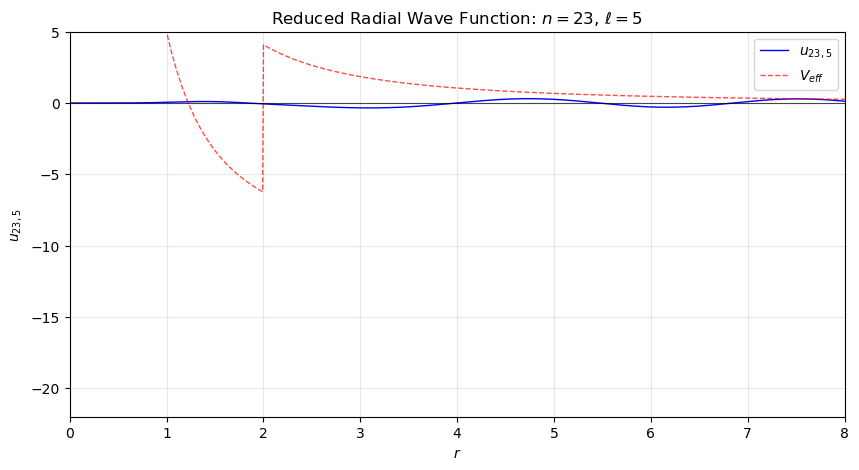

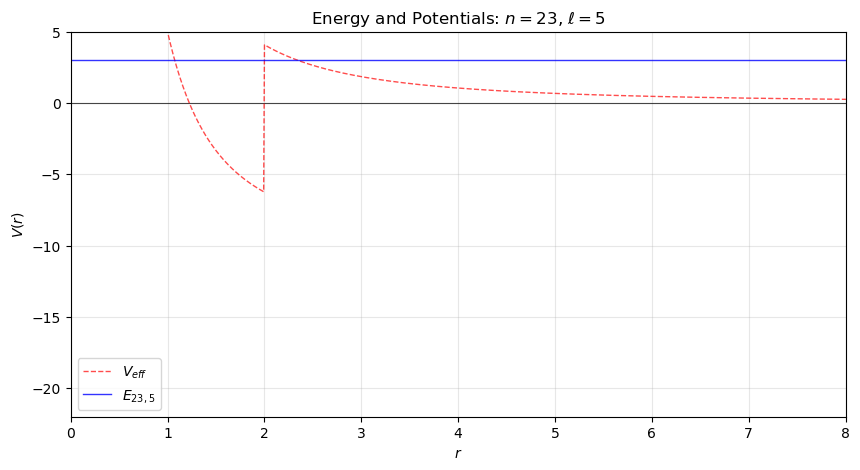

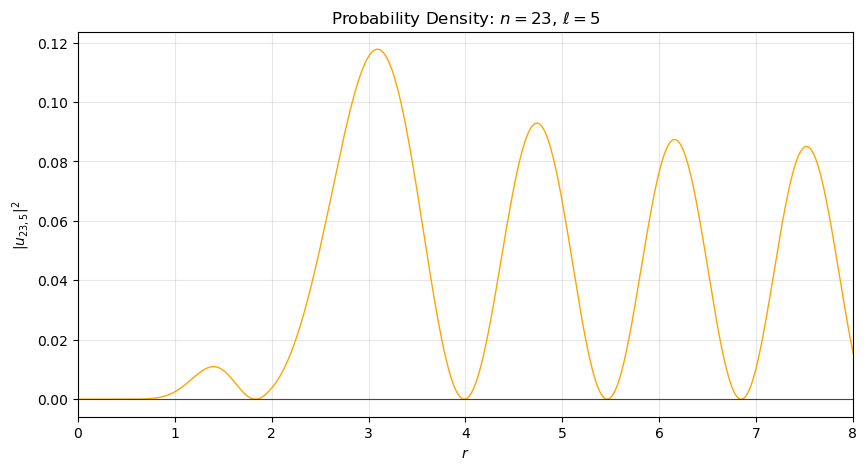

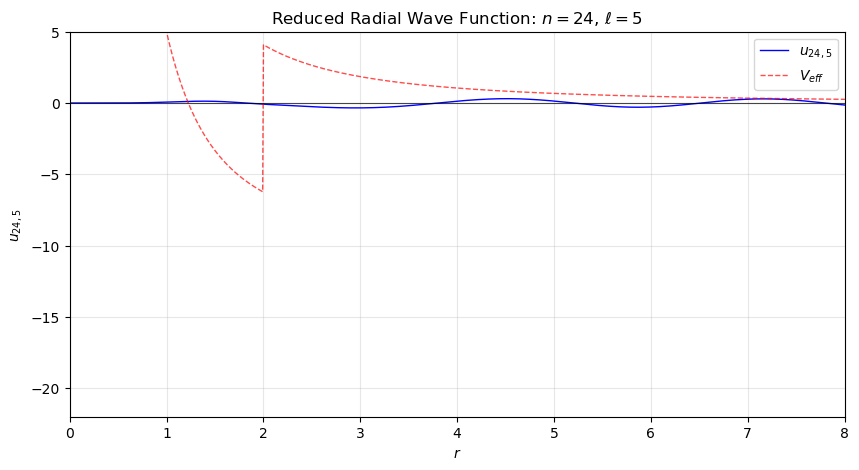

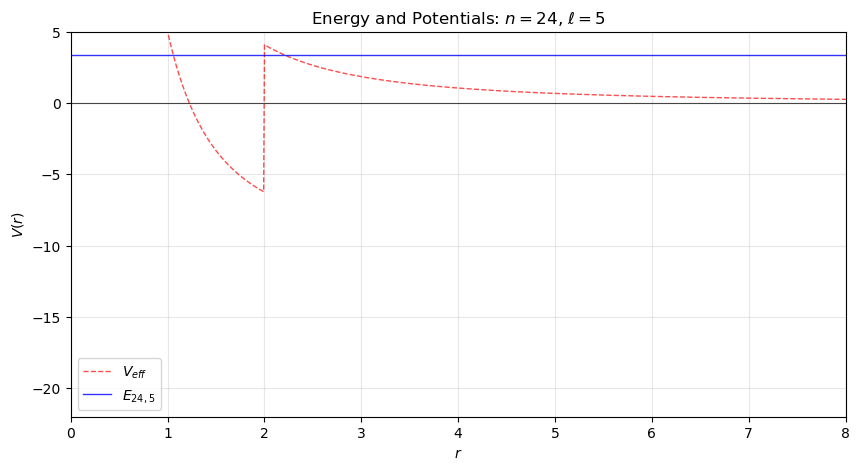

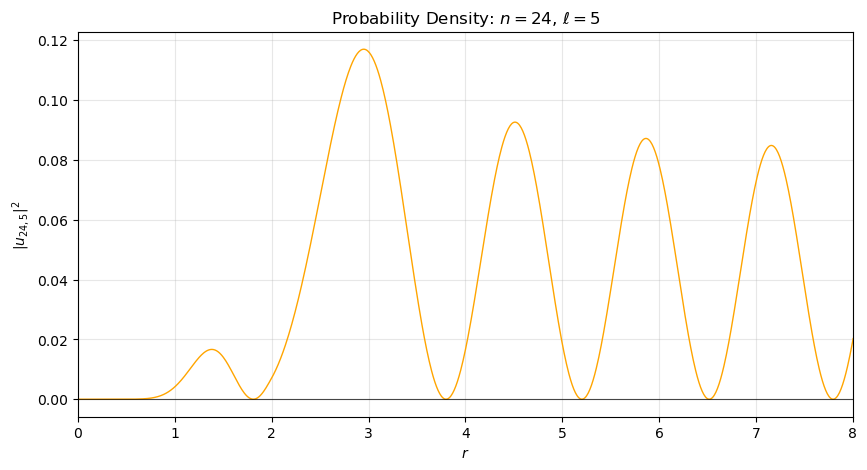

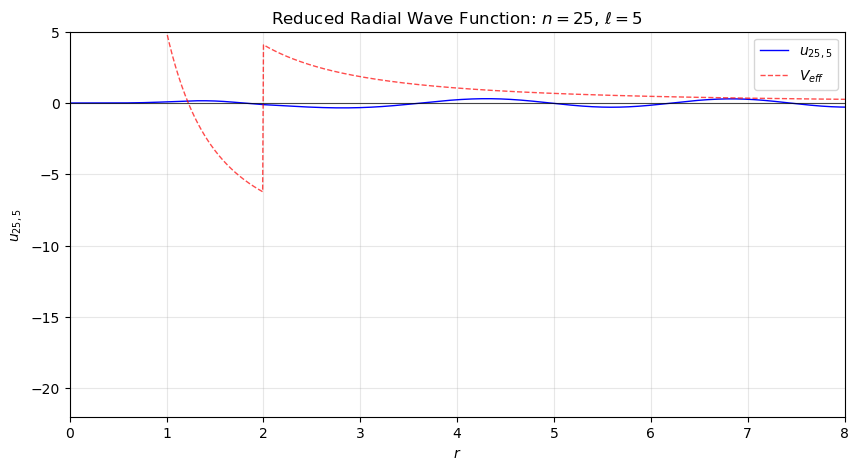

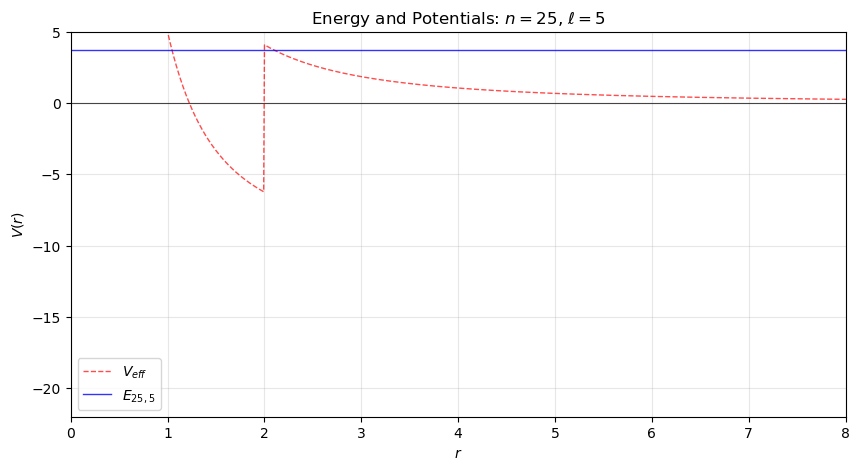

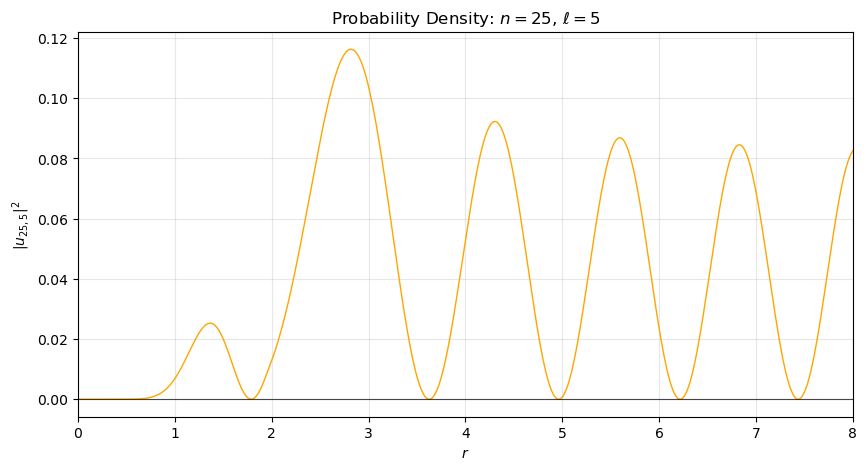

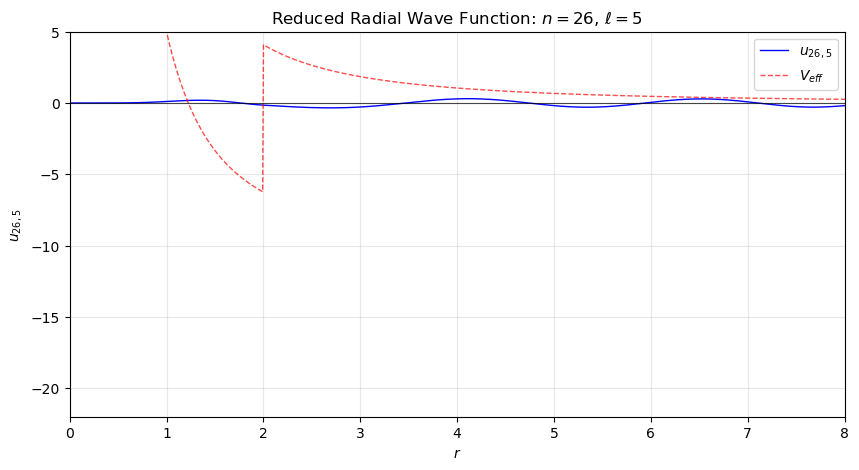

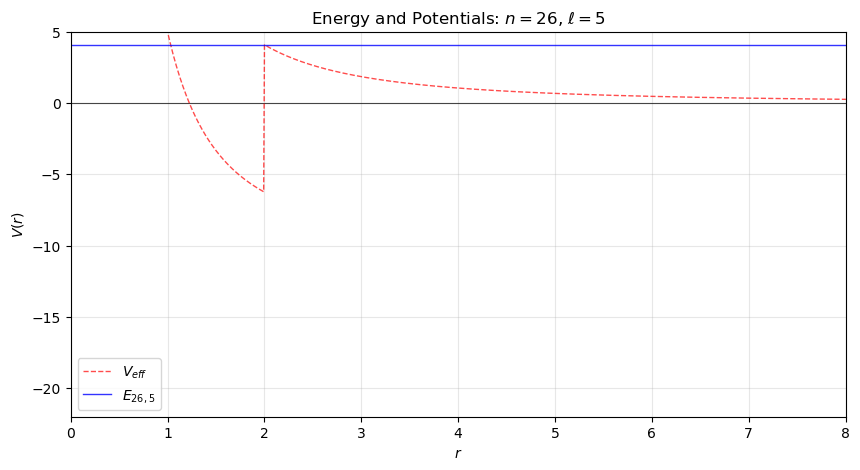

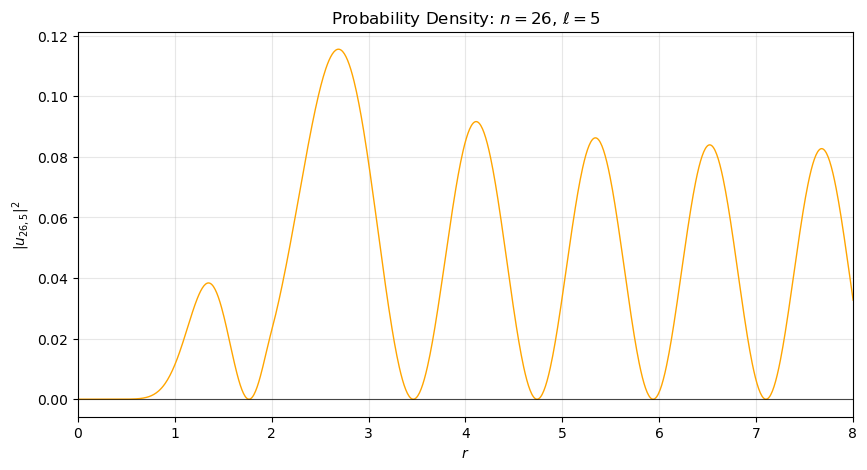

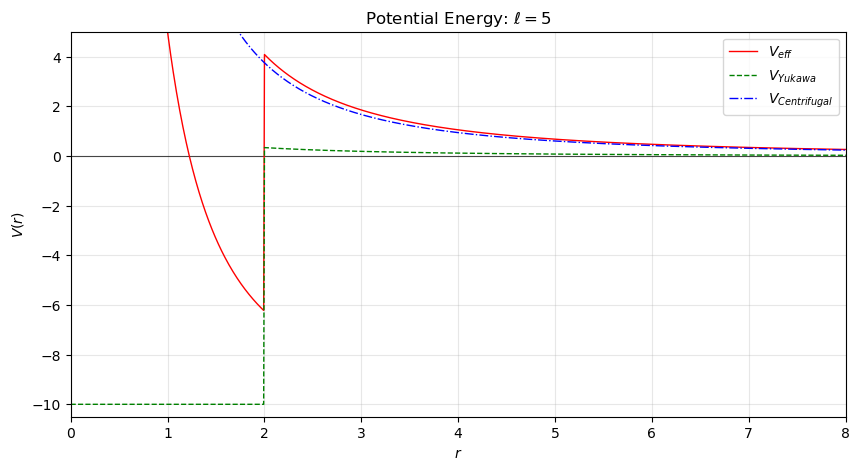

In [10]:
# plot reduced radial wave functions, probability densities, and energy w/ potential for all L and n values
for L in range(Lmax):
    for i, psi in enumerate(list_psix[L]):
        psi_truncated = psi[:len(r)]
        norm = np.sqrt(trapezoid(abs(psi_truncated)**2, r)) # normalize
        psi_normalized = psi_truncated / norm
        #print(psi_normalized)

        prob_density = abs(psi_normalized)**2

        prob_density_check = trapezoid(abs(psi_normalized)**2, r)
        '''
        if abs(prob_density_check - 1) < 1e-13:
            print('Wave Function Normalized.')
        else:
            print('Working on it')
        #print(prob_density_check)
        '''

        # plot wave functions and potential
        plt.figure(figsize=(10, 5))
        plt.plot(r, psi_normalized, lw=1.0, color='b', label=f'$u_{{{L+i+1},{L}}}$')
        plt.plot(r, V_eff(r), 'r--', lw=1.0, alpha=0.7, label='$V_{eff}$')
        plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.7)
        plt.xlabel('$r$')
        plt.ylabel(f'$u_{{{L+i+1},{L}}}$')
        plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 8)  # Focus on region near potential well
        plt.ylim(-22, 5)
        plt.legend()
        #plt.savefig(f'pb_wf_u{L+i+1}{L}.pdf')  # Save the figure
        plt.show()

        # plot energy and potential
        plt.figure(figsize=(10, 5))
        plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.7)
        plt.plot(r, V_eff(r), 'r--', lw=1.0, alpha=0.7, label='$V_{eff}$')
        plt.axhline(EL[L][i], color='b', ls='-', lw=1.0, alpha=0.8, label=f'$E_{{{L+i+1},{L}}}$')
        plt.xlabel('$r$')
        plt.ylabel('$V(r)$')
        plt.title(f'Energy and Potentials: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 8)
        plt.ylim(-22, 5)
        plt.legend()
        #plt.savefig(f'pb_pot_E{L+i+1}{L}.pdf')
        plt.show()

        # plot probability density
        plt.figure(figsize=(10, 5))
        plt.plot(r, prob_density, lw=1.0, color='orange', label='Probability Density')  # Add probability density plot
        plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.7)
        plt.xlabel('$r$')
        plt.ylabel(f'$|u_{{{L+i+1},{L}}}|^2$')
        plt.title(f'Probability Density: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 8)  # Focus on region near potential well
        #plt.savefig(f'pb_pd_u{L+i+1}{L}.pdf')  # Save the figure
        plt.show()
    
    # plot potential for each L
    plt.figure(figsize=(10,5))
    plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.7)
    plt.plot(r, V_eff(r), 'r-', lw=1.0, label='$V_{eff}$')
    plt.plot(r, V(r), 'g--', lw=1.0, label='$V_{Yukawa}$')
    plt.plot(r, centrifugal(r), 'b-.', lw=1.0, label='$V_{Centrifugal}$')
    plt.xlim(0, 8)
    plt.ylim(-V0-0.5, 5)
    plt.title(f'Potential Energy: $\ell = {L}$')
    plt.grid(True, alpha=0.3)
    plt.xlabel('$r$')
    plt.ylabel('$V(r)$')
    plt.legend()
    #plt.savefig(f'pb_Vr_L{L}.pdf')  # Save the figure
    plt.show()